<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

## **Faye**

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Algorithmic Trading - freeCodeCamp**

---

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Unsupervised Learning Strategy**

In [1]:
import sys
!{sys.executable} -m pip install pandas_datareader

In [2]:
import sys
!{sys.executable} -m pip install pandas_ta

In [3]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
warnings.filterwarnings('ignore')

In [4]:
import requests
from io import StringIO

sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
sp500_html = requests.get(sp500_url, headers = headers).text
sp500_tables = pd.read_html(StringIO(sp500_html))
sp500 = sp500_tables[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')
sp500_symbols = sp500['Symbol'].unique().tolist()

sp500.head(5)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [5]:
end_date = '2026-06-26'
start_date = pd.to_datetime(end_date) - pd.DateOffset(365 * 8)

df = yf.download(tickers = sp500_symbols, start = start_date, end = end_date,
                 auto_adjust = False).stack()

df.index.names = ['date', 'ticker']
df.columns = df.columns.str.lower()
df

[*********************100%***********************]  503 of 503 completed

1 Failed download:
['ECHO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-06-28 00:00:00 -> 2026-06-26)')


Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  
date       ticker              
2018-06-28 A        1564100.0  
           AAPL    69460800.0  
           ABBV     6698900.0  
           ABT      4237200.0  
           ACGL     1848300.0  
...                       ...  
2026-06-25 XYZ      5008700.0  
           YUM      1422400.0  
           ZBH      1661500.0  
           ZBRA      791000.0  
           ZTS      5790300.0  

[987897 rows x 6 columns]

In [6]:
# Garman-Klass Volatility

df['garman_klass_vol'] = ((np.log(df['high']) - np.log(df['low'])) ** 2) / 2 - (2 * np.log(2) - 1) * ((np.log(df['adj close']) - np.log(df['open'])) ** 2)
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol  
date       ticker                                
2018-06-28 A        1564100.0         -0.001071  
           AAPL    69460800.0         -0.000947  
           ABBV     6698900.0         -0.041624  
           ABT      4237200.0         -0.006288  
           ACGL     1848300.0         -0.000511  
...                       ...               ...  
2026-06-25 XYZ      5008700.0          0.000262  
           YUM      1422400.0          0.000091  
           ZBH      1661500.0          0.000288  
           ZBRA      791000.0          0.000563  
           ZTS      5790300.0          0.000519  

[987897 rows x 7 columns]

In [7]:
# Relative Strength Index (RSI) 

df['rsi'] = df.groupby(level = 1)['adj close'].transform(lambda x: pandas_ta.rsi(close = x, length = 20))
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol        rsi  
date       ticker                                           
2018-06-28 A        1564100.0         -0.001071        NaN  
           AAPL    69460800.0         -0.000947        NaN  
           ABBV     6698900.0         -0.041624        NaN  
           ABT      4237200.0         -0.006288        NaN  
           ACGL     1848300.0         -0.000511        NaN  
...                       ...               ...        ...  
2026-06-25 XYZ      5008700.0          0.000262  54.605642  
           YUM      1422400.0          0.000091  47.630036  
           ZBH      1661500.0          0.000288  58.942178  
           ZBRA      791000.0          0.000563  52.589122  
           ZTS      5790300.0          0.000519  36.924773  

[987897 rows x 8 columns]

In [8]:
df = df[df.index.get_level_values("ticker") != "ECHO"]

In [9]:
# Bollinger Bands

df['bb_low'] = df.groupby(level = 1)['adj close'].transform(lambda x: pandas_ta.bbands(close = np.log1p(x), length = 20).iloc[:,0])                        
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol        rsi    bb_low  
date       ticker                                                     
2018-06-28 A        1564100.0         -0.001071        NaN       NaN  
           AAPL    69460800.0         -0.000947        NaN       NaN  
           ABBV     6698900.0         -0.041624        NaN       NaN  
           ABT      4237200.0         -0.006288        NaN       NaN  
           ACGL     1848300.0         -0.000511        NaN       NaN  
...                       ...               ...        ...       ...  
2026-06-25 XYZ      5008700.0          0.000262  54.605642  4.212185  
           YUM      1422400.0          0.000091  47.630036  4.986377  
           ZBH      1661500.0          0.000288  58.942178  4.417228  
           ZBRA      791000.0          0.000563  52.589122  5.397805  
           ZTS      5790300.0          0.000519  36.924773  4.335828  

[987897 rows x 9 columns]

In [10]:
# Bollinger Bands

df['bb_mid'] = df.groupby(level = 1)['adj close'].transform(lambda x: pandas_ta.bbands(close = np.log1p(x), length = 20).iloc[:,1])
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol        rsi    bb_low    bb_mid  
date       ticker                                                               
2018-06-28 A        1564100.0         -0.001071        NaN       NaN       NaN  
           AAPL    69460800.0         -0.000947        NaN       NaN       NaN  
           ABBV     6698900.0         -0.041624        NaN       NaN       NaN  
           ABT      4237200.0         -0.006288        NaN       NaN       NaN  
           ACGL     1848300.0         -0.000511        NaN       NaN       NaN  
...                       ...               ...        ...       ...       ...  
2026-06-25 XYZ      5008700.0          0.000262  54.605642  4.212185  4.292743  
           YUM      1422400.0          0.000091  47.630036  4.986377  5.024373  
           ZBH      1661500.0          0.000288  58.942178  4.417228  4.474755  
           ZBRA      791000.0          0.000563  52.589122  5.397805  5.479578  
           ZTS      5790300.0          0.000519  36.924773  4.335828  4.377877  

[987897 rows x 10 columns]

In [11]:
# Bollinger Bands

df['bb_high'] = df.groupby(level = 1)['adj close'].transform(lambda x: pandas_ta.bbands(close = np.log1p(x), length = 20).iloc[:,2])
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2018-06-28 A        1564100.0         -0.001071        NaN       NaN   
           AAPL    69460800.0         -0.000947        NaN       NaN   
           ABBV     6698900.0         -0.041624        NaN       NaN   
           ABT      4237200.0         -0.006288        NaN       NaN   
           ACGL     1848300.0         -0.000511        NaN       NaN   
...                       ...               ...        ...       ...   
2026-06-25 XYZ      5008700.0          0.000262  54.605642  4.212185   
           YUM      1422400.0          0.000091  47.630036  4.986377   
           ZBH      1661500.0          0.000288  58.942178  4.417228   
           ZBRA      791000.0          0.000563  52.589122  5.397805   
           ZTS      5790300.0          0.000519  36.924773  4.335828   

Price                bb_mid   bb_high  
date       ticker                      
2018-06-28 A            NaN       NaN  
           AAPL         NaN       NaN  
           ABBV         NaN       NaN  
           ABT          NaN       NaN  
           ACGL         NaN       NaN  
...                     ...       ...  
2026-06-25 XYZ     4.292743  4.373302  
           YUM     5.024373  5.062369  
           ZBH     4.474755  4.532282  
           ZBRA    5.479578  5.561352  
           ZTS     4.377877  4.419926  

[987897 rows x 11 columns]

In [12]:
# Average True Range (ATR)

def compute_atr(stock_data):
    
    atr = pandas_ta.atr(high = stock_data['high'], 
                        low = stock_data['low'],
                        close = stock_data['close'],
                        length = 14)
    
    return atr.sub(atr.mean()).div(atr.std())
    
df['atr'] = df.groupby(level = 1, group_keys = False).apply(compute_atr)
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2018-06-28 A        1564100.0         -0.001071        NaN       NaN   
           AAPL    69460800.0         -0.000947        NaN       NaN   
           ABBV     6698900.0         -0.041624        NaN       NaN   
           ABT      4237200.0         -0.006288        NaN       NaN   
           ACGL     1848300.0         -0.000511        NaN       NaN   
...                       ...               ...        ...       ...   
2026-06-25 XYZ      5008700.0          0.000262  54.605642  4.212185   
           YUM      1422400.0          0.000091  47.630036  4.986377   
           ZBH      1661500.0          0.000288  58.942178  4.417228   
           ZBRA      791000.0          0.000563  52.589122  5.397805   
           ZTS      5790300.0          0.000519  36.924773  4.335828   

Price                bb_mid   bb_high       atr  
date       ticker                                
2018-06-28 A            NaN       NaN       NaN  
           AAPL         NaN       NaN       NaN  
           ABBV         NaN       NaN       NaN  
           ABT          NaN       NaN       NaN  
           ACGL         NaN       NaN       NaN  
...                     ...       ...       ...  
2026-06-25 XYZ     4.292743  4.373302 -0.571604  
           YUM     5.024373  5.062369  1.221077  
           ZBH     4.474755  4.532282 -0.634508  
           ZBRA    5.479578  5.561352  0.369251  
           ZTS     4.377877  4.419926 -0.657308  

[987897 rows x 12 columns]

In [13]:
# Moving Average Convergence Divergence (MACD)

def compute_macd(close):
    
    macd_df = pandas_ta.macd(close, length = 20)
    
    if macd_df is None or macd_df.shape[1] == 0:
        return pd.Series(np.zeros(len(close)), index = close.index)
        
    macd = macd_df.iloc[:, 0]
    
    std = macd.std()
    if std == 0 or np.isnan(std):
        return pd.Series(0, index = close.index)
        
    return (macd - macd.mean()) / std

df['macd'] = (df.groupby(level = 1, group_keys = False)['adj close'].apply(compute_macd))
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2018-06-28 A        1564100.0         -0.001071        NaN       NaN   
           AAPL    69460800.0         -0.000947        NaN       NaN   
           ABBV     6698900.0         -0.041624        NaN       NaN   
           ABT      4237200.0         -0.006288        NaN       NaN   
           ACGL     1848300.0         -0.000511        NaN       NaN   
...                       ...               ...        ...       ...   
2026-06-25 XYZ      5008700.0          0.000262  54.605642  4.212185   
           YUM      1422400.0          0.000091  47.630036  4.986377   
           ZBH      1661500.0          0.000288  58.942178  4.417228   
           ZBRA      791000.0          0.000563  52.589122  5.397805   
           ZTS      5790300.0          0.000519  36.924773  4.335828   

Price                bb_mid   bb_high       atr      macd  
date       ticker                                          
2018-06-28 A            NaN       NaN       NaN       NaN  
           AAPL         NaN       NaN       NaN       NaN  
           ABBV         NaN       NaN       NaN       NaN  
           ABT          NaN       NaN       NaN       NaN  
           ACGL         NaN       NaN       NaN       NaN  
...                     ...       ...       ...       ...  
2026-06-25 XYZ     4.292743  4.373302 -0.571604  0.226414  
           YUM     5.024373  5.062369  1.221077 -0.215334  
           ZBH     4.474755  4.532282 -0.634508  0.482529  
           ZBRA    5.479578  5.561352  0.369251  0.052286  
           ZTS     4.377877  4.419926 -0.657308 -1.075305  

[987897 rows x 13 columns]

In [14]:
# Dollar Volume

df['dollar_volume'] = (df['adj close'] * df['volume']) / 1e6
df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2018-06-28 A        57.721916   61.290001   61.639999   60.419998   61.130001   
           AAPL     43.706707   46.375000   46.552502   45.950001   46.025002   
           ABBV     65.731300   92.430000   92.610001   90.809998   91.339996   
           ABT      53.142929   61.270000   61.480000   60.459999   60.459999   
           ACGL     25.122740   26.420000   26.570000   26.160000   26.160000   
...                       ...         ...         ...         ...         ...   
2026-06-25 XYZ      74.080002   74.080002   75.750000   73.680000   75.410004   
           YUM     151.139999  151.139999  153.110001  150.770004  152.419998   
           ZBH      90.959999   90.959999   92.760002   90.559998   90.919998   
           ZBRA    243.389999  243.389999  252.500000  242.020004  250.669998   
           ZTS      77.820000   77.820000   79.910004   77.260002   78.709999   

Price                  volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2018-06-28 A        1564100.0         -0.001071        NaN       NaN   
           AAPL    69460800.0         -0.000947        NaN       NaN   
           ABBV     6698900.0         -0.041624        NaN       NaN   
           ABT      4237200.0         -0.006288        NaN       NaN   
           ACGL     1848300.0         -0.000511        NaN       NaN   
...                       ...               ...        ...       ...   
2026-06-25 XYZ      5008700.0          0.000262  54.605642  4.212185   
           YUM      1422400.0          0.000091  47.630036  4.986377   
           ZBH      1661500.0          0.000288  58.942178  4.417228   
           ZBRA      791000.0          0.000563  52.589122  5.397805   
           ZTS      5790300.0          0.000519  36.924773  4.335828   

Price                bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                         
2018-06-28 A            NaN       NaN       NaN       NaN      90.282849  
           AAPL         NaN       NaN       NaN       NaN    3035.902834  
           ABBV         NaN       NaN       NaN       NaN     440.327408  
           ABT          NaN       NaN       NaN       NaN     225.177219  
           ACGL         NaN       NaN       NaN       NaN      46.434360  
...                     ...       ...       ...       ...            ...  
2026-06-25 XYZ     4.292743  4.373302 -0.571604  0.226414     371.044505  
           YUM     5.024373  5.062369  1.221077 -0.215334     214.981535  
           ZBH     4.474755  4.532282 -0.634508  0.482529     151.130038  
           ZBRA    5.479578  5.561352  0.369251  0.052286     192.521490  
           ZTS     4.377877  4.419926 -0.657308 -1.075305     450.601144  

[987897 rows x 14 columns]

In [15]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open',
                                                          'high', 'low', 'close']]
last_cols

data = pd.concat([df.unstack('ticker')['dollar_volume'].resample('M').mean().stack('ticker').to_frame('dollar_volume'), 
                  df.unstack()[last_cols].resample('M').last().stack('ticker')],
                 axis = 1)

data

dollar_volume    adj close  garman_klass_vol         rsi  \
date       ticker                                                             
2018-06-30 A          100.871184    58.239899         -0.001167  100.000000   
           AAPL      3501.352737    43.614819         -0.001396    0.000000   
           ABBV       443.783429    65.887749         -0.045221  100.000000   
           ABT        266.191921    52.900078         -0.008626    0.000000   
           ACGL        42.462656    25.160774         -0.000932  100.000000   
...                          ...          ...               ...         ...   
2026-06-30 SOLV       132.757927    77.919998          0.000402   55.174228   
           GEV       3203.074160  1085.469971          0.001286   57.101461   
           SNDK     21249.432612  2335.000000          0.005968   66.346419   
           Q          332.379355   167.490005          0.002042   57.334205   
           FDXF       440.798356   158.529999          0.000692   86.475554   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2018-06-30 A            NaN       NaN       NaN       NaN       NaN  
           AAPL         NaN       NaN       NaN       NaN       NaN  
           ABBV         NaN       NaN       NaN       NaN       NaN  
           ABT          NaN       NaN       NaN       NaN       NaN  
           ACGL         NaN       NaN       NaN       NaN       NaN  
...                     ...       ...       ...       ...       ...  
2026-06-30 SOLV    4.293952  4.362356  4.430760  0.701471  0.136597  
           GEV     6.753247  6.892783  7.032318  2.471398  0.421940  
           SNDK    7.294948  7.529934  7.764920  4.074730  3.041971  
           Q       4.934074  5.049879  5.165684  2.461574  0.404260  
           FDXF    4.988649  5.117581  5.246512 -1.299033  0.000000  

[47723 rows x 9 columns]

In [16]:
# Five-Year Rolling Average of Dollar Volume

data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5 * 12, min_periods = 12).mean().stack())
data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending = False))
data = data[data['dollar_vol_rank'] < 150].drop(['dollar_volume', 'dollar_vol_rank'], axis = 1)
data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                       
2019-05-31 AAPL      41.877140         -0.000851  34.632737  3.722981   
           ABBV      57.129440         -0.035234  40.509413  4.054798   
           ABT       67.184036         -0.005762  47.744321  4.202634   
           ACN      161.063324         -0.003562  54.904399  5.052345   
           ADBE     270.899994          0.000117  47.432187  5.594943   
...                        ...               ...        ...       ...   
2026-06-30 APP      445.929993          0.002891  41.424132  6.050628   
           HOOD      93.470001          0.001033  53.727129  4.370975   
           CEG      268.690002          0.000377  47.281992  5.491247   
           GEV     1085.469971          0.001286  57.101461  6.753247   
           SNDK    2335.000000          0.005968  66.346419  7.294948   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2019-05-31 AAPL    3.832874  3.942767 -1.389532 -0.771322  
           ABBV    4.089100  4.123403 -1.133794 -0.344695  
           ABT     4.226322  4.250010 -1.245685 -0.285322  
           ACN     5.080432  5.108519 -1.450806  0.117697  
           ADBE    5.627233  5.659523 -1.340997 -0.012606  
...                     ...       ...       ...       ...  
2026-06-30 APP     6.260477  6.470327  1.714511 -1.119105  
           HOOD    4.539915  4.708856  1.954111  1.934687  
           CEG     5.582176  5.673105  0.499899 -0.694927  
           GEV     6.892783  7.032318  2.471398  0.421940  
           SNDK    7.529934  7.764920  4.074730  3.041971  

[12814 rows x 8 columns]

In [17]:
# Monthly Returns for Different Time Horizons

def calculate_returns(df):
    
    outlier_cutoff = 0.005
    
    lags = [1, 2, 3, 6, 9, 12]
    
    for lag in lags:
        df[f'return_{lag}m'] = (df['adj close']
                                .pct_change(lag)
                                .pipe(lambda x: x.clip(lower = x.quantile(outlier_cutoff),
                                                       upper = x.quantile(1 - outlier_cutoff)))
                                .add(1)
                                .pow(1 / lag)
                                .sub(1))

    return df

data = data.groupby(level = 1, group_keys = False).apply(calculate_returns).dropna()
data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                       
2020-05-31 AAPL      76.959572         -0.000404  61.316104  4.270111   
           ABBV      73.124672         -0.017825  62.014886  4.183653   
           ABT       85.132355         -0.001595  57.495407  4.376891   
           ACN      184.685333         -0.002758  61.784418  5.080359   
           ADBE     386.600006          0.000447  60.939812  5.846272   
...                        ...               ...        ...       ...   
2026-06-30 COIN     142.520004          0.001321  36.722390  4.966847   
           APP      445.929993          0.002891  41.424132  6.050628   
           HOOD      93.470001          0.001033  53.727129  4.370975   
           CEG      268.690002          0.000377  47.281992  5.491247   
           GEV     1085.469971          0.001286  57.101461  6.753247   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2020-05-31 AAPL    4.330121  4.390131 -0.930732  0.485382   0.085094   
           ABBV    4.261804  4.339956 -0.145284  0.679182   0.127372   
           ABT     4.420946  4.465001  1.477360  0.368903   0.030731   
           ACN     5.159162  5.237965 -0.157816  1.100836   0.088720   
           ADBE    5.911794  5.977317  0.104638  1.085649   0.093202   
...                     ...       ...       ...       ...        ...   
2026-06-30 COIN    5.104335  5.241823 -0.223700 -0.690504  -0.246046   
           APP     6.260477  6.470327  1.714511 -1.119105  -0.272652   
           HOOD    4.539915  4.708856  1.954111  1.934687  -0.008802   
           CEG     5.582176  5.673105  0.499899 -0.694927  -0.066238   
           GEV     6.892783  7.032318  2.471398  0.421940   0.121555   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2020-05-31 AAPL     0.119682   0.052595   0.030240   0.048803    0.052020  
           ABBV     0.111054   0.031444   0.013930   0.043826    0.020784  
           ABT      0.099070   0.069438   0.019104   0.013318    0.019927  
           ACN      0.107009   0.038959   0.001776   0.003329    0.011470  
           ADBE     0.102183   0.038558   0.037751   0.034656    0.030080  
...                      ...        ...        ...        ...         ...  
2026-06-30 COIN    -0.128786  -0.065451  -0.074060  -0.091339   -0.072245  
           APP     -0.000471   0.038631  -0.066487  -0.049178    0.020600  
           HOOD     0.132406   0.104875  -0.031273  -0.045266   -0.000143  
           CEG     -0.072763  -0.012256  -0.043792  -0.021576   -0.014478  
           GEV      0.001183   0.075536   0.088566   0.065450    0.061943  

[10583 rows x 14 columns]

In [18]:
# Fama-French Factors

factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                             'famafrench',
                             start = '2010')[0].drop('RF', axis = 1)

factor_data.index = factor_data.index.to_timestamp()
factor_data = factor_data.resample('M').last().div(100)
factor_data.index.name = 'date'
factor_data = factor_data.join(data['return_1m']).sort_index()
factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2020-05-31 AAPL    0.0559  0.0192 -0.0500  0.0096 -0.0316   0.085094
           ABBV    0.0559  0.0192 -0.0500  0.0096 -0.0316   0.127372
           ABT     0.0559  0.0192 -0.0500  0.0096 -0.0316   0.030731
           ACN     0.0559  0.0192 -0.0500  0.0096 -0.0316   0.088720
           ADBE    0.0559  0.0192 -0.0500  0.0096 -0.0316   0.093202
...                   ...     ...     ...     ...     ...        ...
2026-04-30 WDC     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.606418
           WFC     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.032910
           WMT     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.061555
           XOM     0.0994  0.0039 -0.0127 -0.0432 -0.0380  -0.090357
           XYZ     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.171652

[10298 rows x 6 columns]

In [19]:
observations = factor_data.groupby(level = 1).size()
valid_stocks = observations[observations >= 10]
factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]
factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2020-05-31 AAPL    0.0559  0.0192 -0.0500  0.0096 -0.0316   0.085094
           ABBV    0.0559  0.0192 -0.0500  0.0096 -0.0316   0.127372
           ABT     0.0559  0.0192 -0.0500  0.0096 -0.0316   0.030731
           ACN     0.0559  0.0192 -0.0500  0.0096 -0.0316   0.088720
           ADBE    0.0559  0.0192 -0.0500  0.0096 -0.0316   0.093202
...                   ...     ...     ...     ...     ...        ...
2026-04-30 WDC     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.606418
           WFC     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.032910
           WMT     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.061555
           XOM     0.0994  0.0039 -0.0127 -0.0432 -0.0380  -0.090357
           XYZ     0.0994  0.0039 -0.0127 -0.0432 -0.0380   0.171652

[10242 rows x 6 columns]

In [20]:
# Rolling Factor Betas

betas = (factor_data.groupby(level = 1,
                             group_keys = False)
         .apply(lambda x: RollingOLS(endog = x['return_1m'],
                                     exog = sm.add_constant(x.drop('return_1m', axis = 1)),
                                     window = min(24, x.shape[0]),
                                     min_nobs = len(x.columns) + 1)
                .fit(params_only = True)
                .params
                .drop('const', axis = 1)))

betas

Mkt-RF       SMB       HML       RMW        CMA
date       ticker                                                   
2020-05-31 AAPL         NaN       NaN       NaN       NaN        NaN
           ABBV         NaN       NaN       NaN       NaN        NaN
           ABT          NaN       NaN       NaN       NaN        NaN
           ACN          NaN       NaN       NaN       NaN        NaN
           ADBE         NaN       NaN       NaN       NaN        NaN
...                     ...       ...       ...       ...        ...
2026-04-30 WDC    -0.079673 -4.324759 -0.910397 -3.475884  18.695607
           WFC     0.930530 -0.144596  0.660534 -1.098877  -0.070952
           WMT     0.911129 -0.074194  0.149255  0.640015  -0.285532
           XOM    -0.189733  0.241132  0.876570 -0.058465   0.753374
           XYZ     0.438257  1.791746 -2.537957 -2.227508   1.327945

[10242 rows x 5 columns]

In [21]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
data = (data.join(betas.groupby('ticker').shift()))
data.loc[:, factors] = (data.groupby('ticker')[factors].transform(lambda x: x.fillna(x.mean())))
data[factors] = data[factors].apply(pd.to_numeric, errors = 'coerce')
data = data.drop('adj close', axis = 1)
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10271 entries, (Timestamp('2020-05-31 00:00:00'), 'AAPL') to (Timestamp('2026-06-30 00:00:00'), 'COIN')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10271 non-null  float64
 1   rsi               10271 non-null  float64
 2   bb_low            10271 non-null  float64
 3   bb_mid            10271 non-null  float64
 4   bb_high           10271 non-null  float64
 5   atr               10271 non-null  float64
 6   macd              10271 non-null  float64
 7   return_1m         10271 non-null  float64
 8   return_2m         10271 non-null  float64
 9   return_3m         10271 non-null  float64
 10  return_6m         10271 non-null  float64
 11  return_9m         10271 non-null  float64
 12  return_12m        10271 non-null  float64
 13  Mkt-RF            10271 non-null  float64
 14  SMB               10271 non-null  float64
 15  HML      

In [22]:
# K-Means Clustering Algorithm

from sklearn.cluster import KMeans

def get_clusters(df):
    
    df['cluster'] = KMeans(n_clusters = 4, 
                           random_state = 0, 
                           init = 'random').fit(df).labels_
    
    return df

data = data.dropna().groupby('date', group_keys = False).apply(get_clusters)
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-05-31 AAPL           -0.000404  61.316104  4.270111  4.330121  4.390131   
           ABBV           -0.017825  62.014886  4.183653  4.261804  4.339956   
           ABT            -0.001595  57.495407  4.376891  4.420946  4.465001   
           ACN            -0.002758  61.784418  5.080359  5.159162  5.237965   
           ADBE            0.000447  60.939812  5.846272  5.911794  5.977317   
...                             ...        ...       ...       ...       ...   
2026-06-30 DDOG            0.001192  55.635944  5.334404  5.461311  5.588218   
           PLTR            0.000854  32.292185  4.694894  4.898162  5.101431   
           DASH            0.000574  57.579390  4.987150  5.095170  5.203190   
           ABNB            0.000239  56.724409  4.858280  4.921812  4.985344   
           COIN            0.001321  36.722390  4.966847  5.104335  5.241823   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-05-31 AAPL   -0.930732  0.485382   0.085094   0.119682   0.052595   
           ABBV   -0.145284  0.679182   0.127372   0.111054   0.031444   
           ABT     1.477360  0.368903   0.030731   0.099070   0.069438   
           ACN    -0.157816  1.100836   0.088720   0.107009   0.038959   
           ADBE    0.104638  1.085649   0.093202   0.102183   0.038558   
...                     ...       ...        ...        ...        ...   
2026-06-30 DDOG    2.783612  0.984346  -0.106772   0.292819   0.232356   
           PLTR    1.420600 -2.717145  -0.297462  -0.121868  -0.098226   
           DASH    0.570295  0.694323   0.110616   0.024196   0.056191   
           ABNB   -0.351045  0.488518   0.064286   0.005400   0.039590   
           COIN   -0.223700 -0.690504  -0.246046  -0.128786  -0.065451   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-05-31 AAPL     0.030240   0.048803    0.052020  1.049338  0.059669   
           ABBV     0.013930   0.043826    0.020784  0.524998 -0.245073   
           ABT      0.019104   0.013318    0.019927  0.798048 -0.190311   
           ACN      0.001776   0.003329    0.011470  1.104781 -0.099823   
           ADBE     0.037751   0.034656    0.030080  1.572794 -0.767961   
...                      ...        ...         ...       ...       ...   
2026-06-30 DDOG     0.084246   0.050016    0.042338  1.045344 -0.450996   
           PLTR    -0.080726  -0.057289   -0.019773  0.534786  0.687390   
           DASH    -0.040333  -0.046668   -0.027268  1.572065 -0.984260   
           ABNB     0.007425   0.017453    0.005817  0.715161 -0.240349   
           COIN    -0.074060  -0.091339   -0.072245  4.049012  1.102757   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2020-05-31 AAPL   -0.455223  0.473024 -0.016929        1  
           ABBV    0.323421  0.139551  0.722139        1  
           ABT     0.021448 -0.119312  0.740983        0  
           ACN    -0.173546  0.024787 -0.213823        1  
           ADBE    0.007855  0.316294 -0.291550        1  
...                     ...       ...       ...      ...  
2026-06-30 DDOG   -0.461020 -3.451818 -0.551276        3  
           PLTR   -2.363639 -4.440079 -1.896370        2  
           DASH    0.114248 -2.580178  1.372998        3  
           ABNB   -0.211945 -1.376954  1.193625        3  
           COIN    0.146109 -3.523307 -2.022524        2  

[10271 rows x 19 columns]

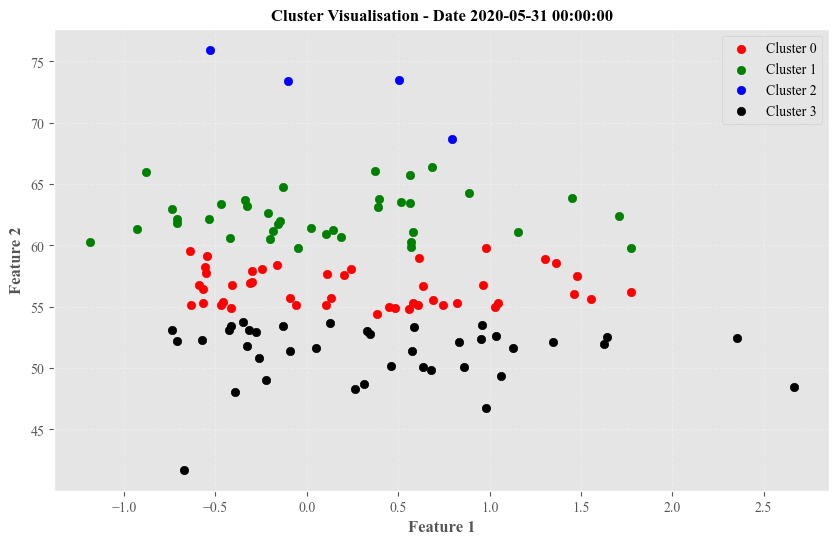

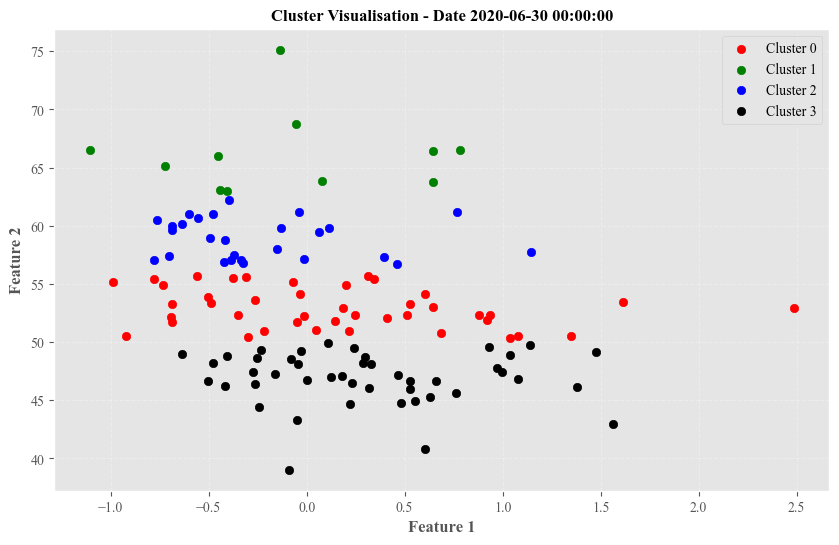

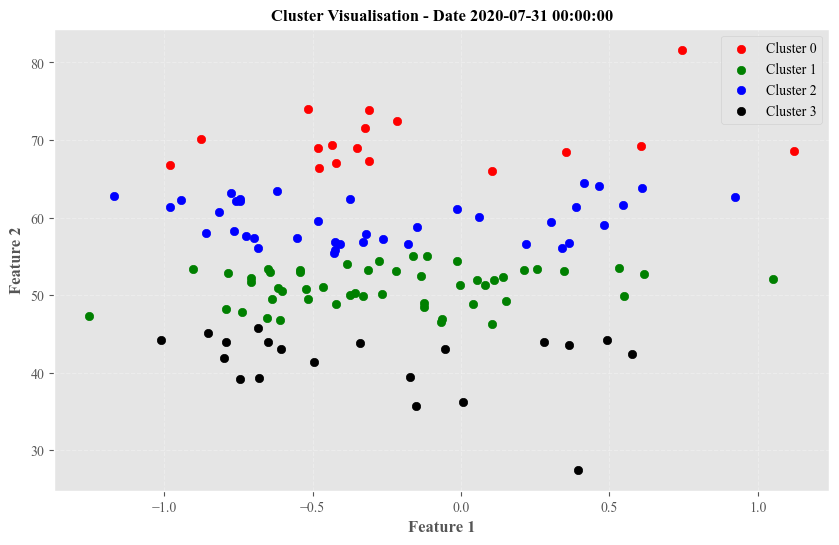

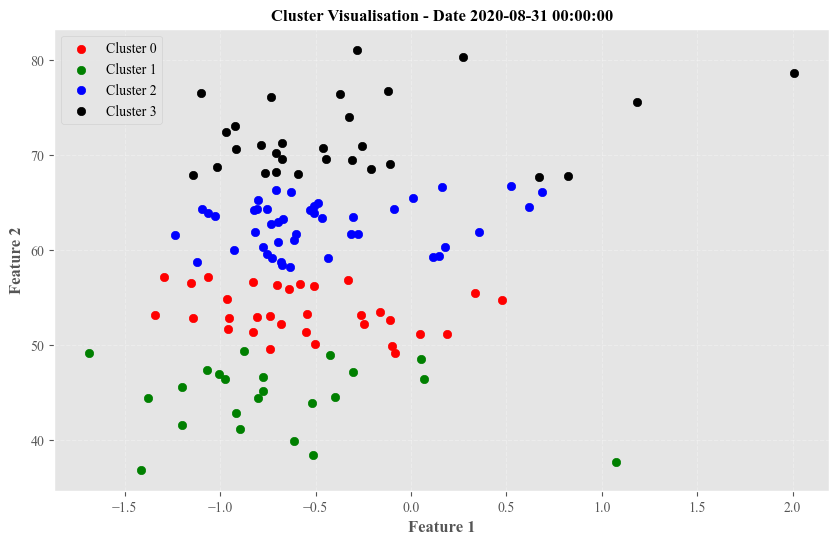

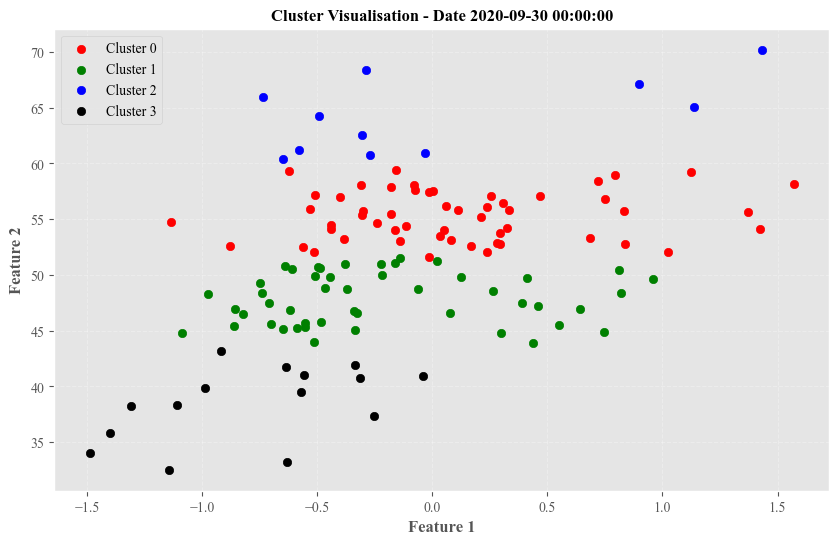

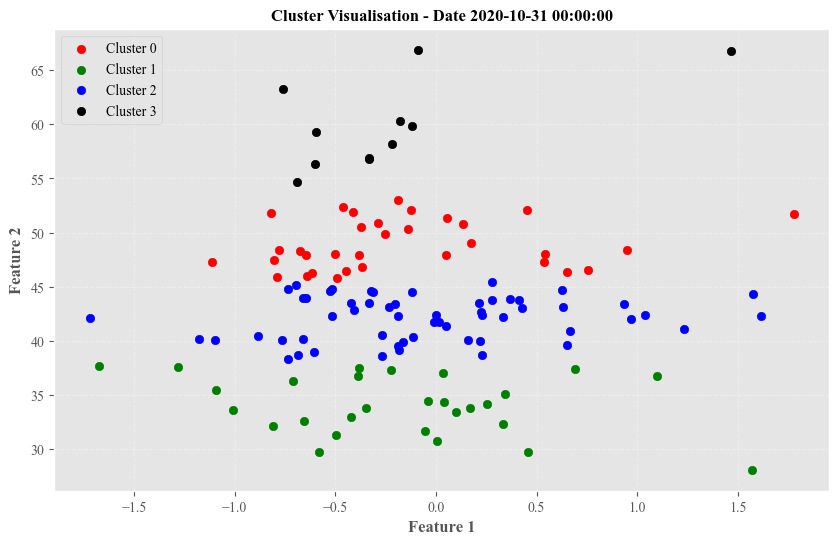

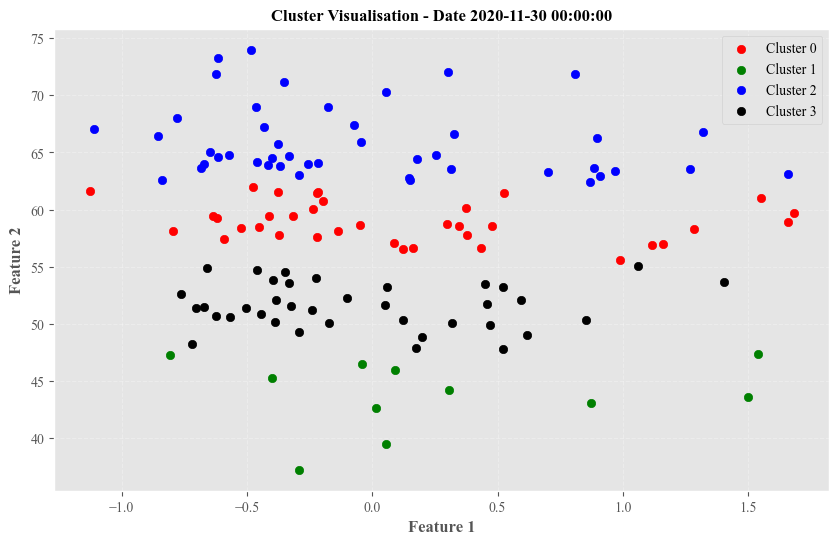

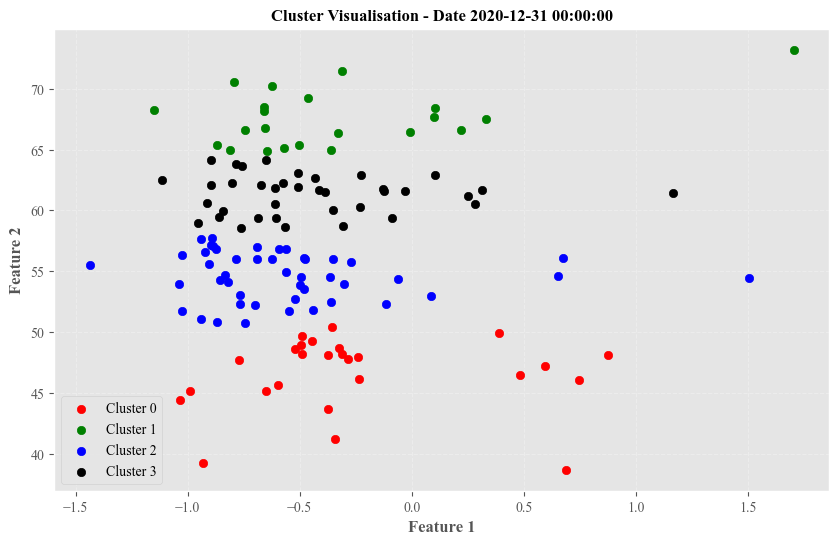

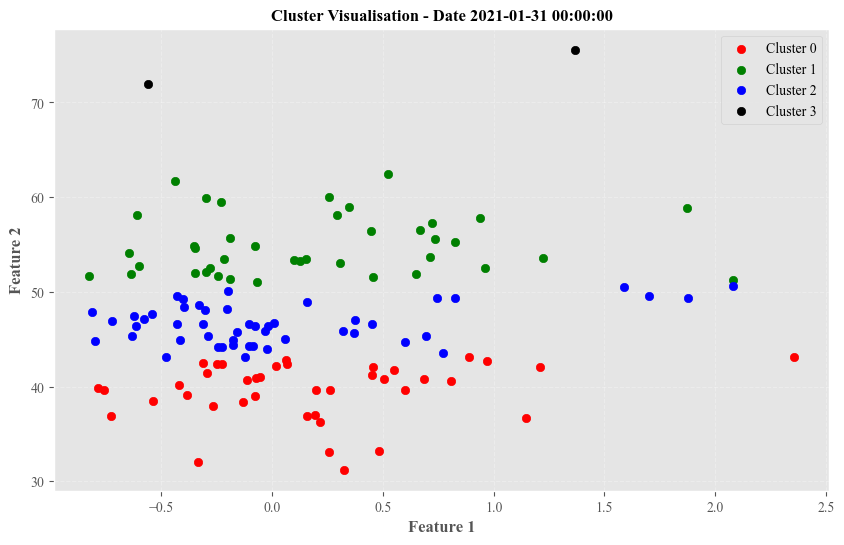

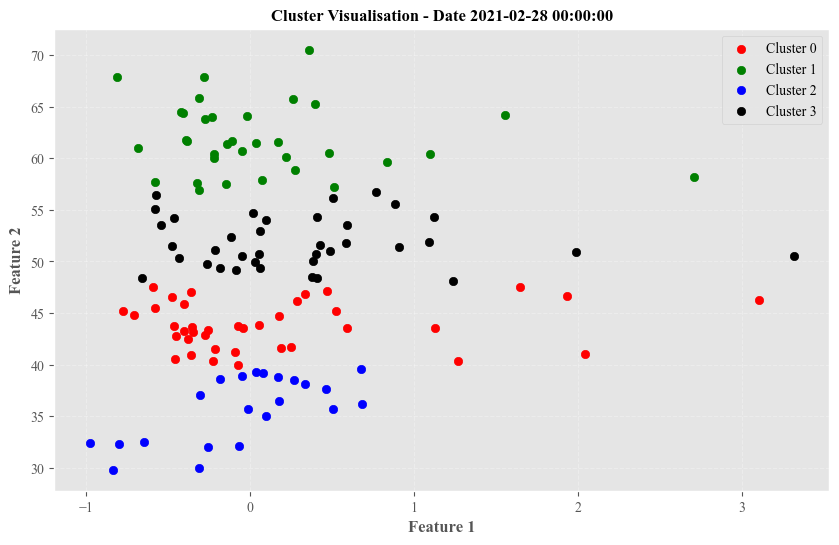

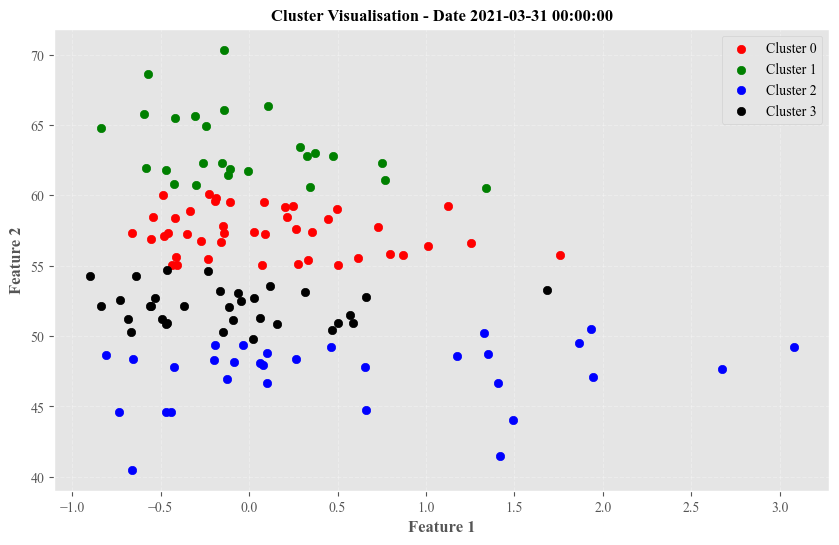

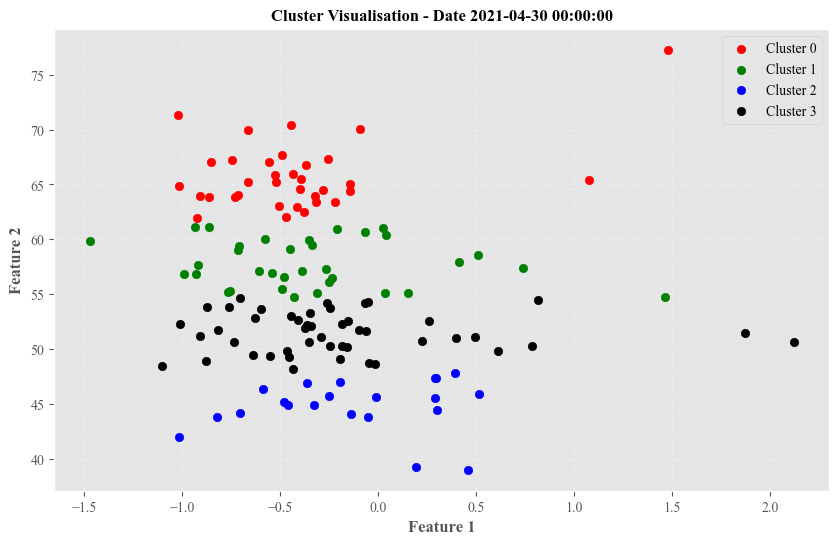

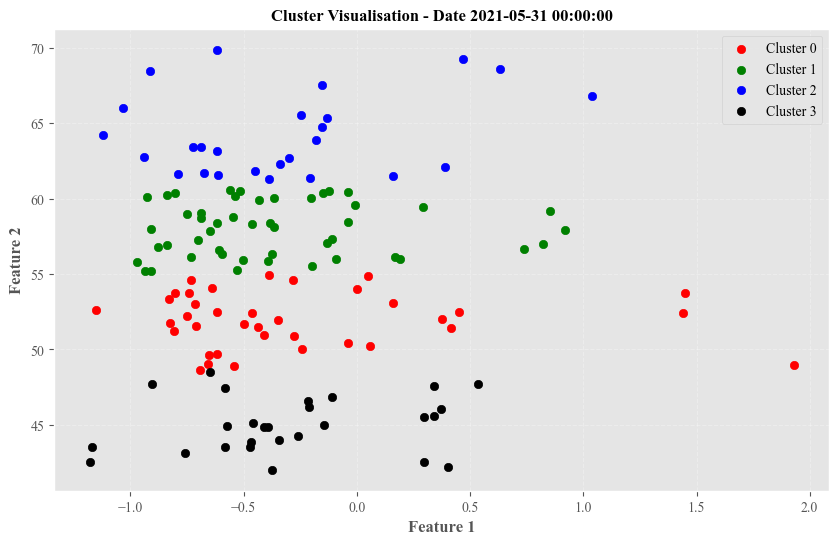

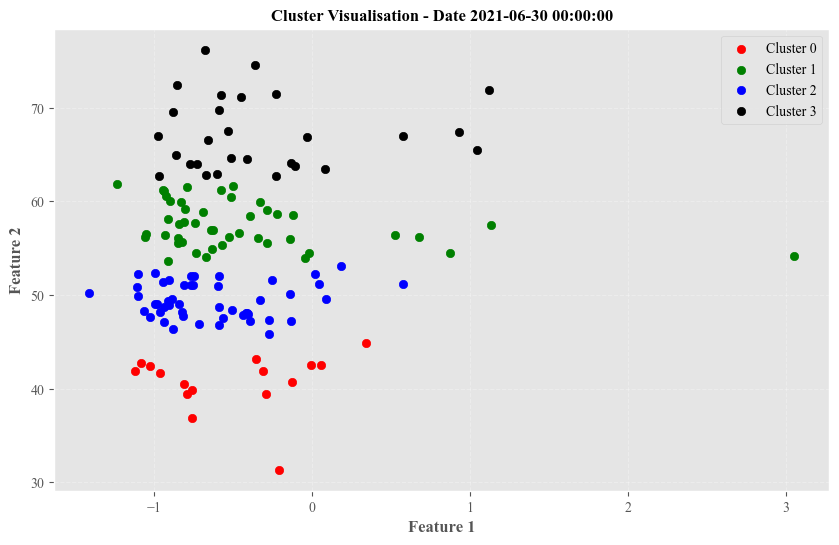

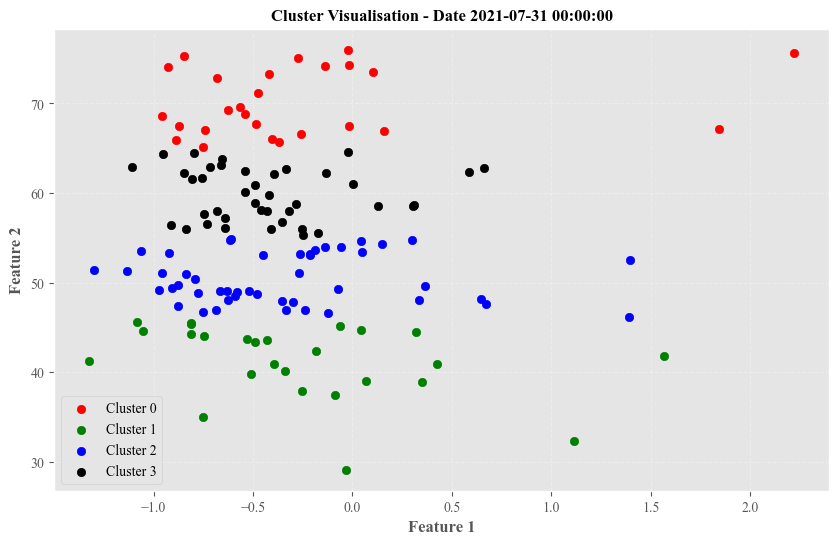

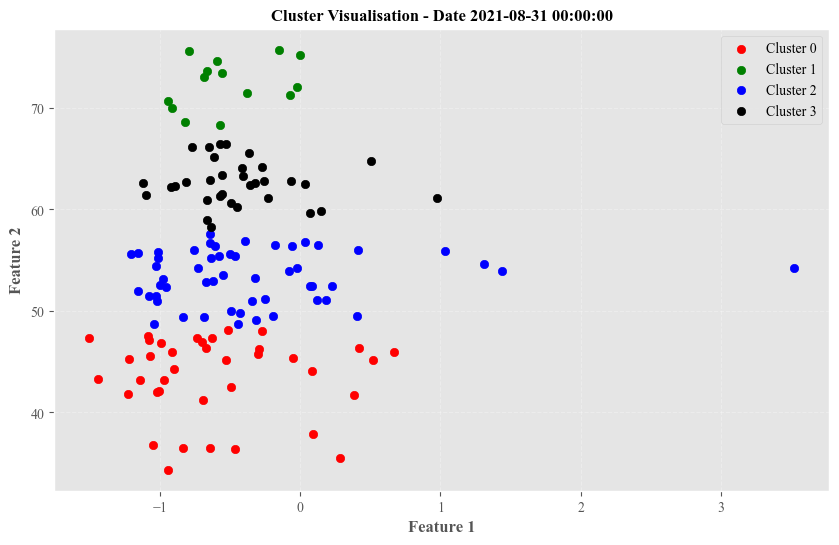

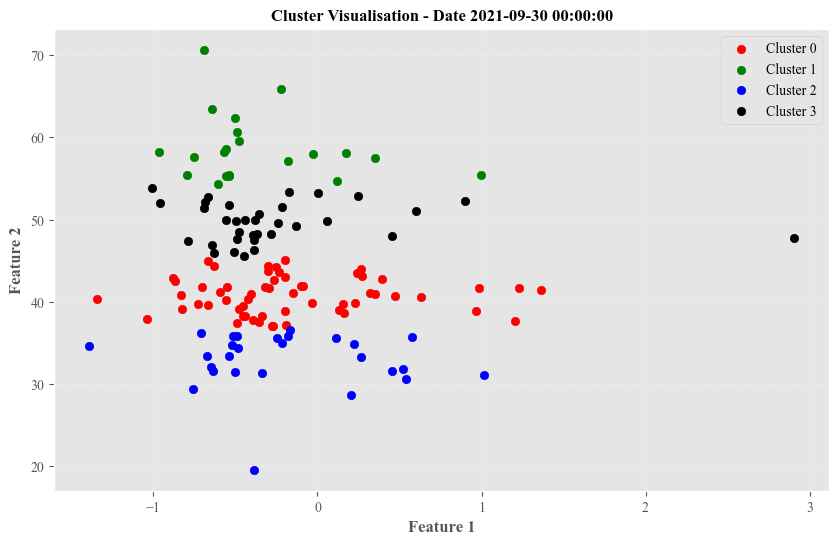

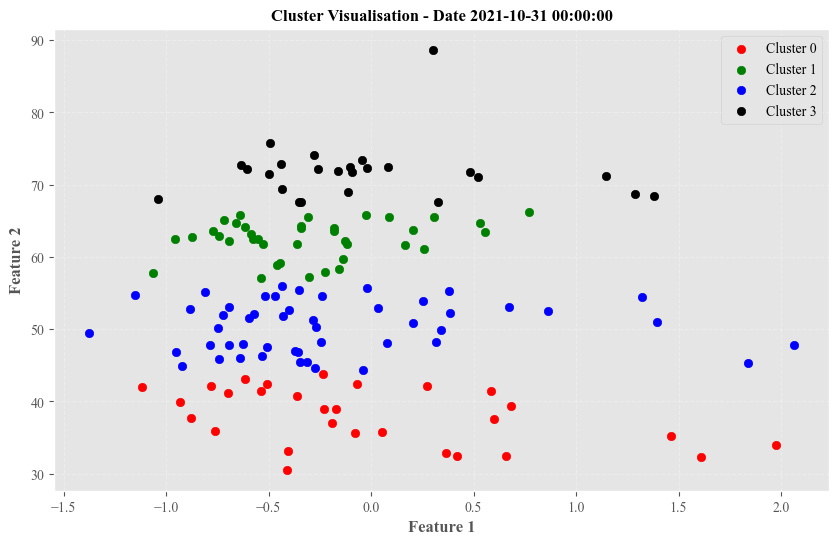

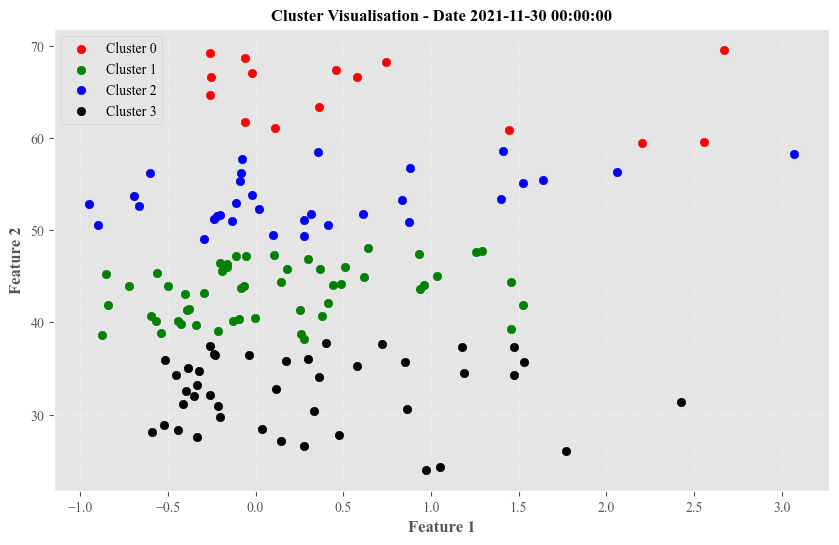

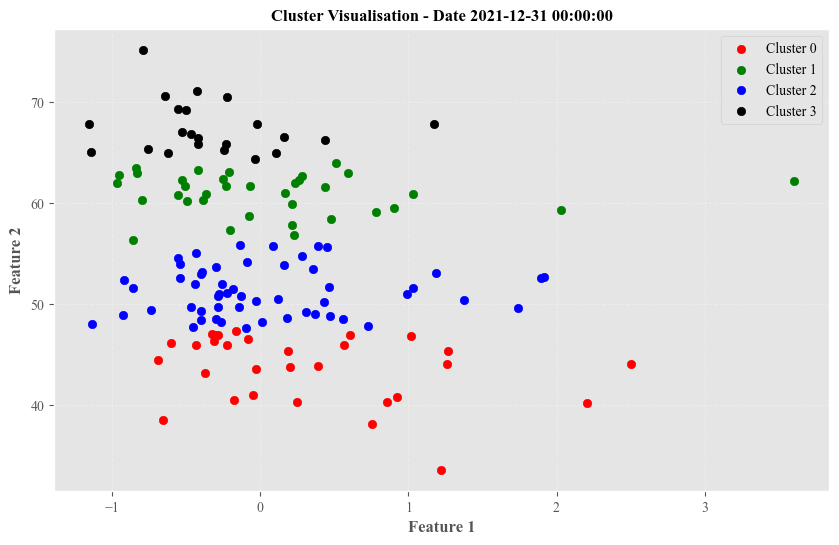

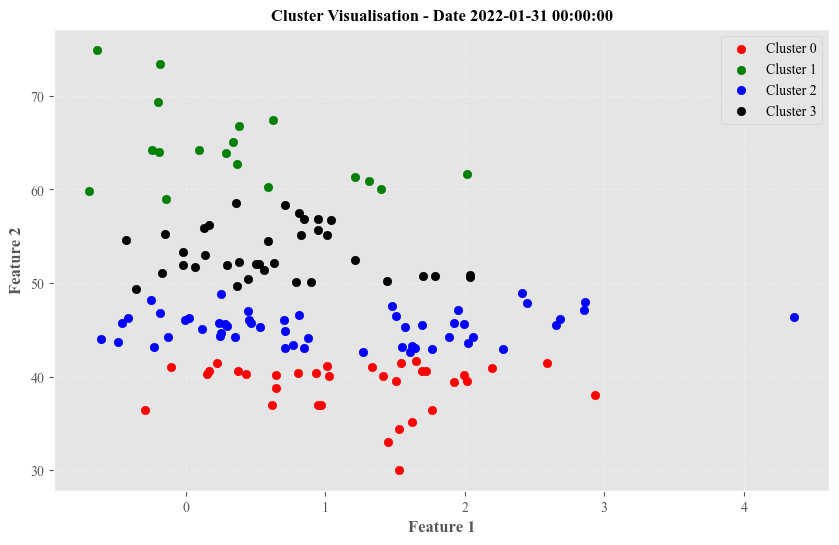

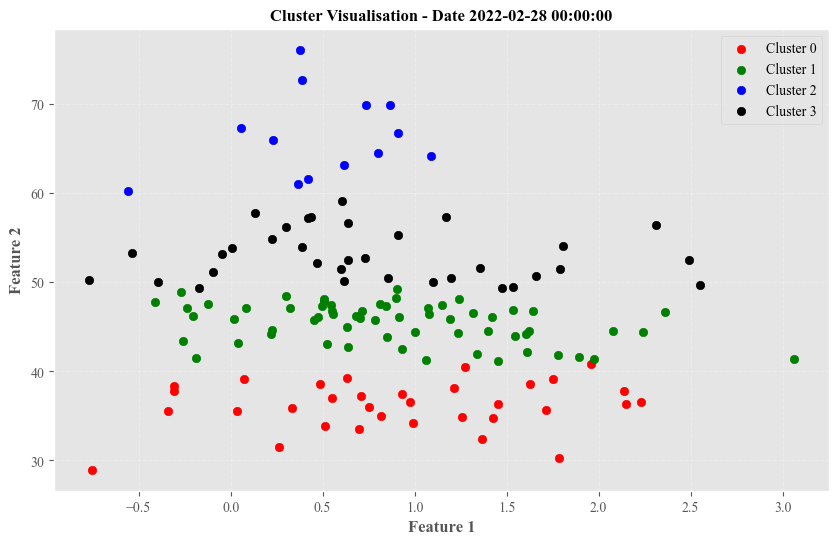

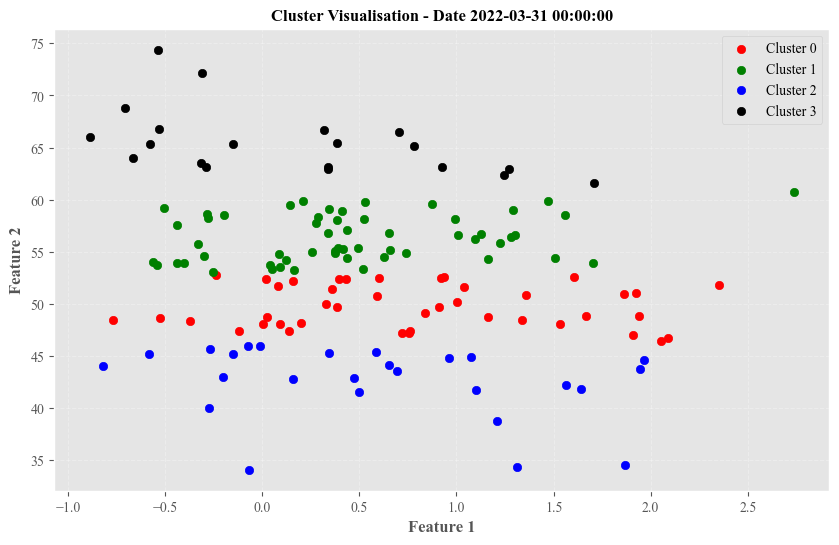

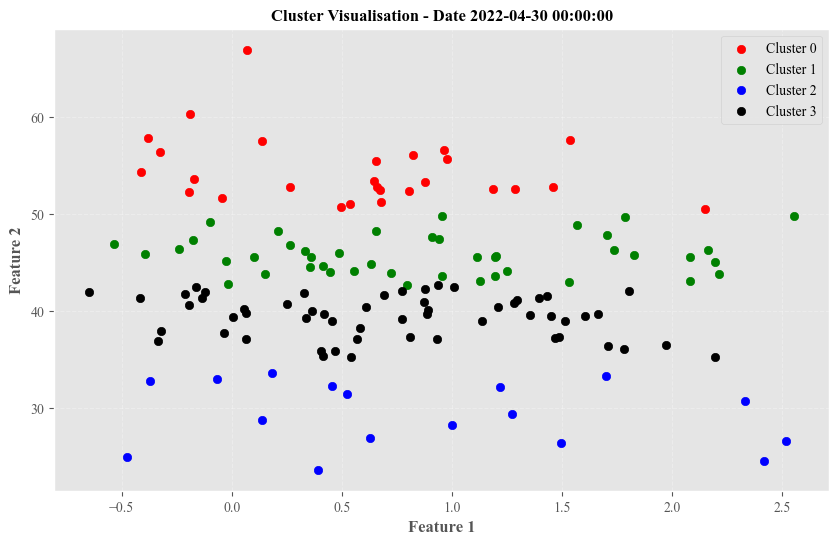

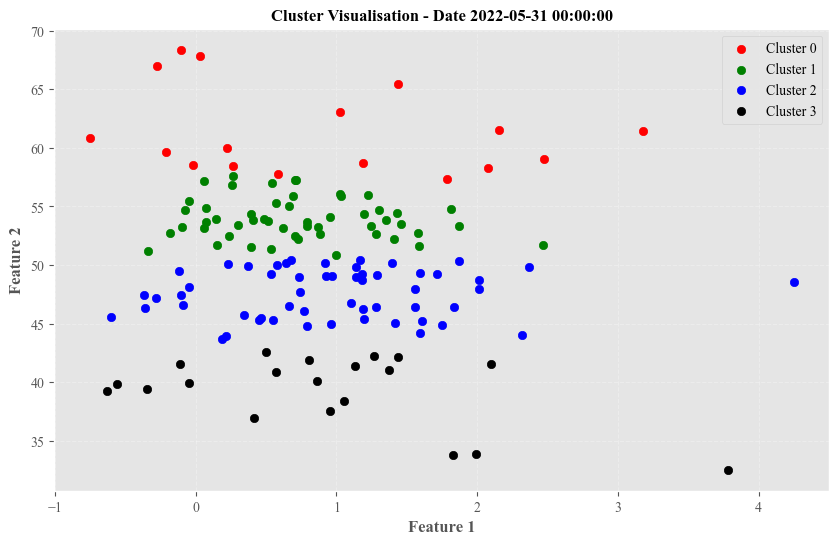

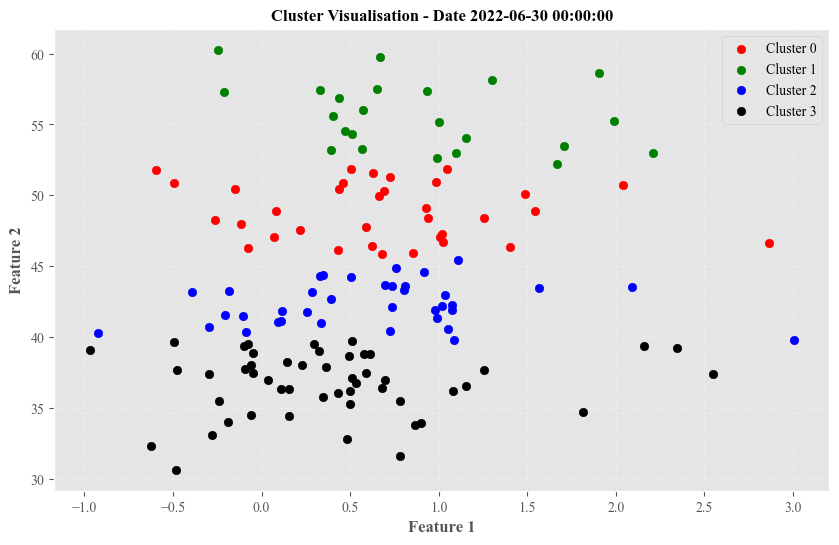

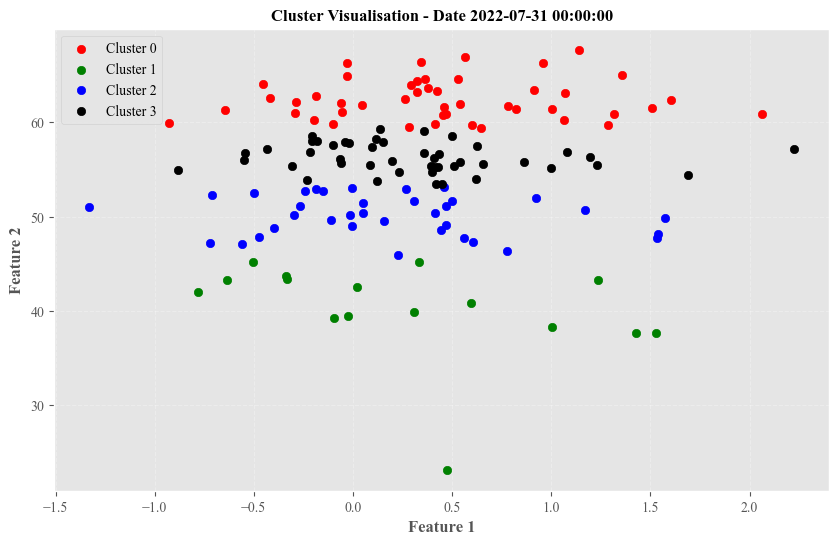

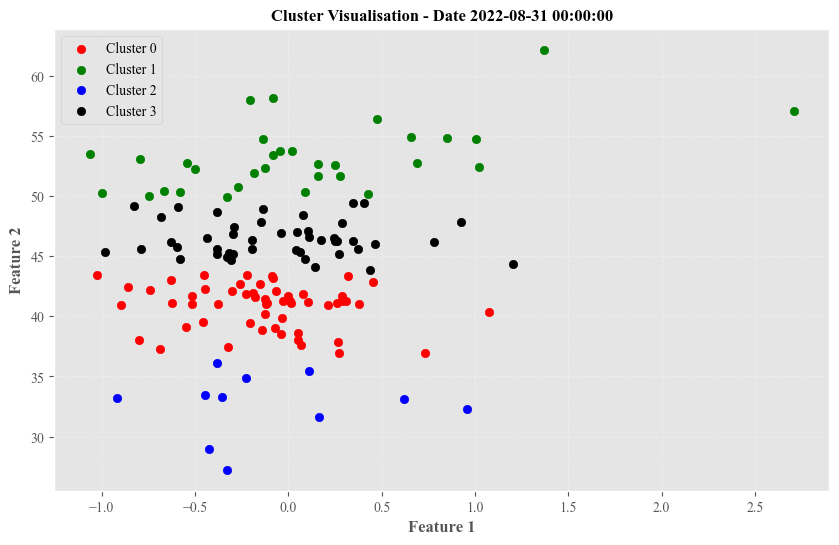

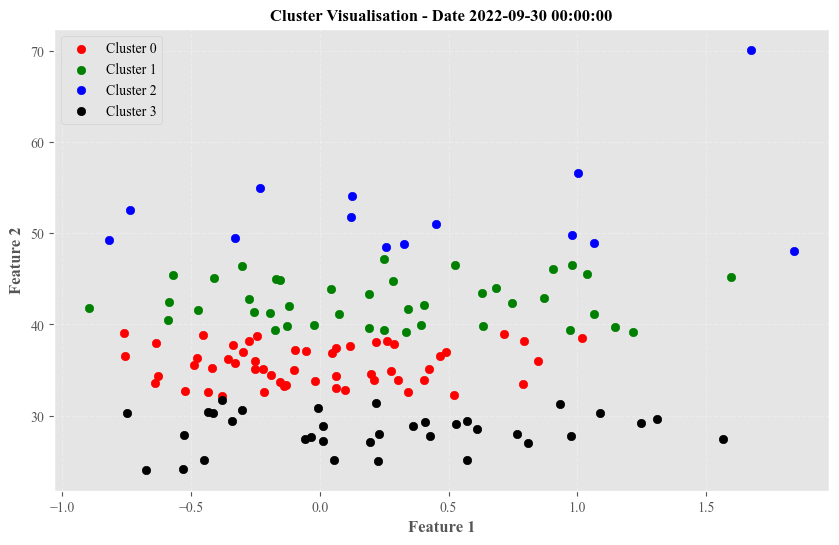

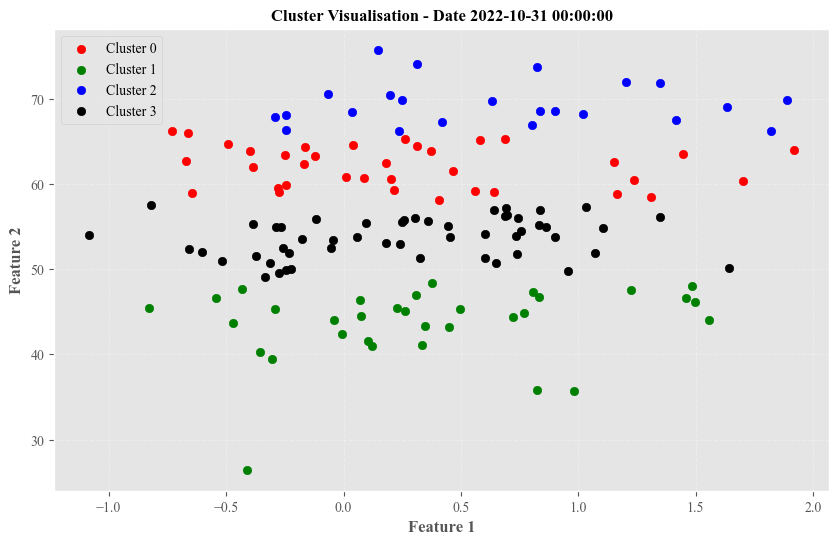

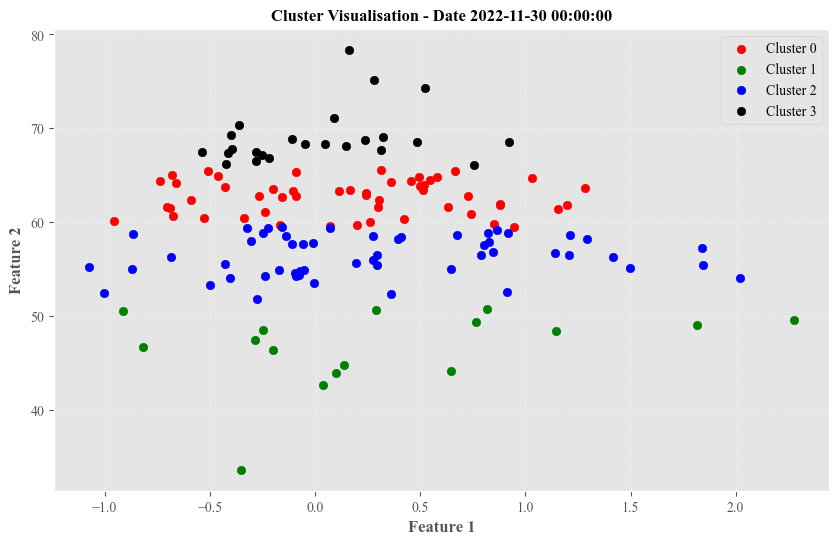

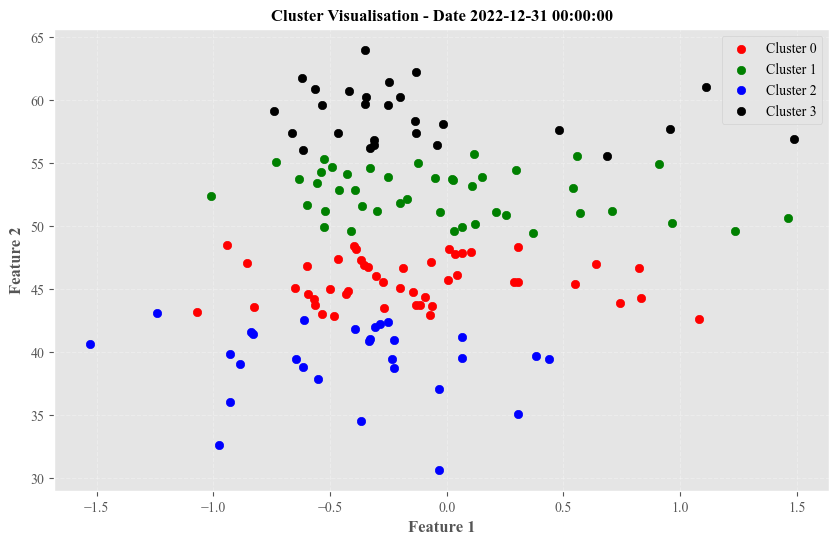

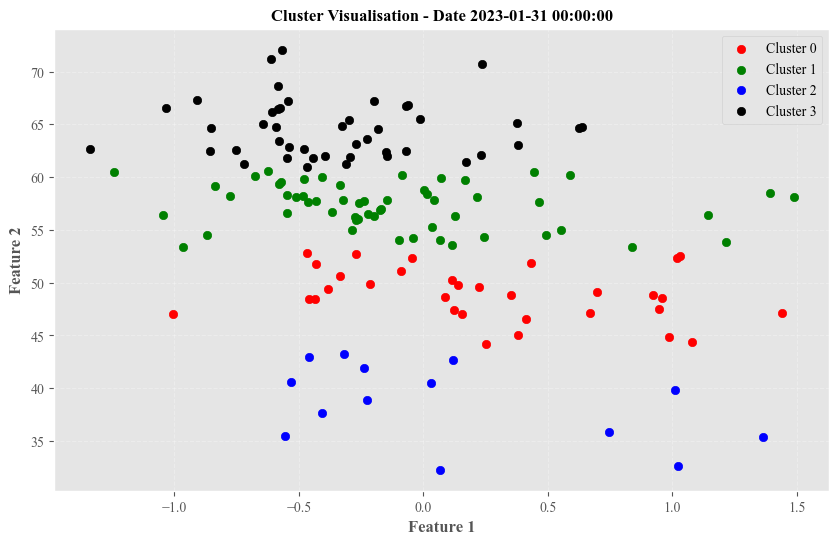

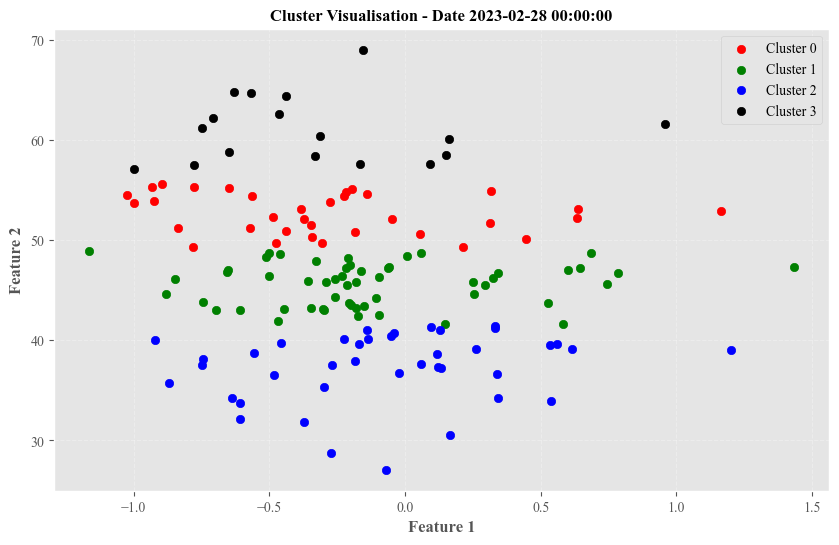

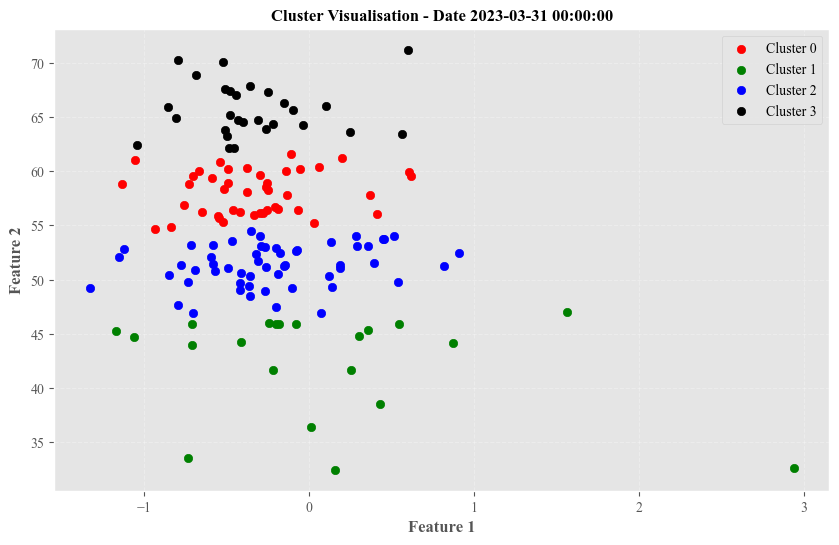

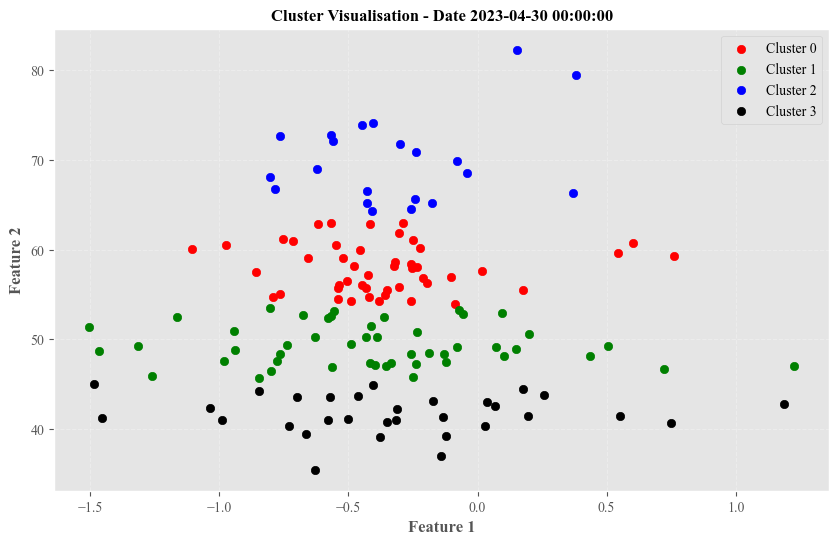

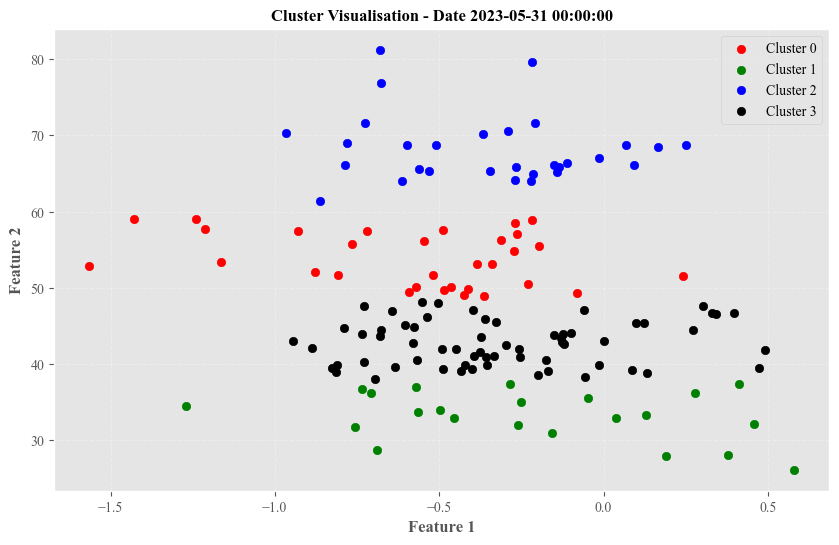

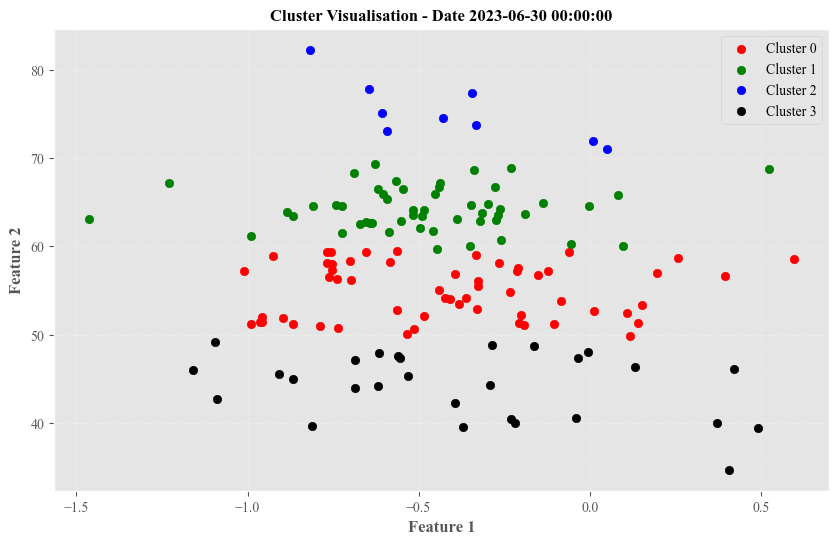

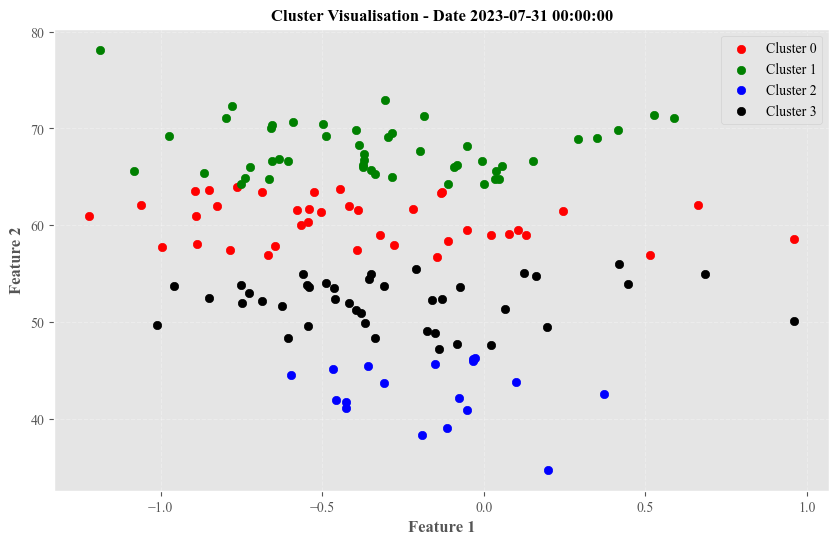

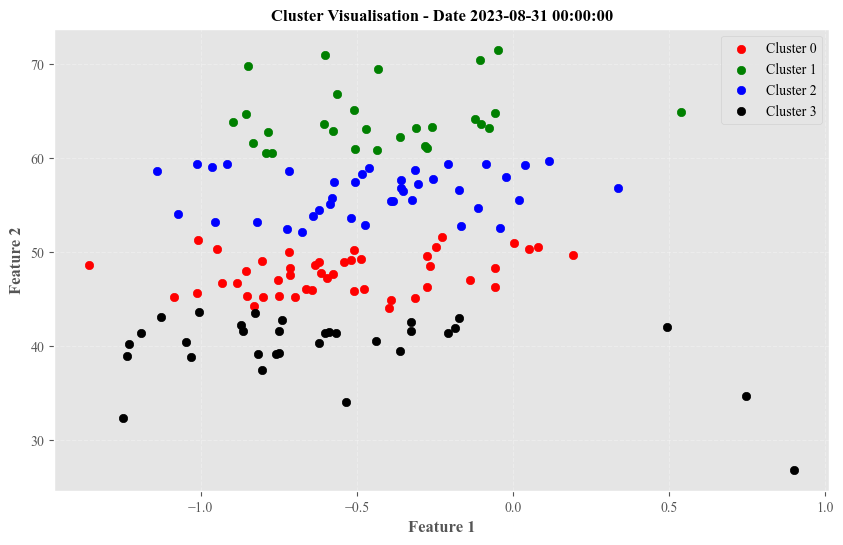

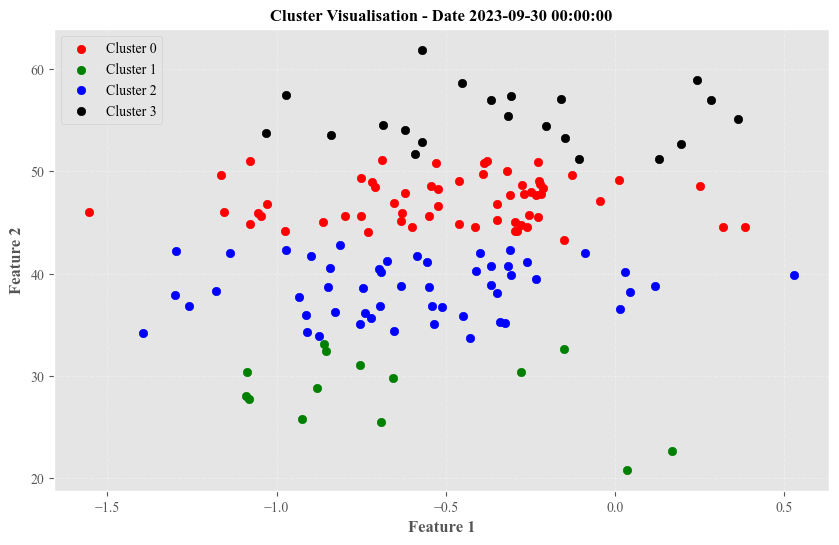

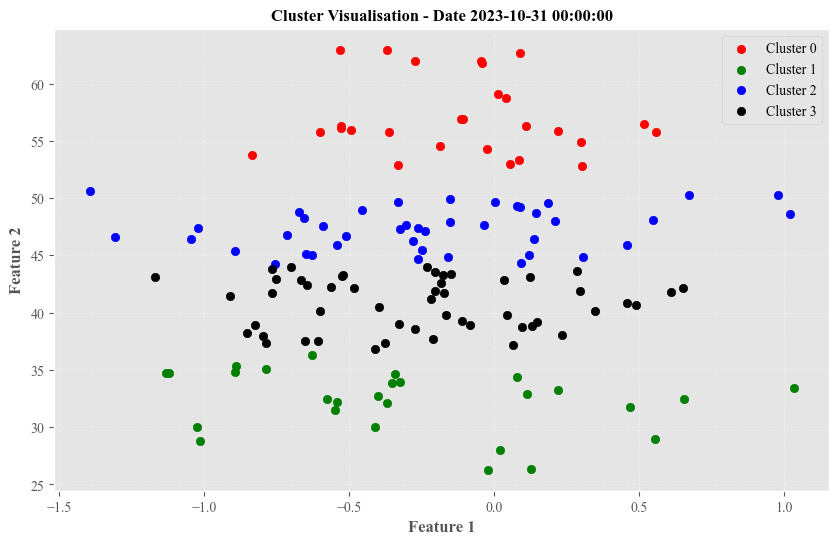

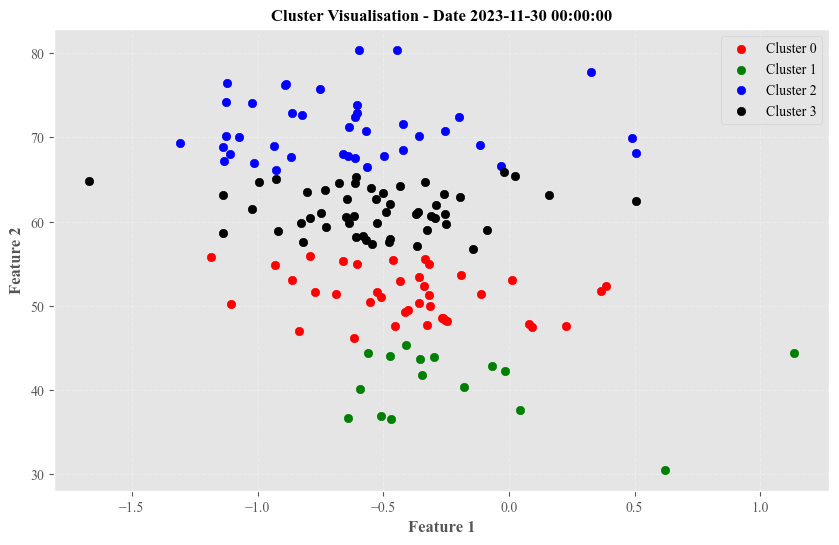

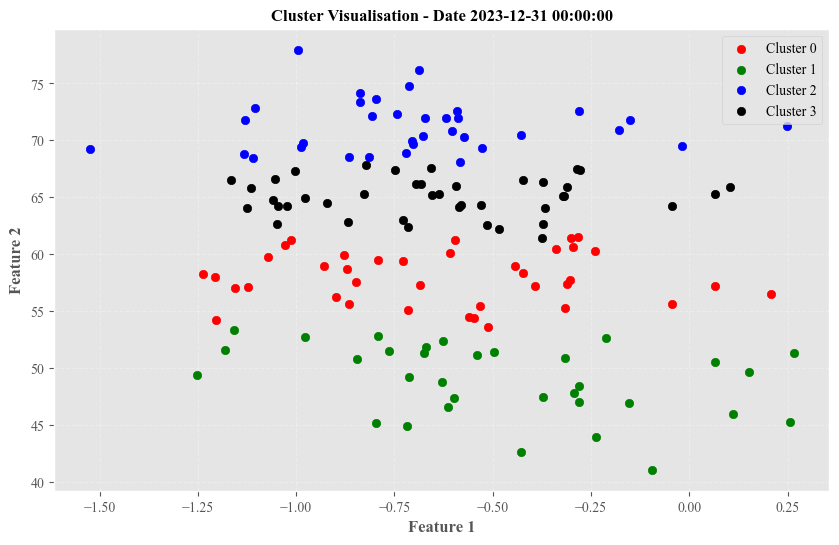

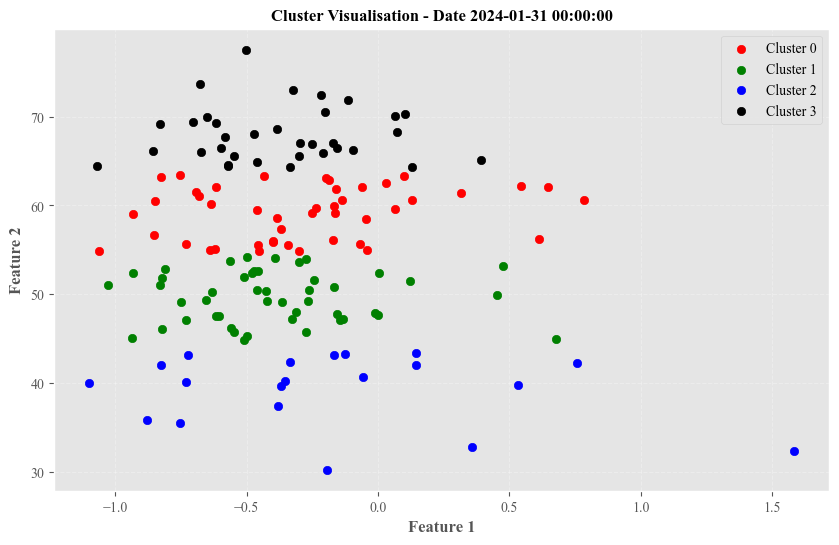

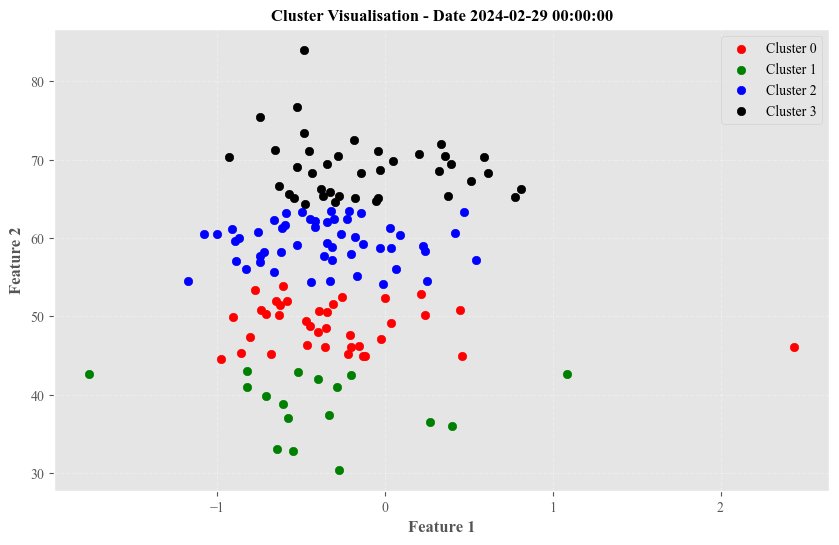

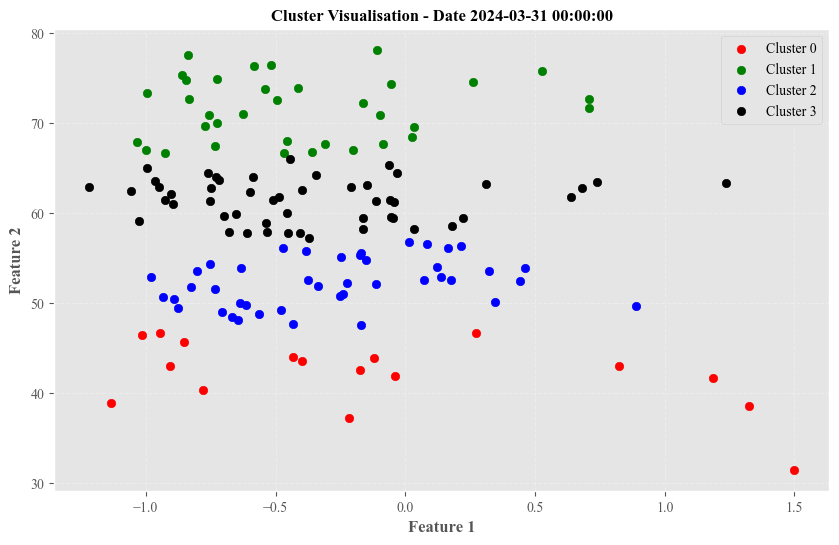

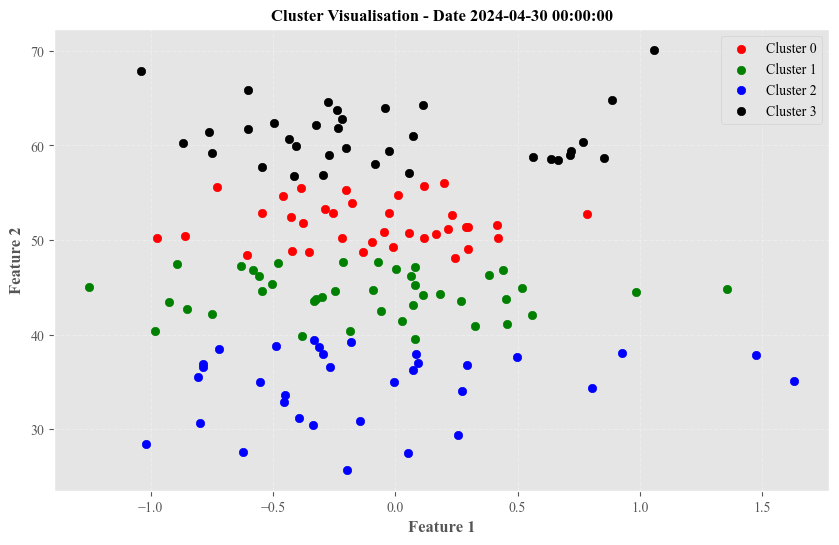

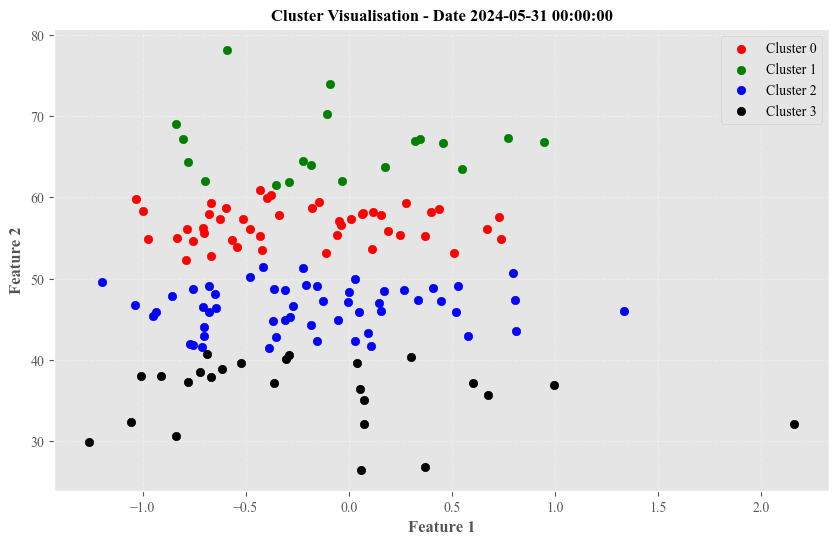

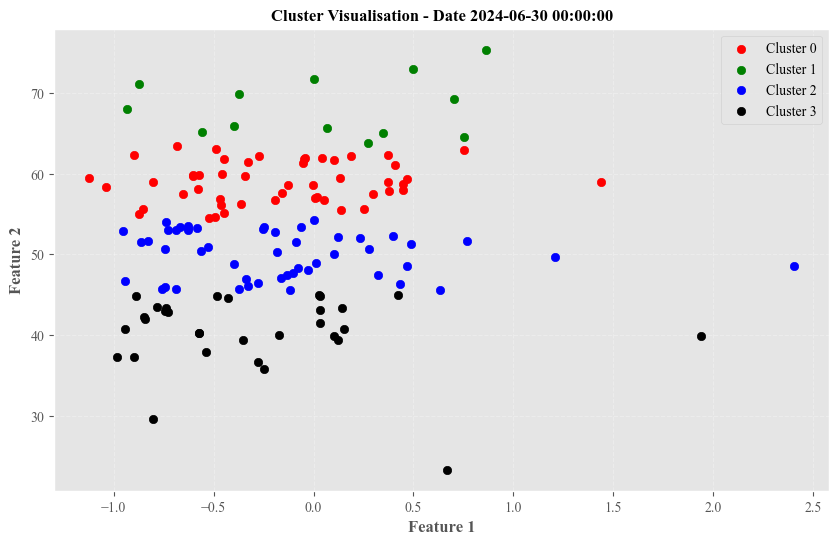

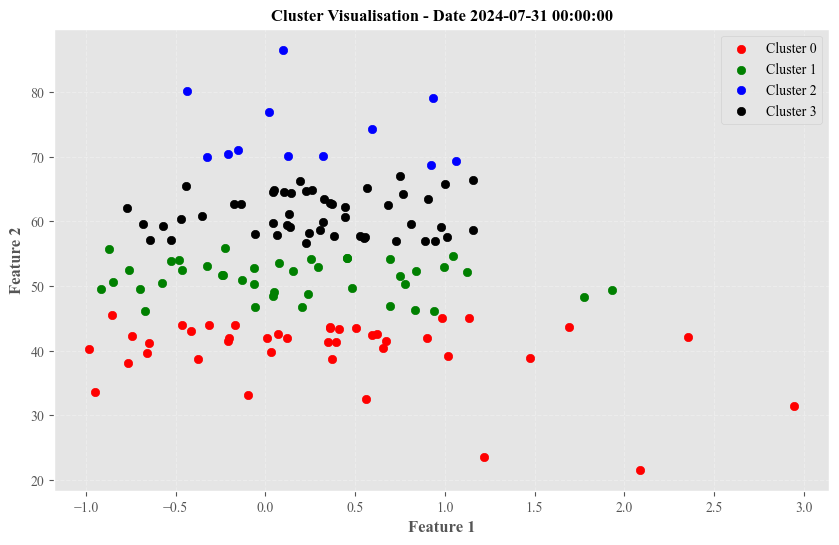

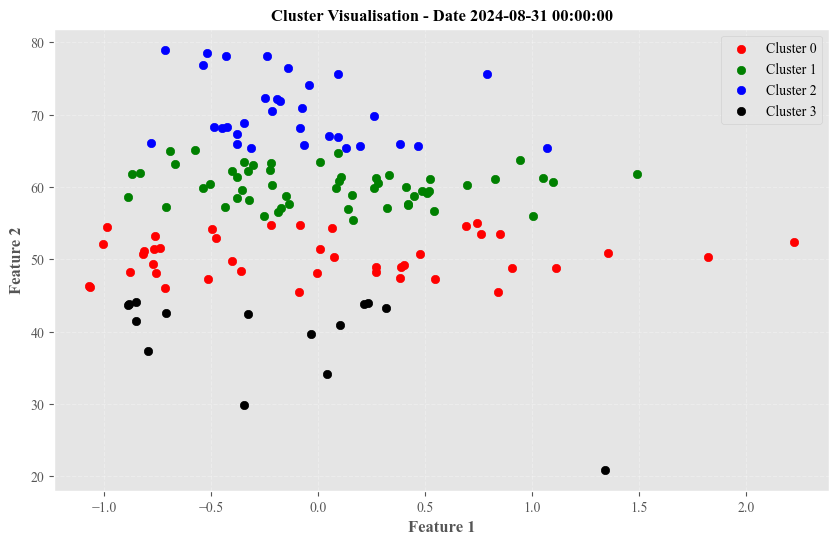

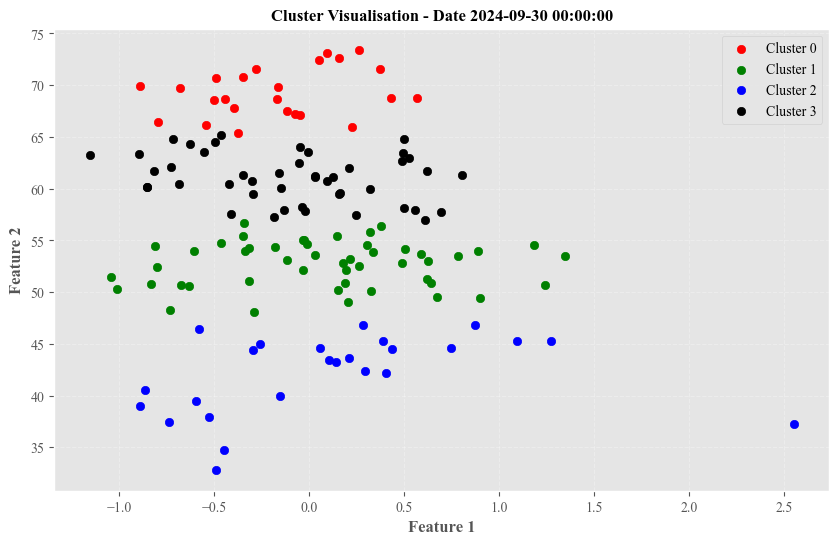

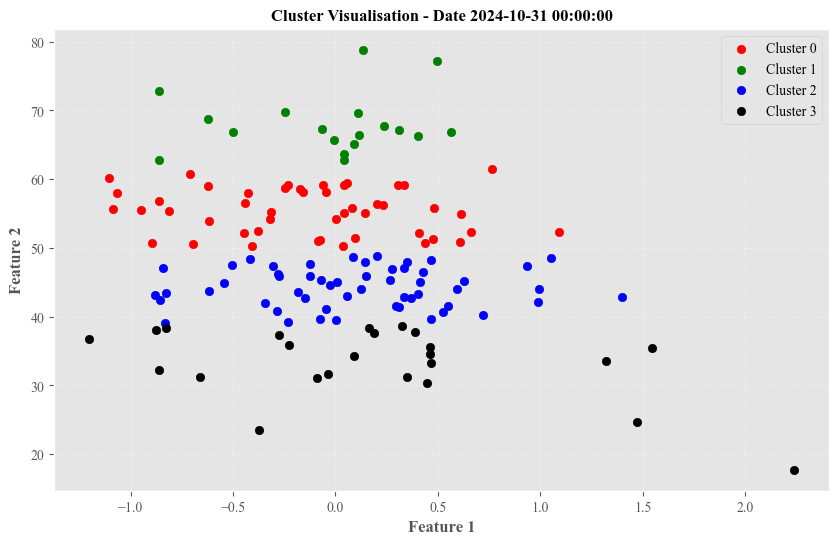

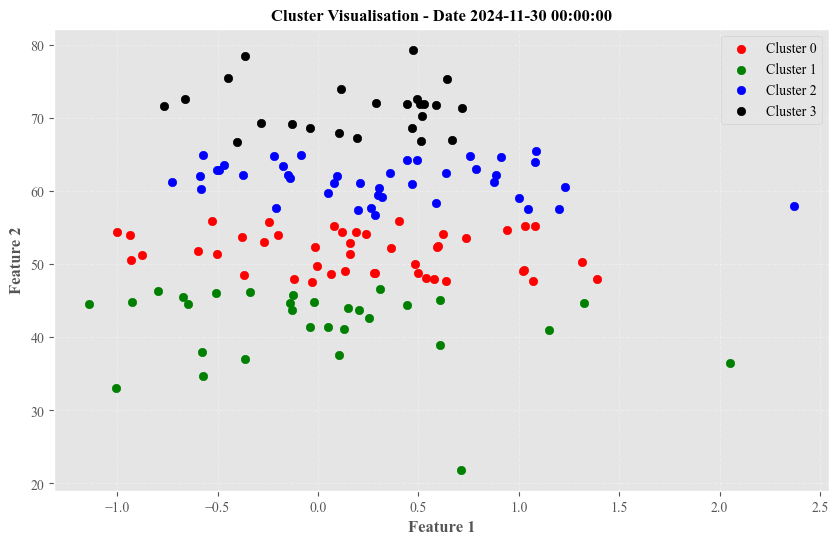

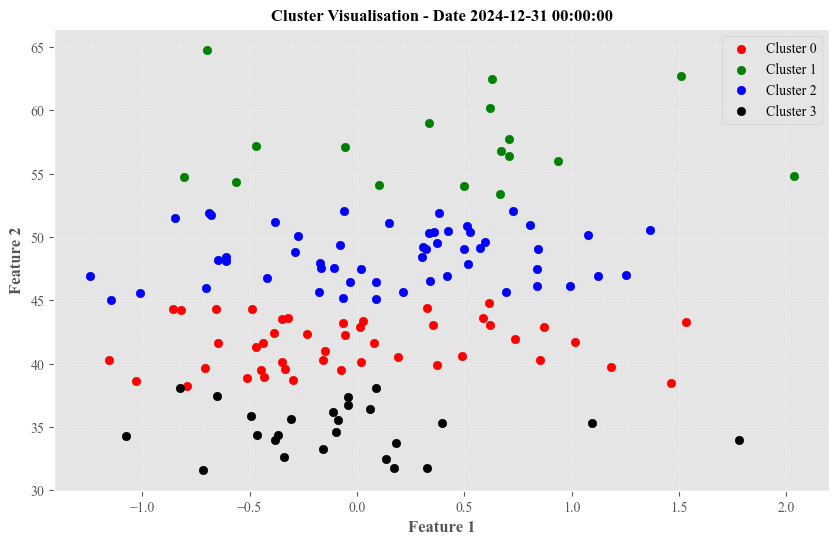

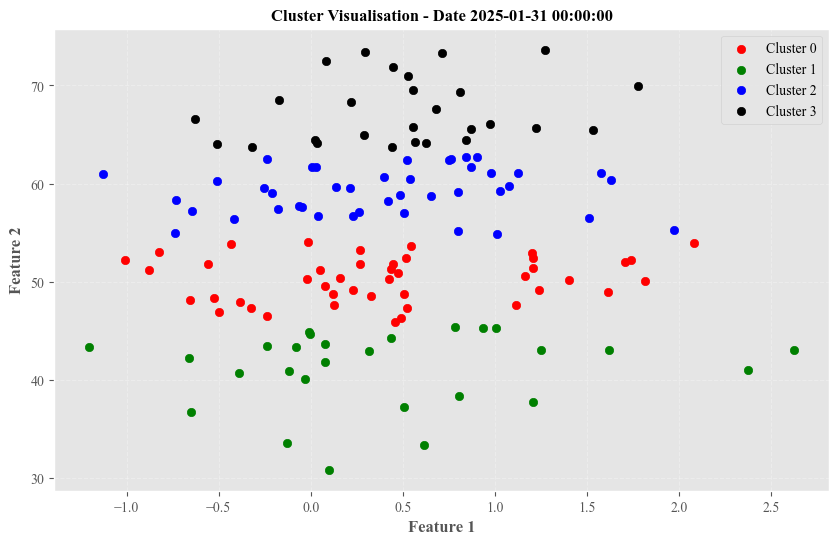

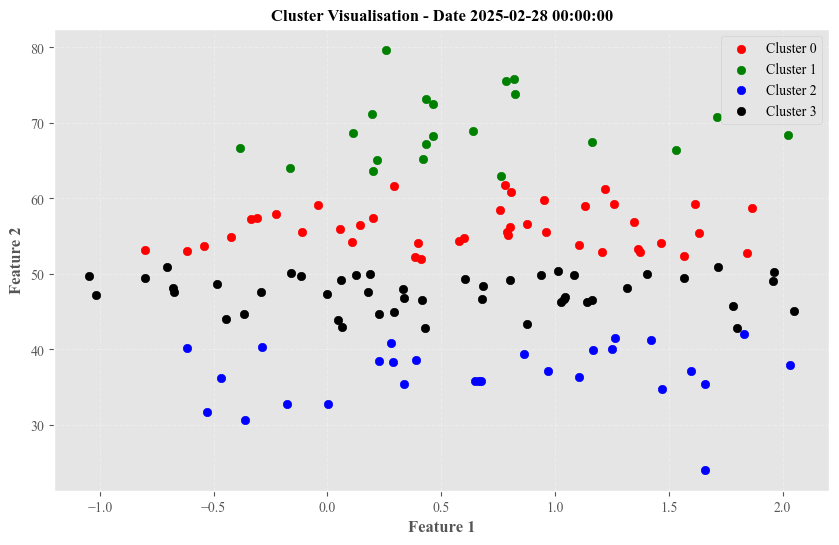

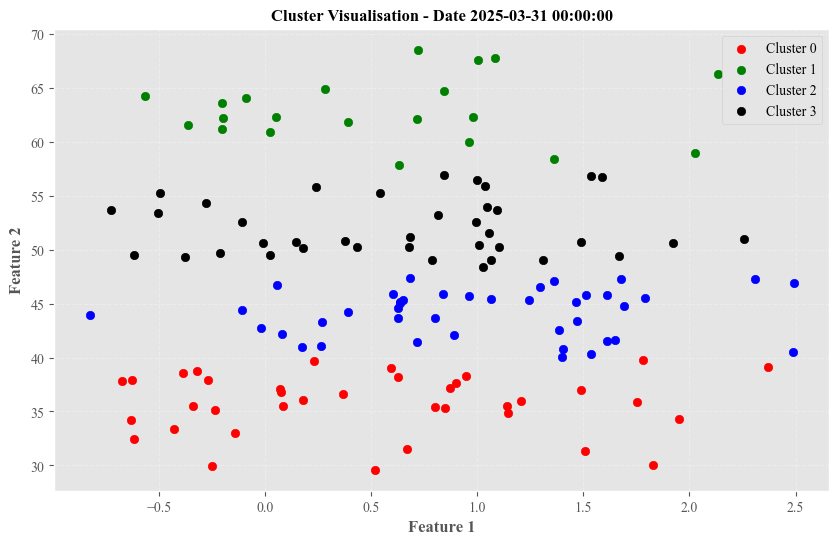

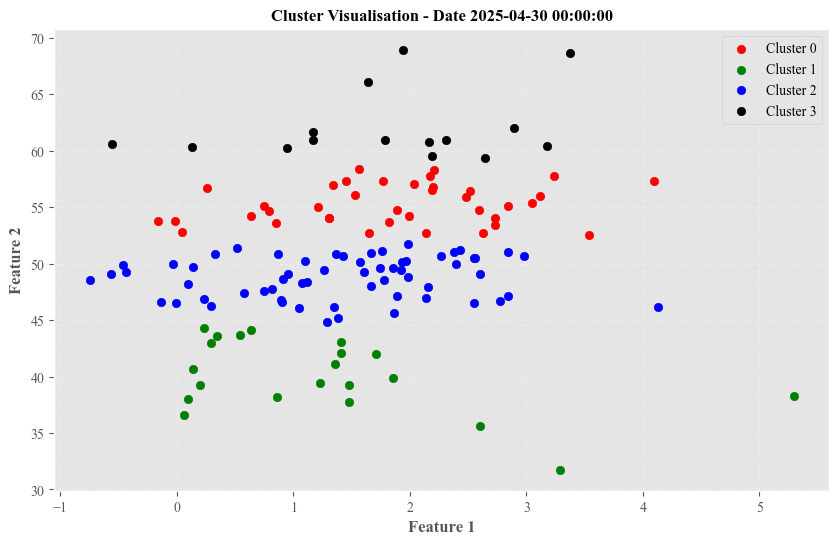

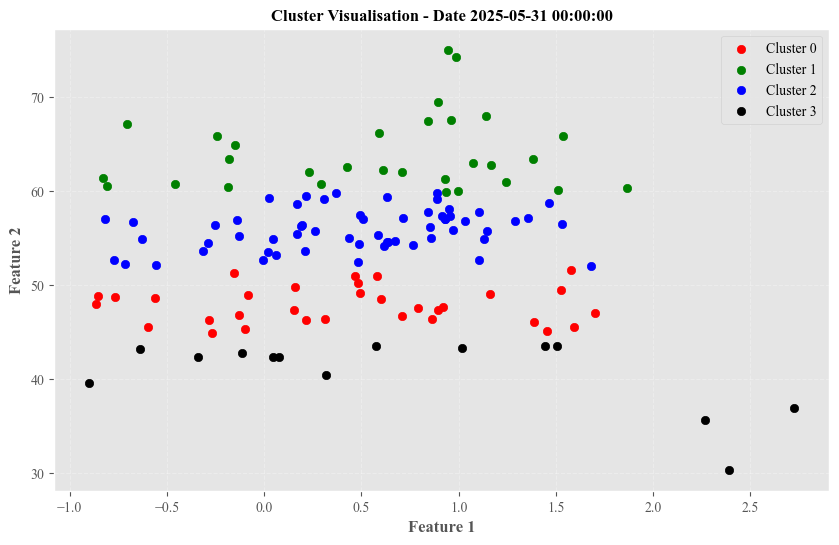

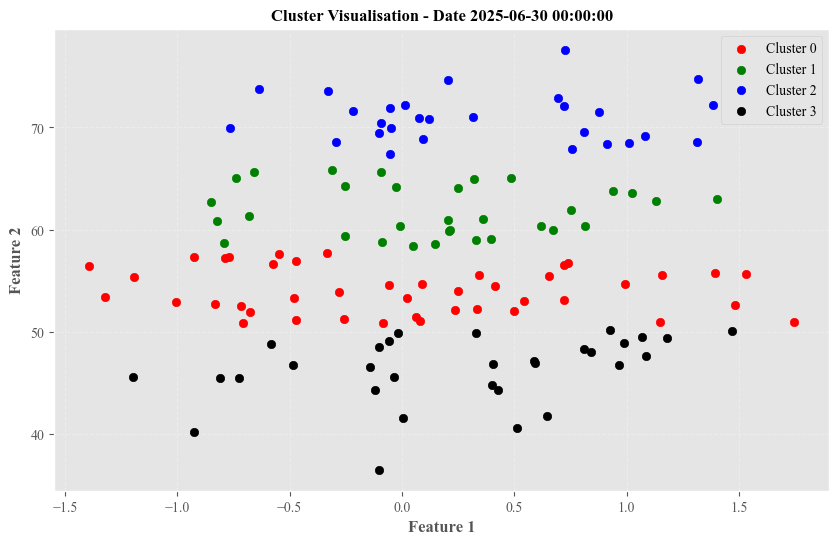

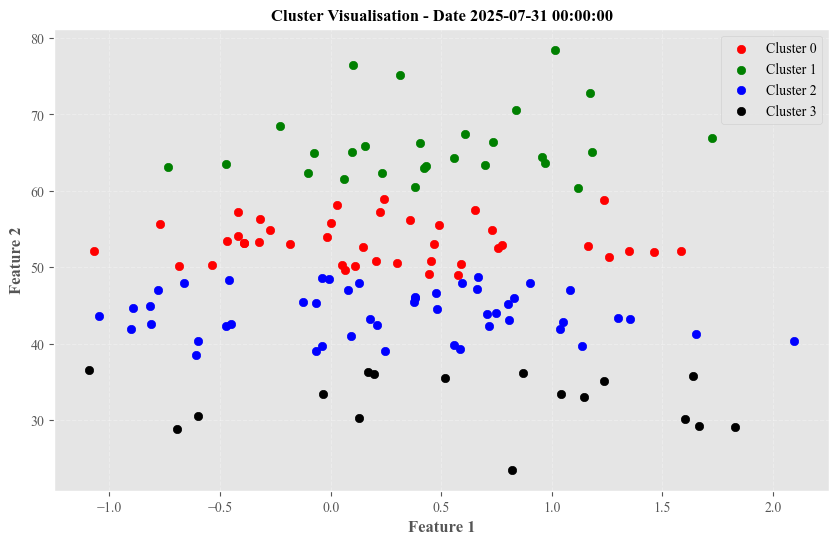

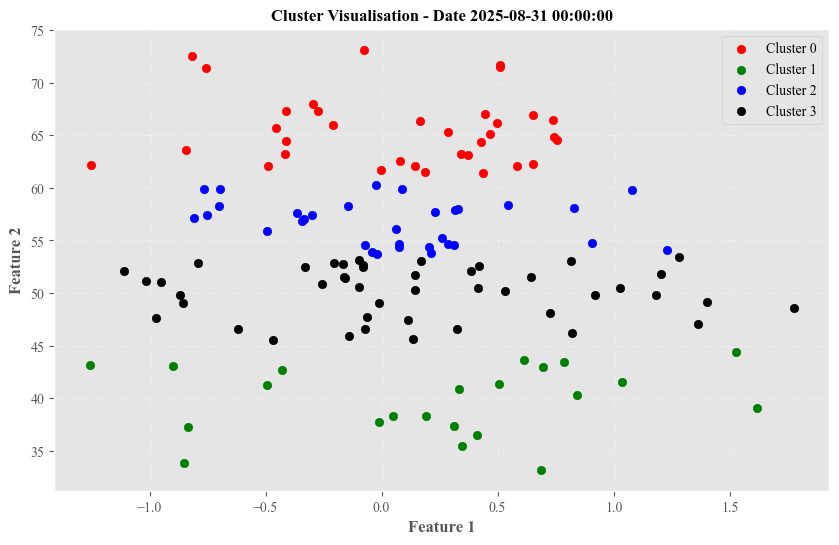

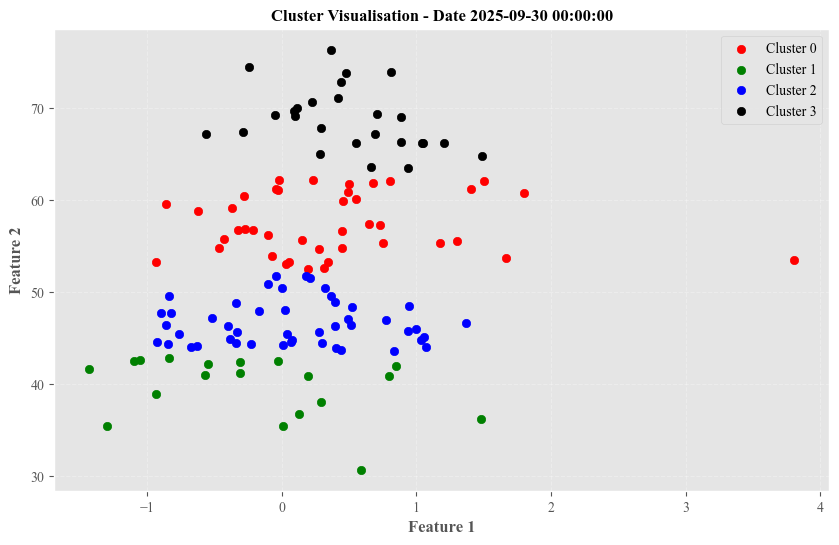

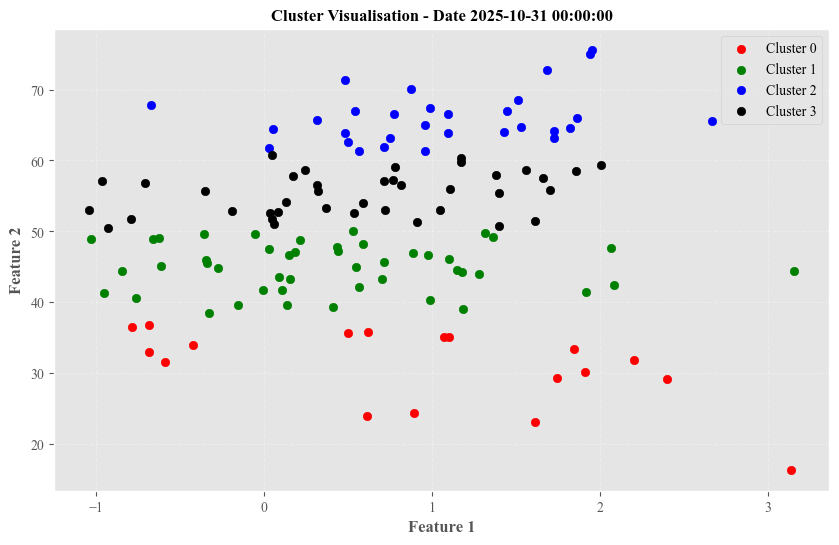

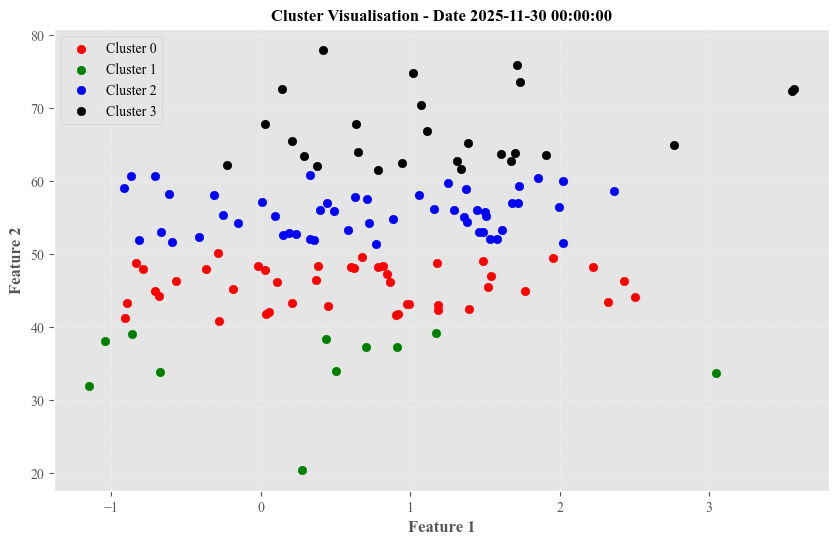

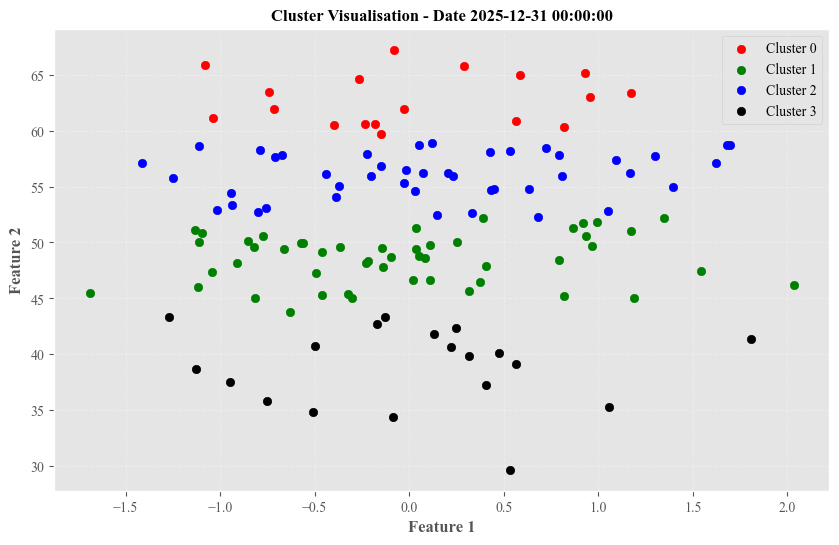

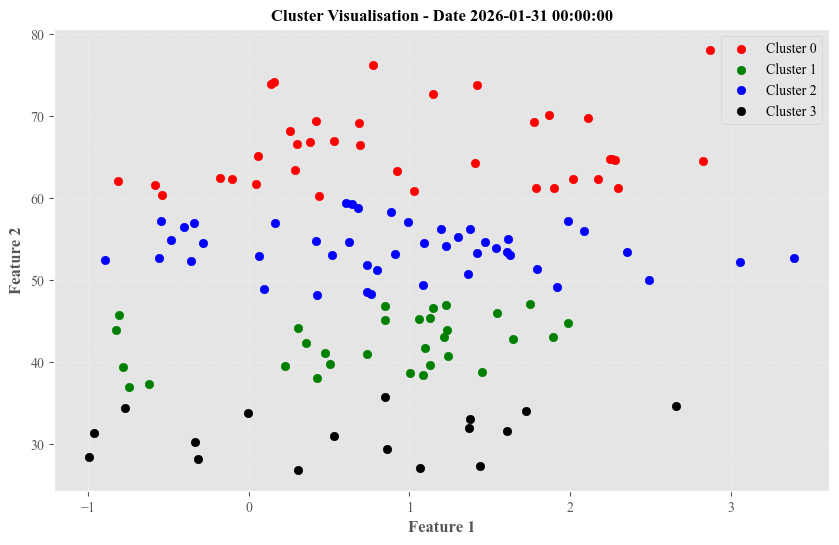

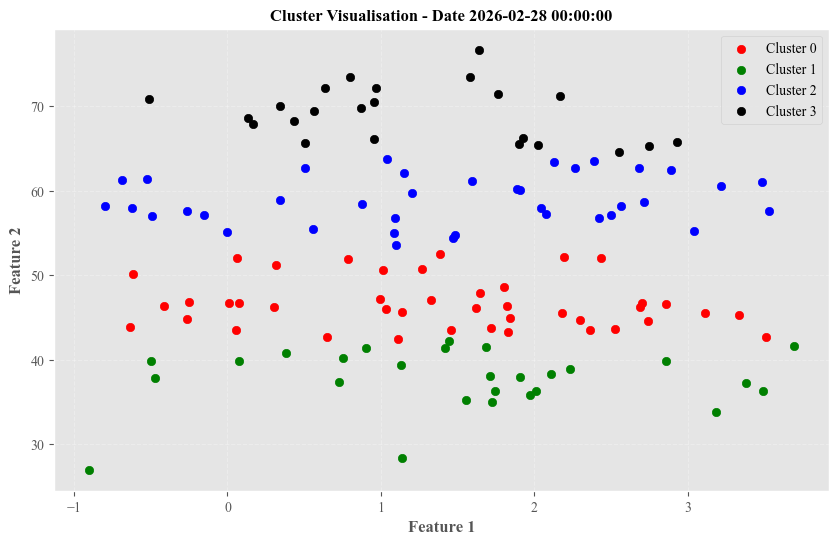

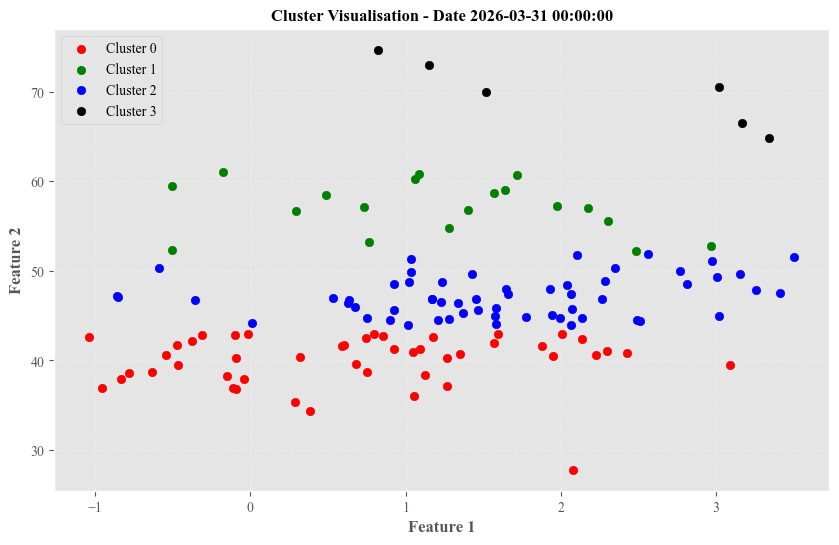

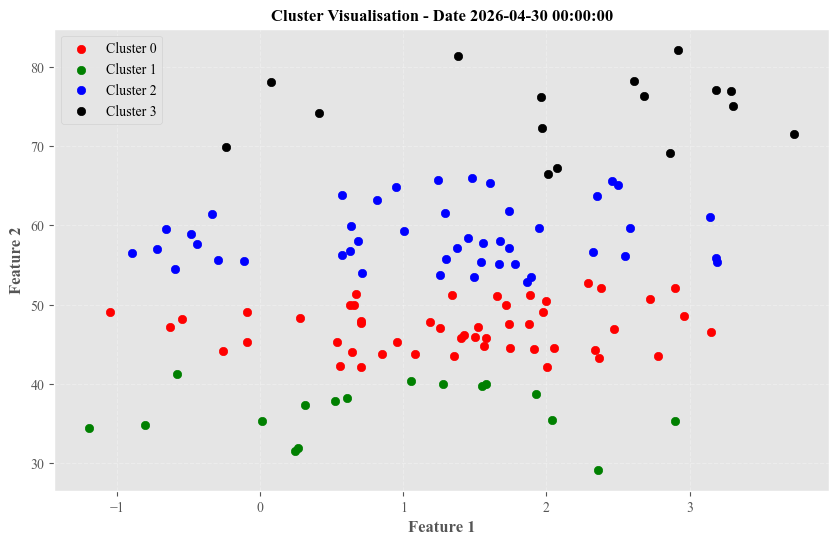

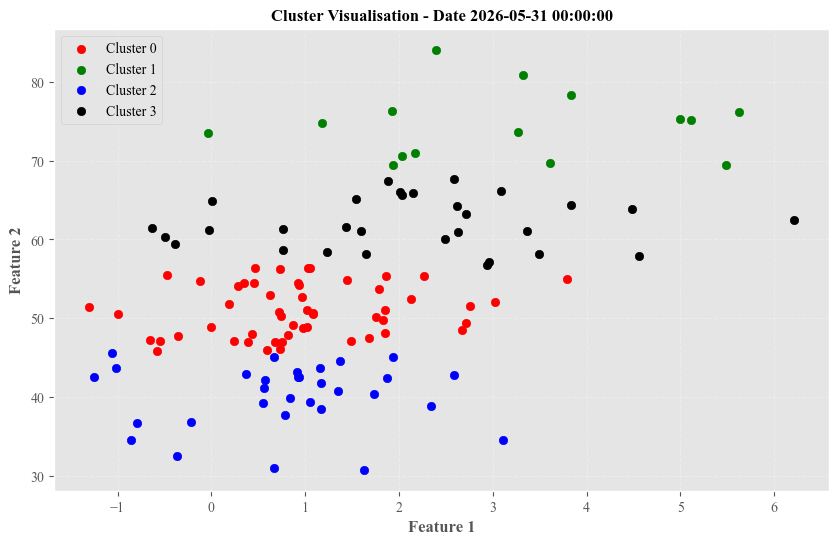

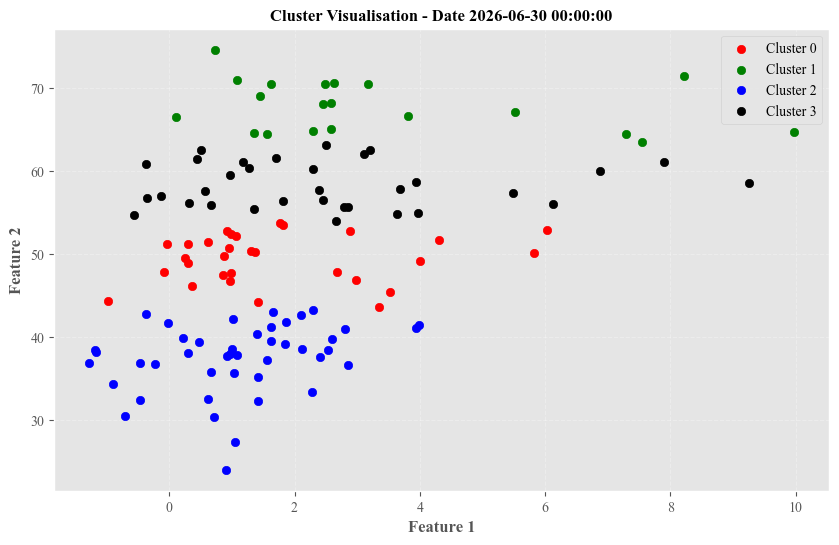

In [23]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'
plt.style.use('ggplot')

def plot_clusters(data, ax, date_label):

    cluster_0 = data[data['cluster'] == 0]
    cluster_1 = data[data['cluster'] == 1]
    cluster_2 = data[data['cluster'] == 2]
    cluster_3 = data[data['cluster'] == 3]

    ax.scatter(cluster_0.iloc[:, 5], cluster_0.iloc[:, 1], color = 'red', label = 'Cluster 0')
    ax.scatter(cluster_1.iloc[:, 5], cluster_1.iloc[:, 1], color = 'green', label = 'Cluster 1')
    ax.scatter(cluster_2.iloc[:, 5], cluster_2.iloc[:, 1], color = 'blue', label = 'Cluster 2')
    ax.scatter(cluster_3.iloc[:, 5], cluster_3.iloc[:, 1], color = 'black', label = 'Cluster 3')

    ax.set_title(f"Cluster Visualisation - Date {date_label}", 
                 fontweight = 'bold', fontsize = 12)

    ax.set_xlabel("Feature 1", fontweight = 'bold')
    ax.set_ylabel("Feature 2", fontweight = 'bold')

    ax.grid(True, linestyle = '--', alpha = 0.3)
    ax.legend()

dates = data.index.get_level_values('date').unique().tolist()

for i in dates:
    g = data.xs(i, level = 0)
    fig, ax = plt.subplots(figsize = (10, 6))
    plot_clusters(g, ax, i)
    plt.show()

In [24]:
target_rsi_values = [30, 45, 55, 70]
initial_centroids = np.zeros((len(target_rsi_values), 18))
initial_centroids[:, 1] = target_rsi_values

In [25]:
from sklearn.cluster import KMeans

data = data.drop('cluster', axis = 1)

def get_clusters(df):
    
    df['cluster'] = KMeans(n_clusters = 4, 
                           random_state = 0, 
                           init = initial_centroids).fit(df).labels_
    
    return df

data = data.dropna().groupby('date', group_keys = False).apply(get_clusters)
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-05-31 AAPL           -0.000404  61.316104  4.270111  4.330121  4.390131   
           ABBV           -0.017825  62.014886  4.183653  4.261804  4.339956   
           ABT            -0.001595  57.495407  4.376891  4.420946  4.465001   
           ACN            -0.002758  61.784418  5.080359  5.159162  5.237965   
           ADBE            0.000447  60.939812  5.846272  5.911794  5.977317   
...                             ...        ...       ...       ...       ...   
2026-06-30 DDOG            0.001192  55.635944  5.334404  5.461311  5.588218   
           PLTR            0.000854  32.292185  4.694894  4.898162  5.101431   
           DASH            0.000574  57.579390  4.987150  5.095170  5.203190   
           ABNB            0.000239  56.724409  4.858280  4.921812  4.985344   
           COIN            0.001321  36.722390  4.966847  5.104335  5.241823   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-05-31 AAPL   -0.930732  0.485382   0.085094   0.119682   0.052595   
           ABBV   -0.145284  0.679182   0.127372   0.111054   0.031444   
           ABT     1.477360  0.368903   0.030731   0.099070   0.069438   
           ACN    -0.157816  1.100836   0.088720   0.107009   0.038959   
           ADBE    0.104638  1.085649   0.093202   0.102183   0.038558   
...                     ...       ...        ...        ...        ...   
2026-06-30 DDOG    2.783612  0.984346  -0.106772   0.292819   0.232356   
           PLTR    1.420600 -2.717145  -0.297462  -0.121868  -0.098226   
           DASH    0.570295  0.694323   0.110616   0.024196   0.056191   
           ABNB   -0.351045  0.488518   0.064286   0.005400   0.039590   
           COIN   -0.223700 -0.690504  -0.246046  -0.128786  -0.065451   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-05-31 AAPL     0.030240   0.048803    0.052020  1.049338  0.059669   
           ABBV     0.013930   0.043826    0.020784  0.524998 -0.245073   
           ABT      0.019104   0.013318    0.019927  0.798048 -0.190311   
           ACN      0.001776   0.003329    0.011470  1.104781 -0.099823   
           ADBE     0.037751   0.034656    0.030080  1.572794 -0.767961   
...                      ...        ...         ...       ...       ...   
2026-06-30 DDOG     0.084246   0.050016    0.042338  1.045344 -0.450996   
           PLTR    -0.080726  -0.057289   -0.019773  0.534786  0.687390   
           DASH    -0.040333  -0.046668   -0.027268  1.572065 -0.984260   
           ABNB     0.007425   0.017453    0.005817  0.715161 -0.240349   
           COIN    -0.074060  -0.091339   -0.072245  4.049012  1.102757   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2020-05-31 AAPL   -0.455223  0.473024 -0.016929        0  
           ABBV    0.323421  0.139551  0.722139        0  
           ABT     0.021448 -0.119312  0.740983        2  
           ACN    -0.173546  0.024787 -0.213823        0  
           ADBE    0.007855  0.316294 -0.291550        0  
...                     ...       ...       ...      ...  
2026-06-30 DDOG   -0.461020 -3.451818 -0.551276        2  
           PLTR   -2.363639 -4.440079 -1.896370        0  
           DASH    0.114248 -2.580178  1.372998        2  
           ABNB   -0.211945 -1.376954  1.193625        2  
           COIN    0.146109 -3.523307 -2.022524        0  

[10271 rows x 19 columns]

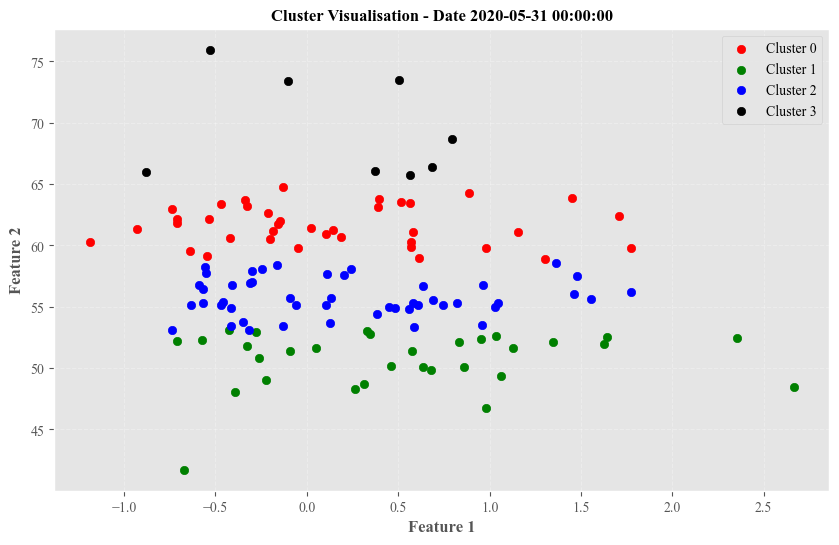

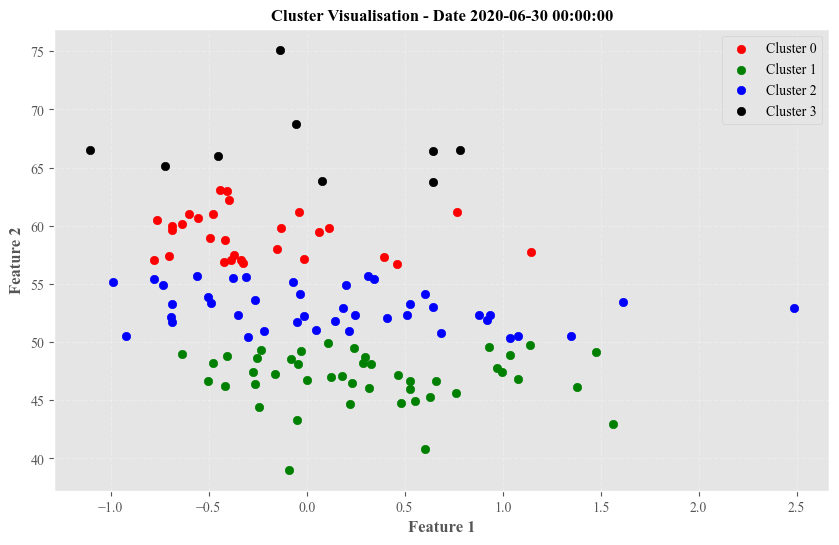

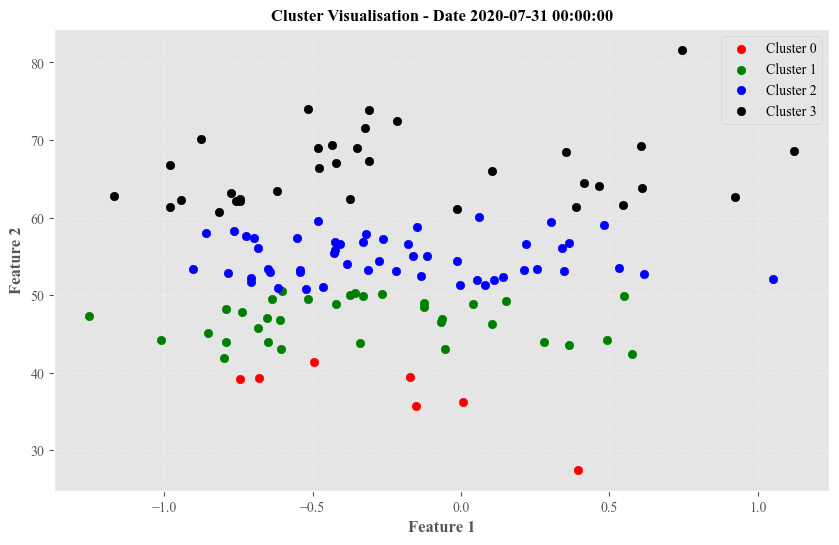

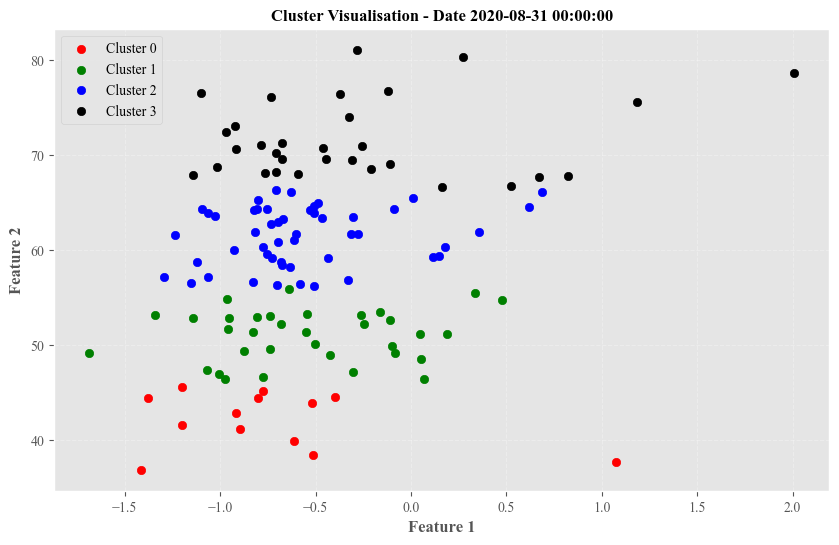

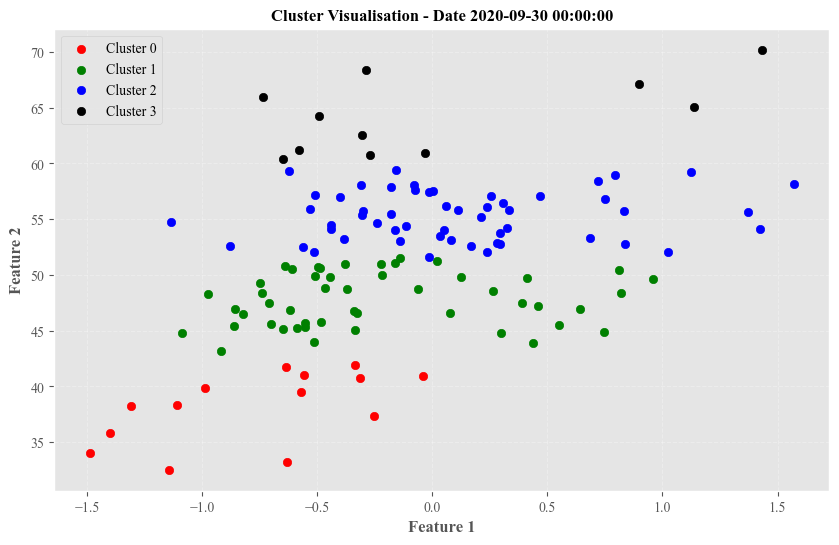

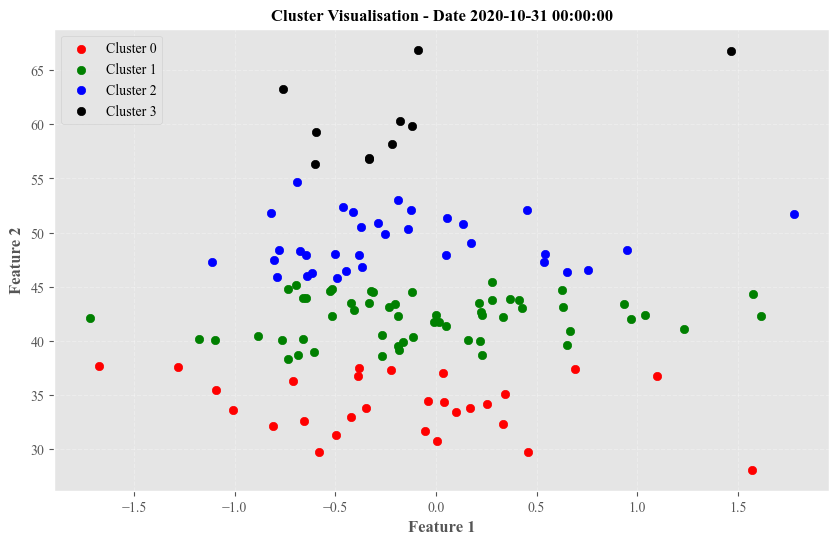

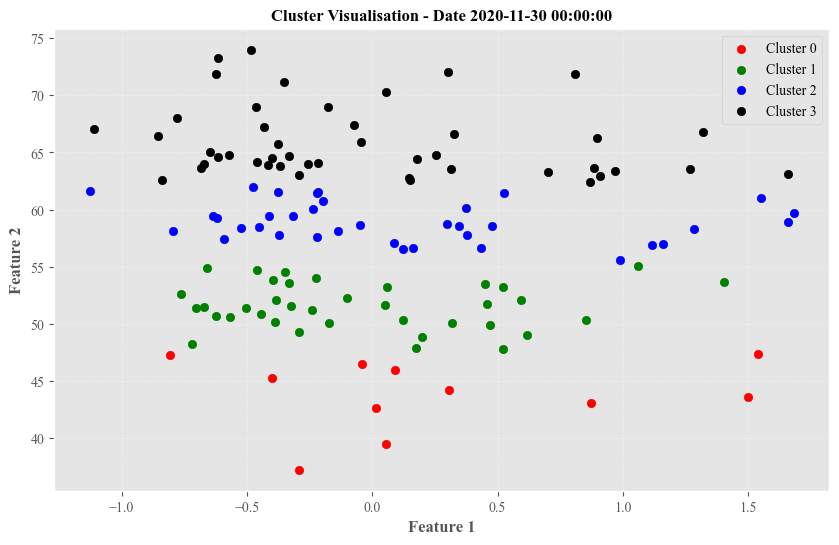

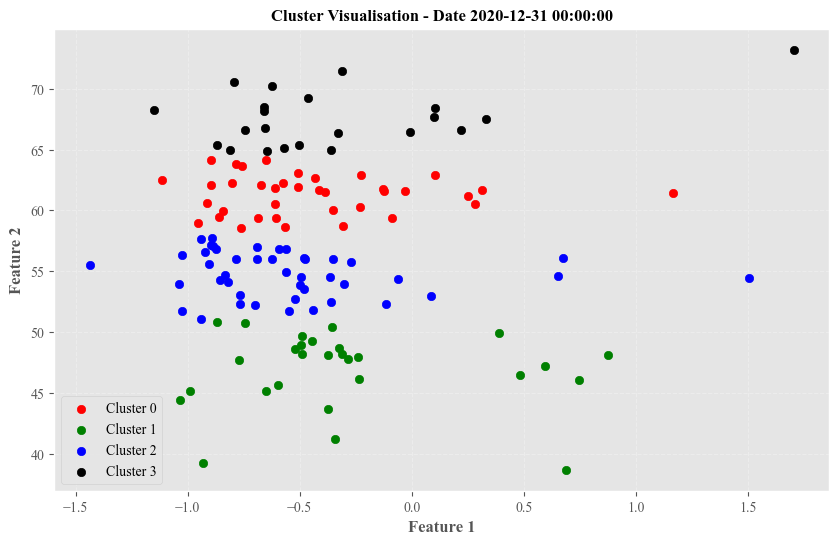

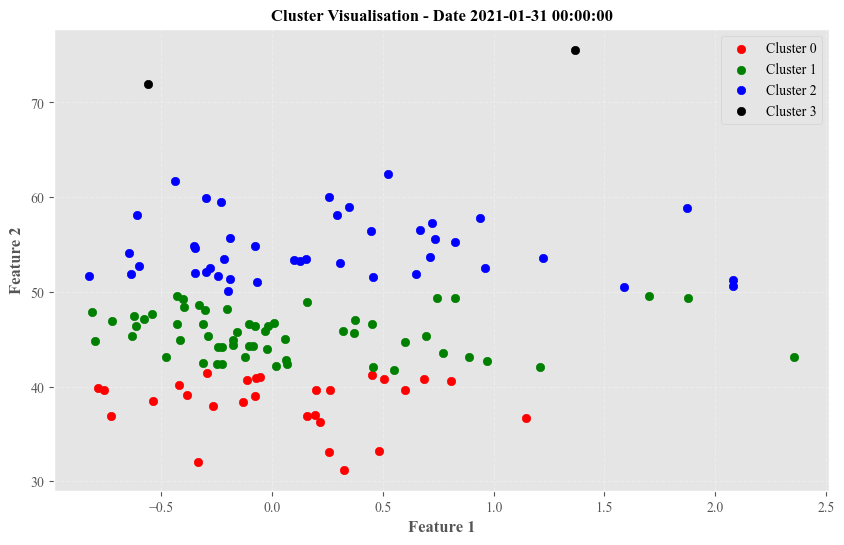

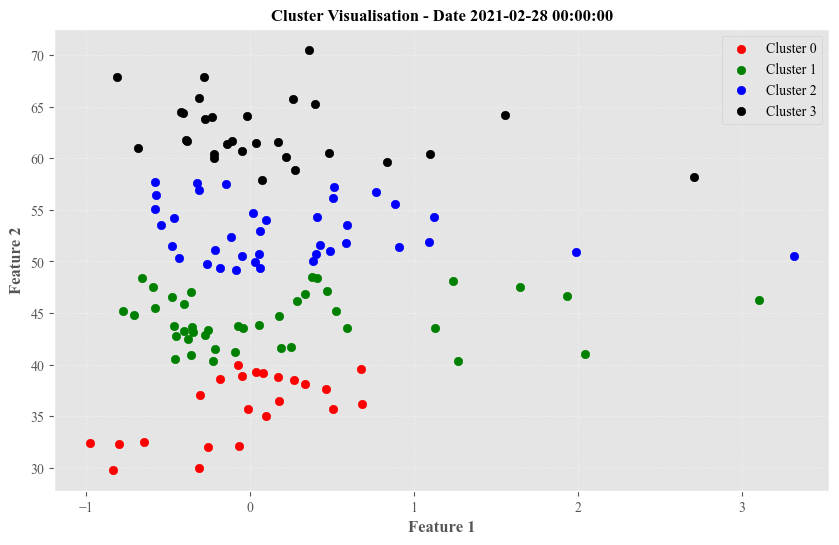

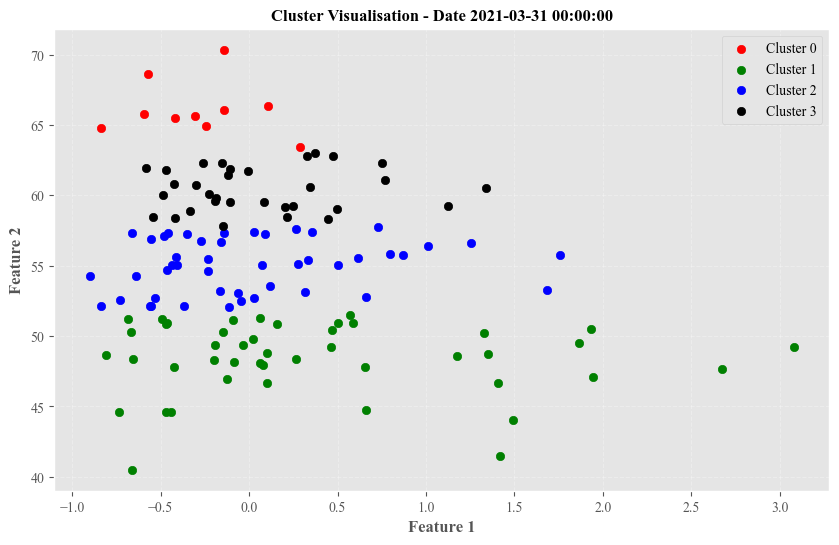

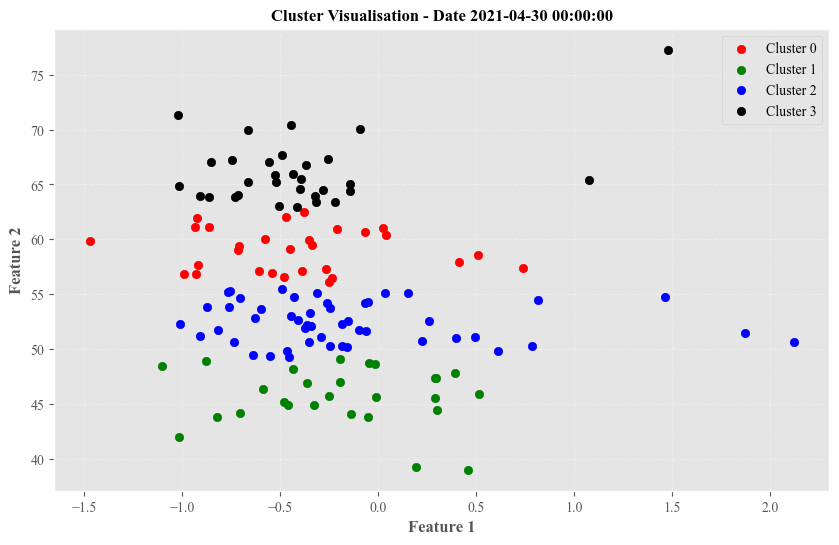

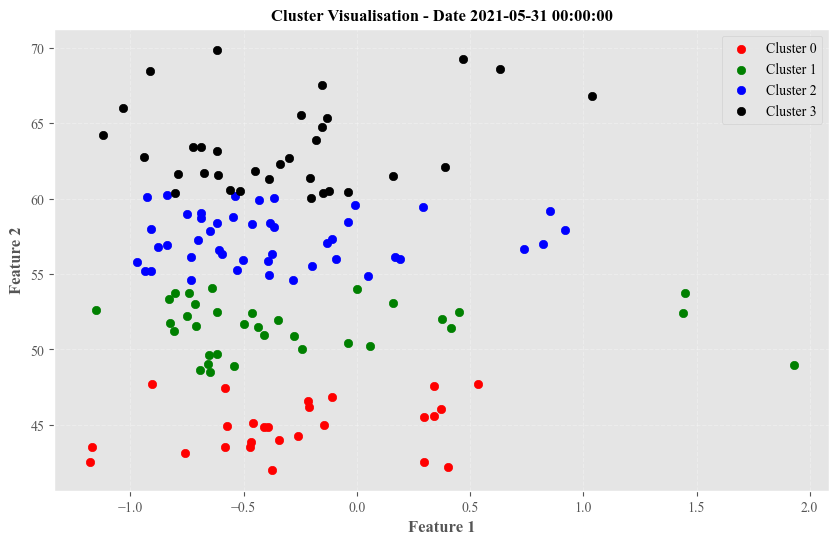

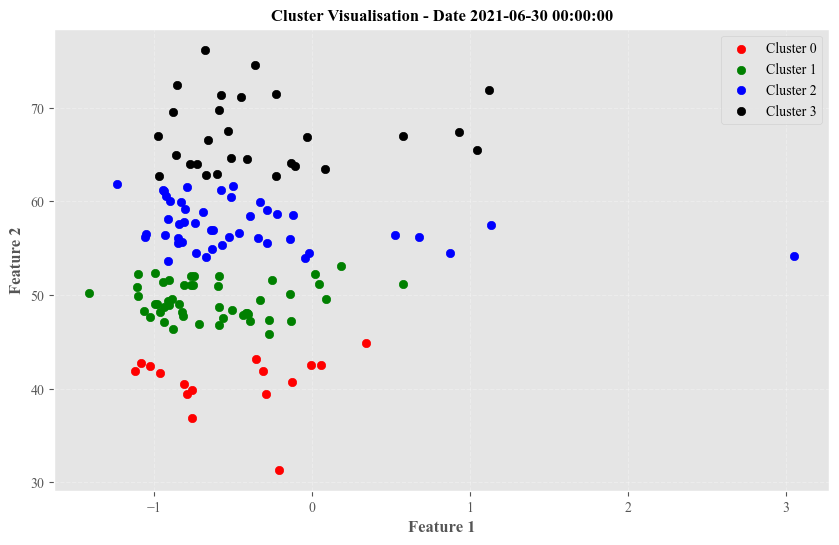

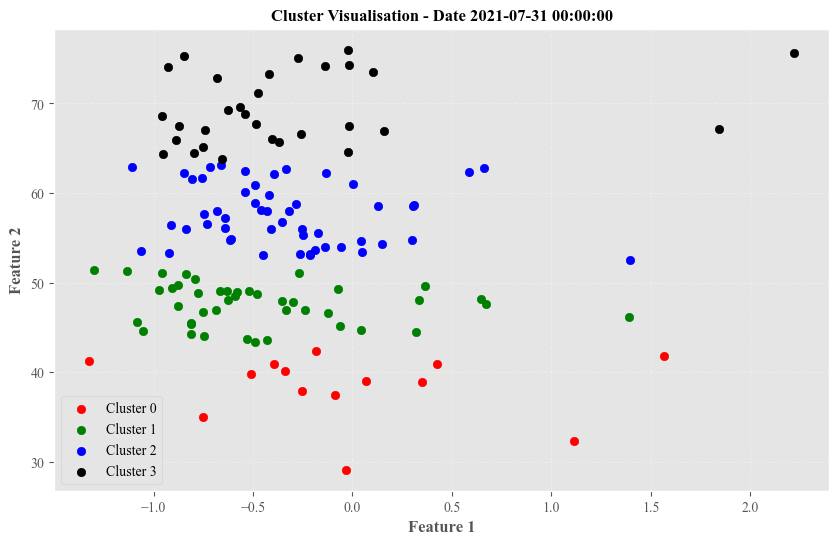

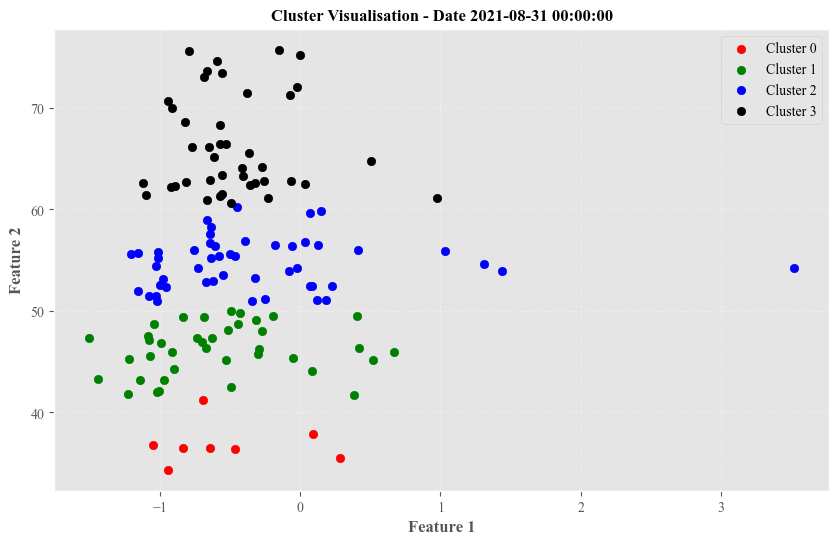

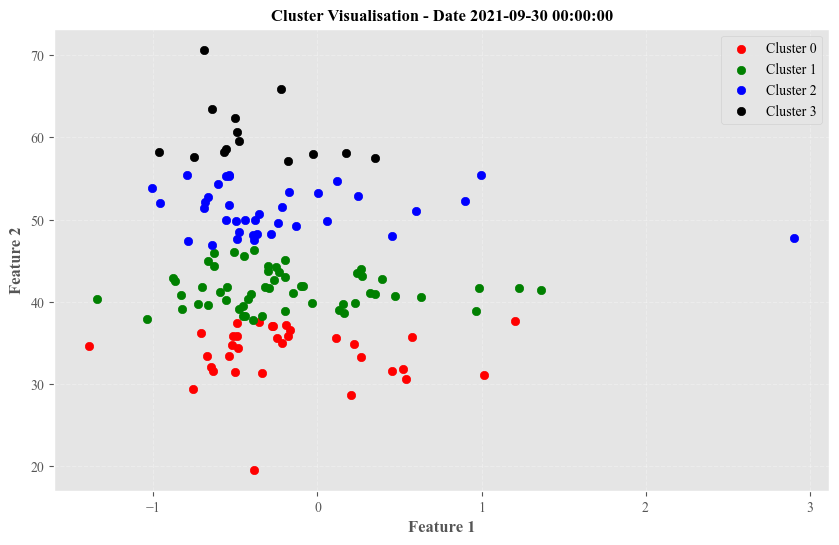

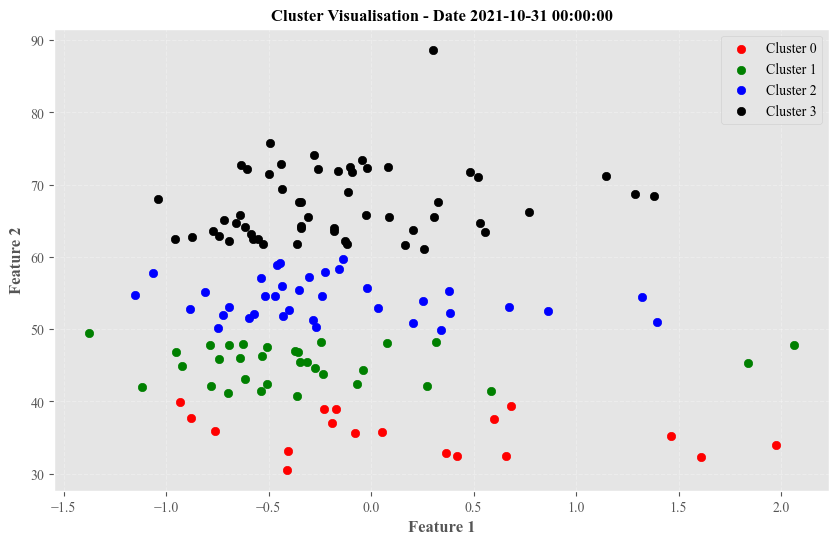

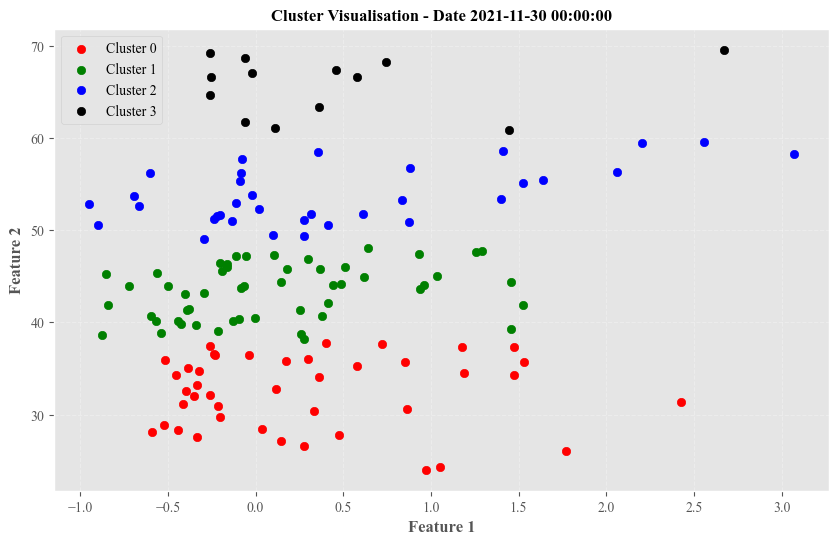

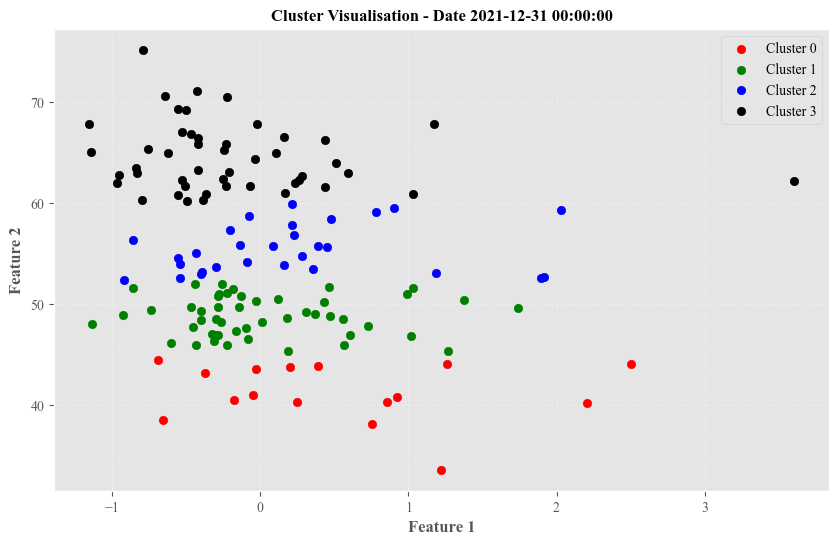

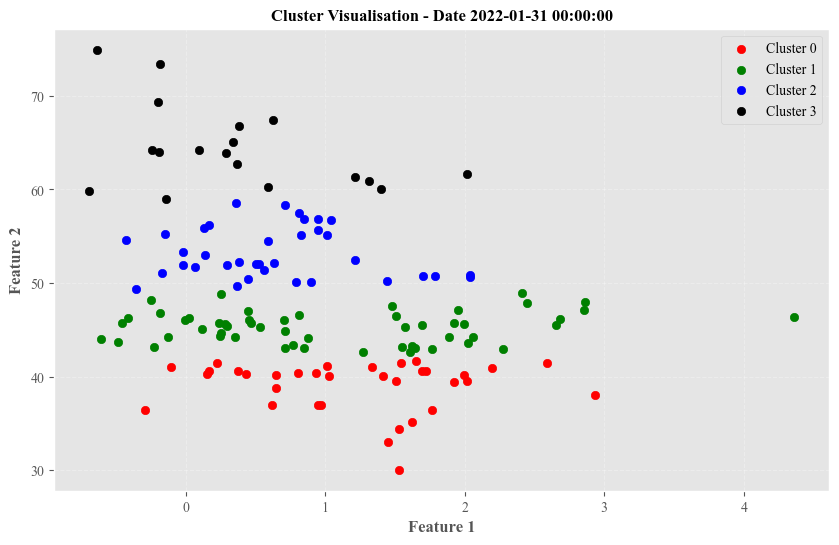

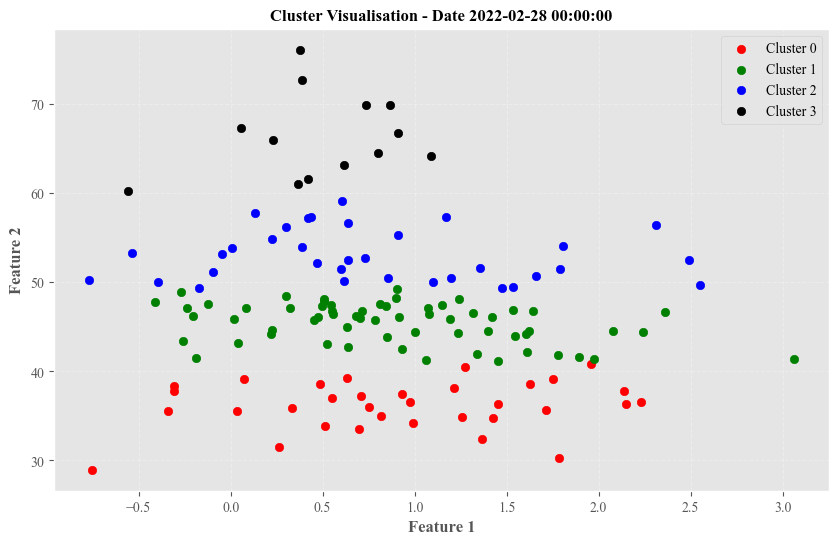

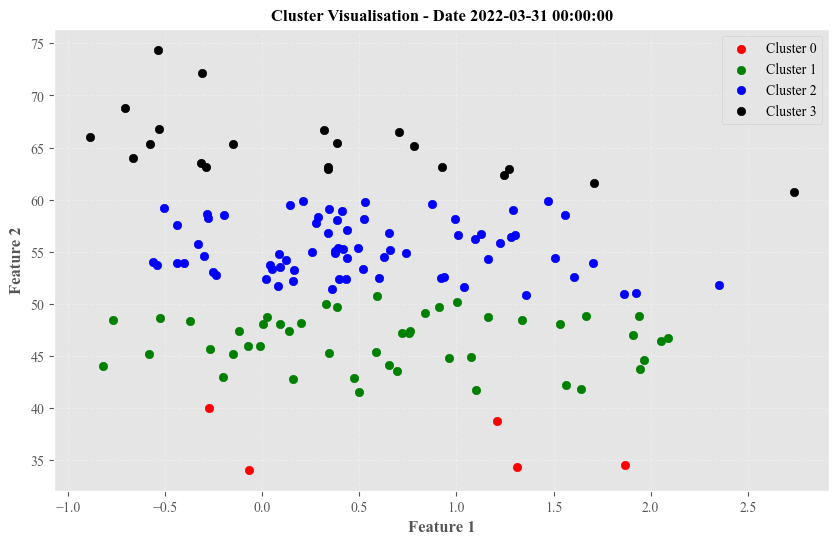

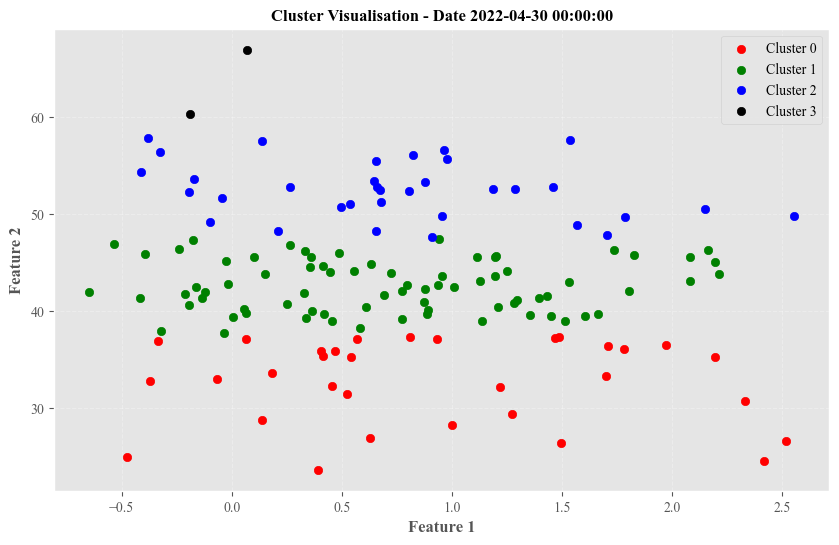

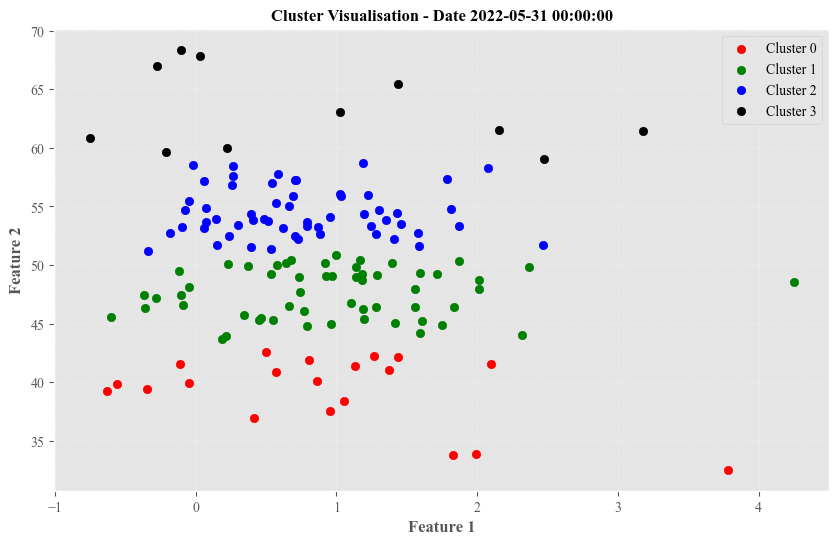

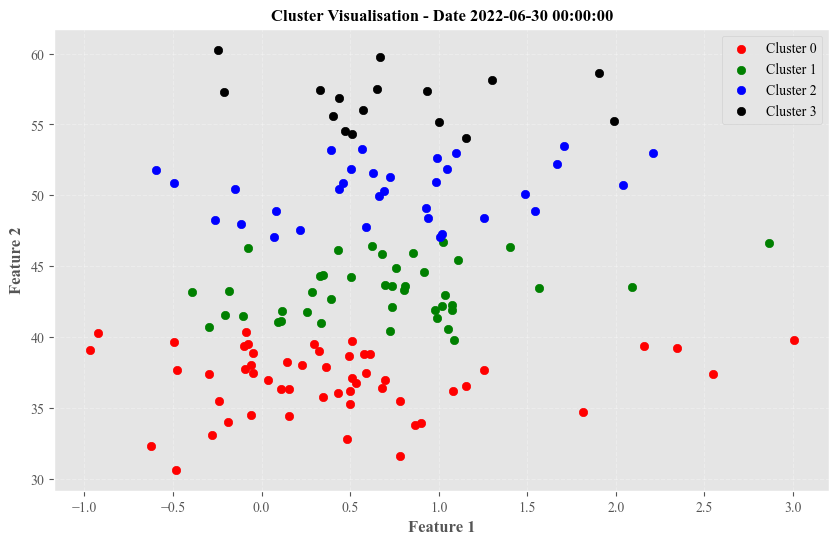

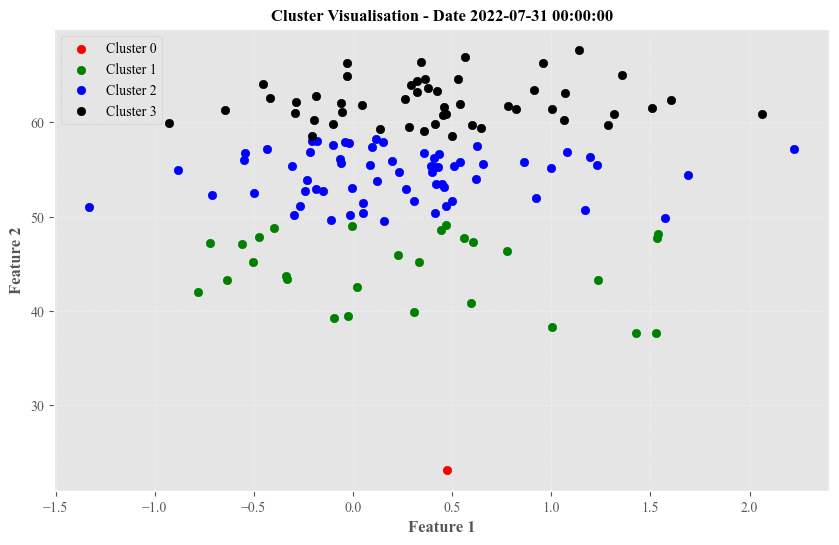

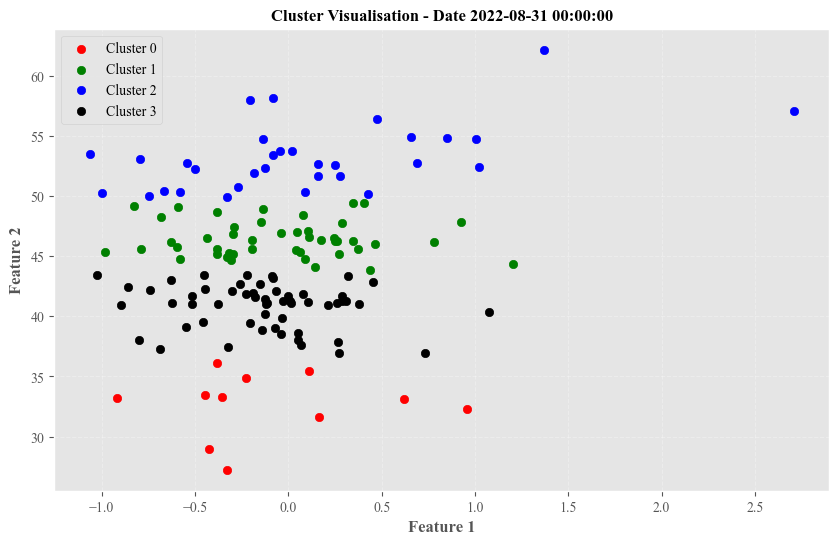

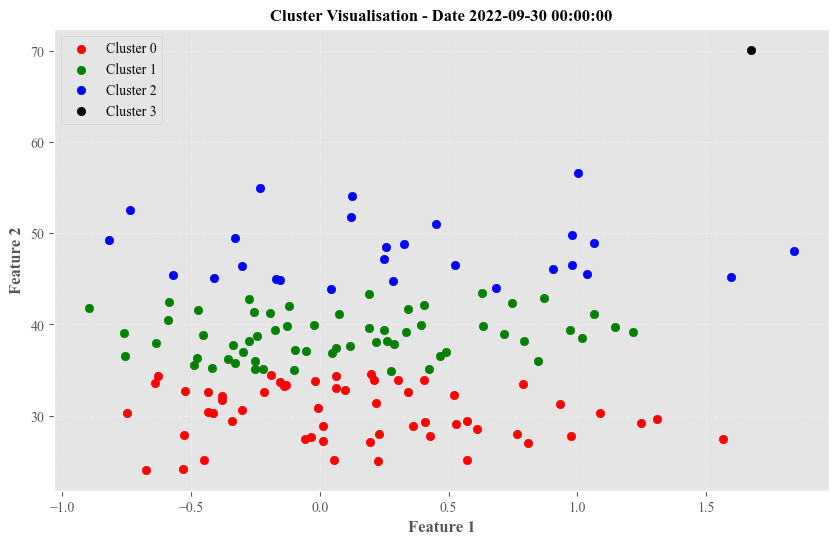

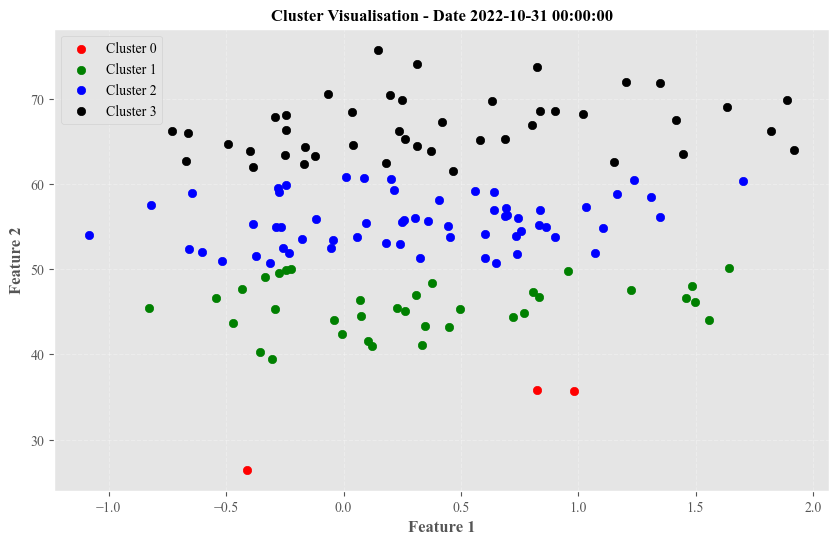

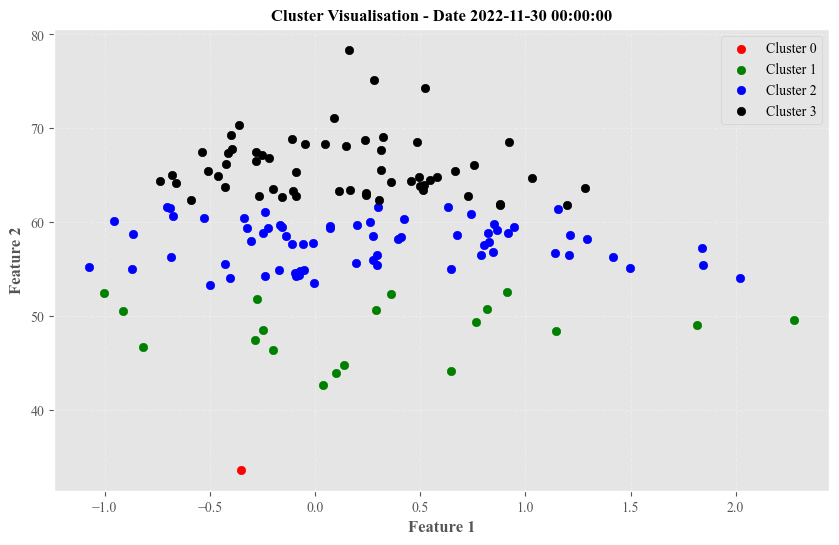

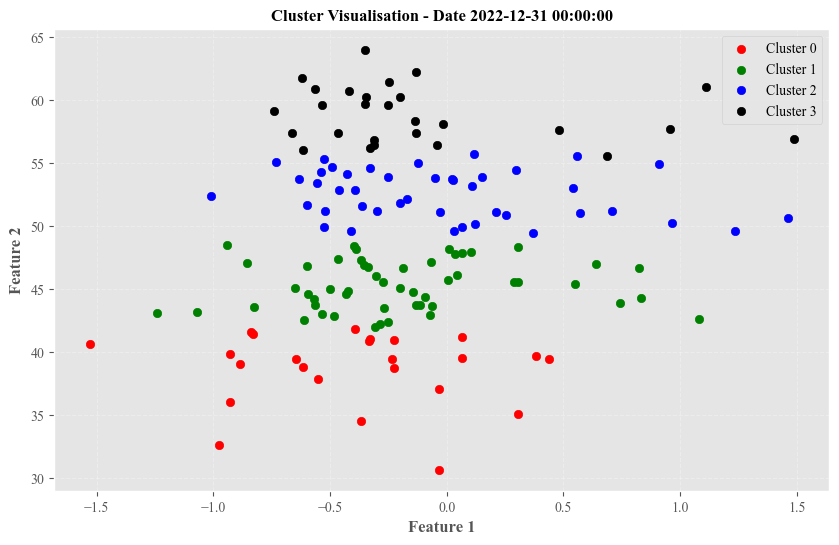

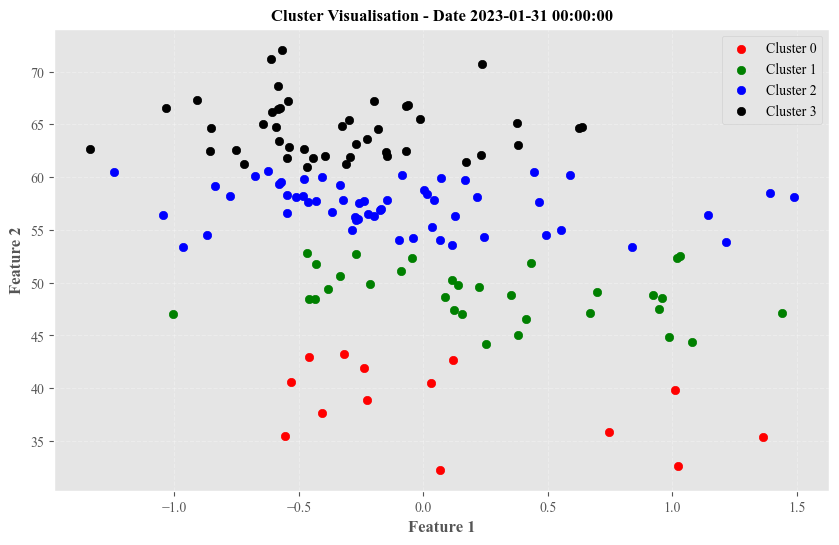

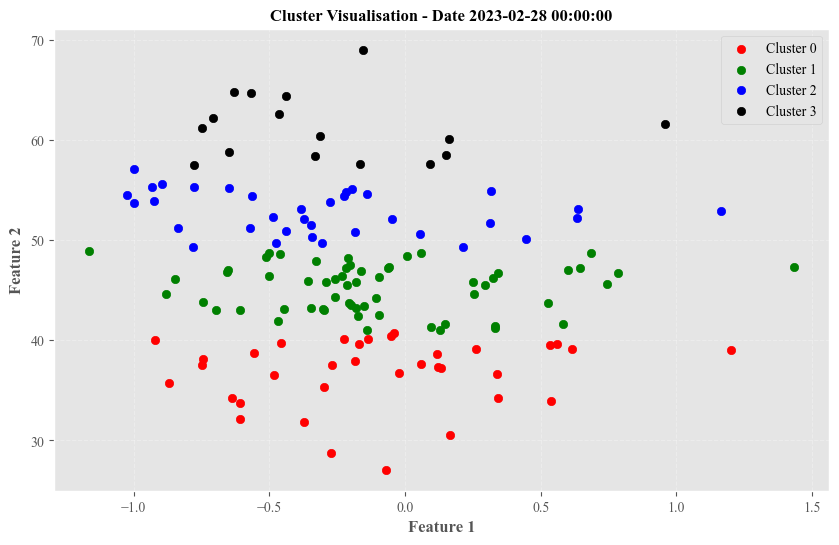

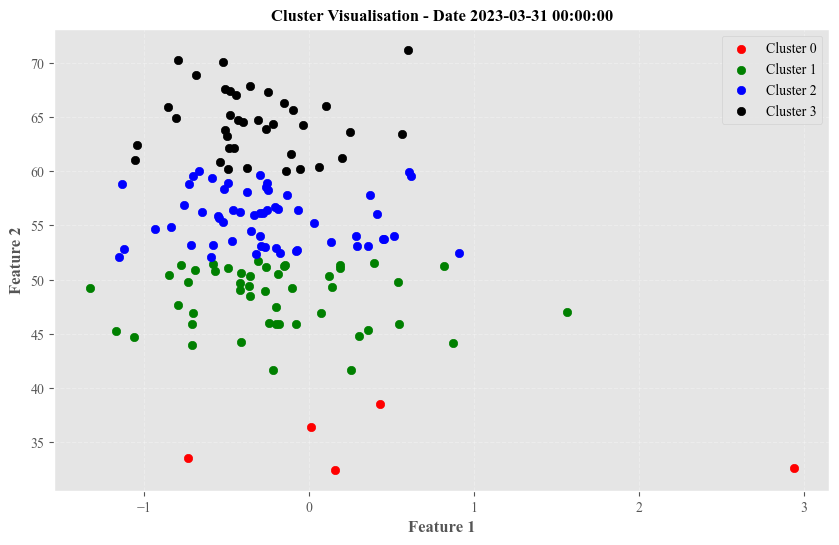

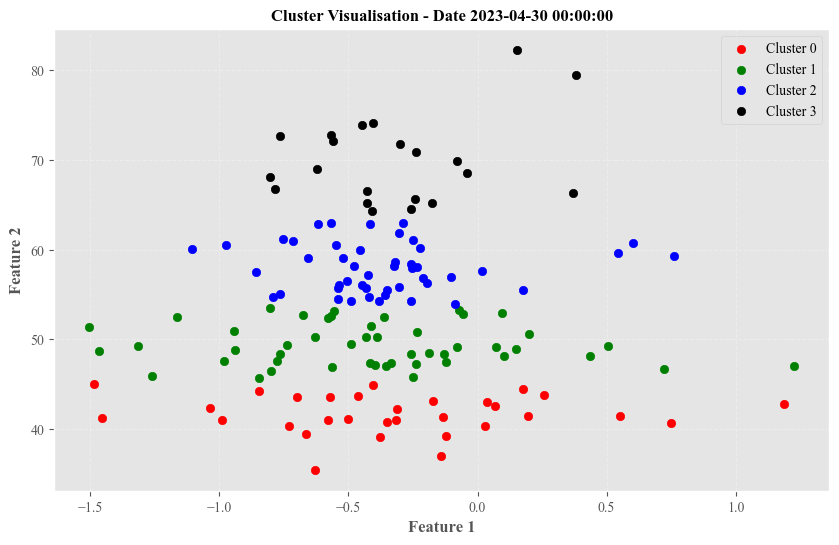

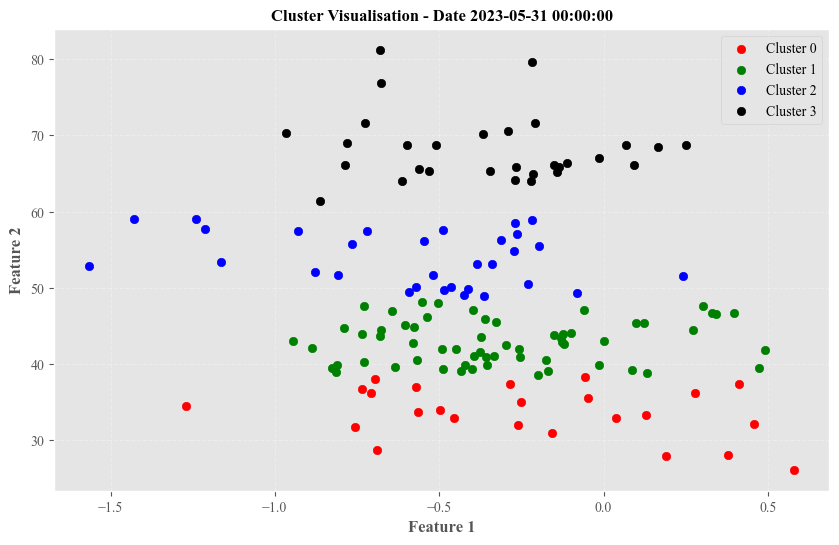

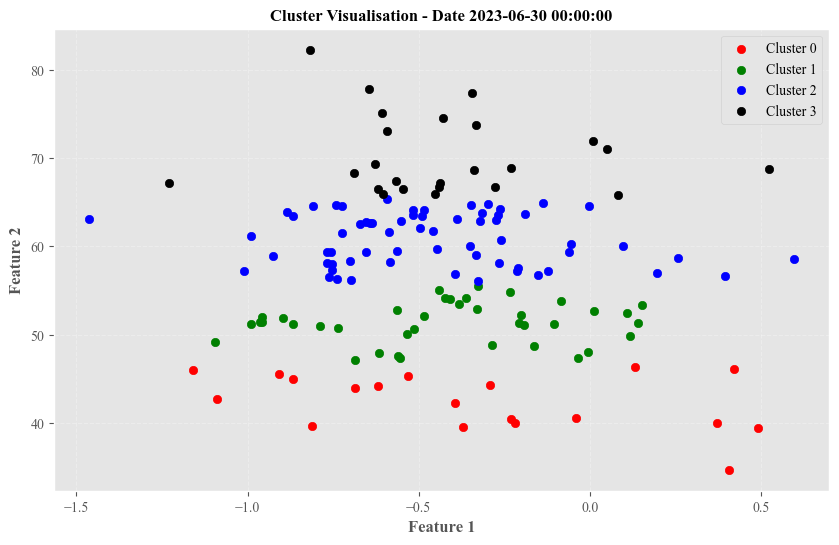

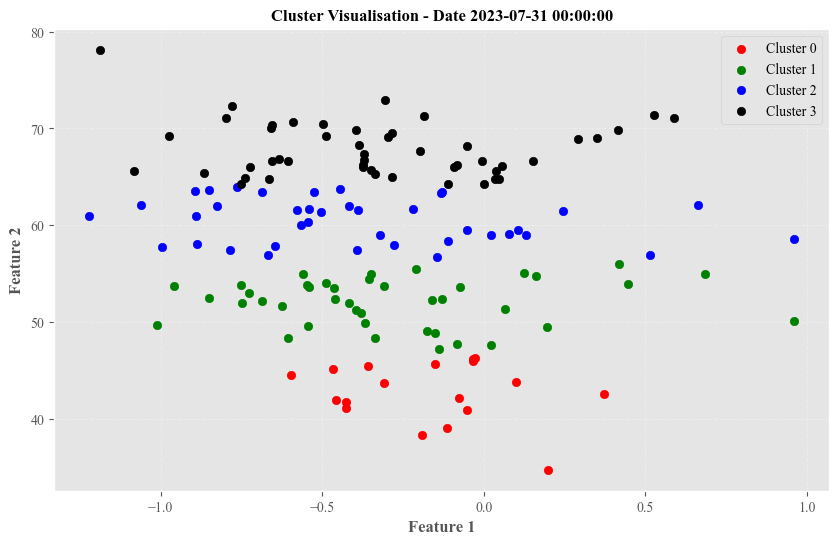

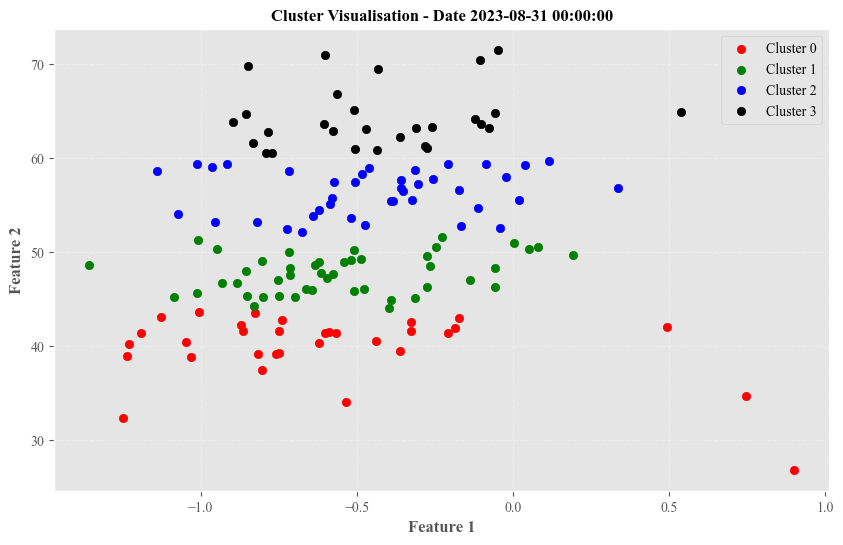

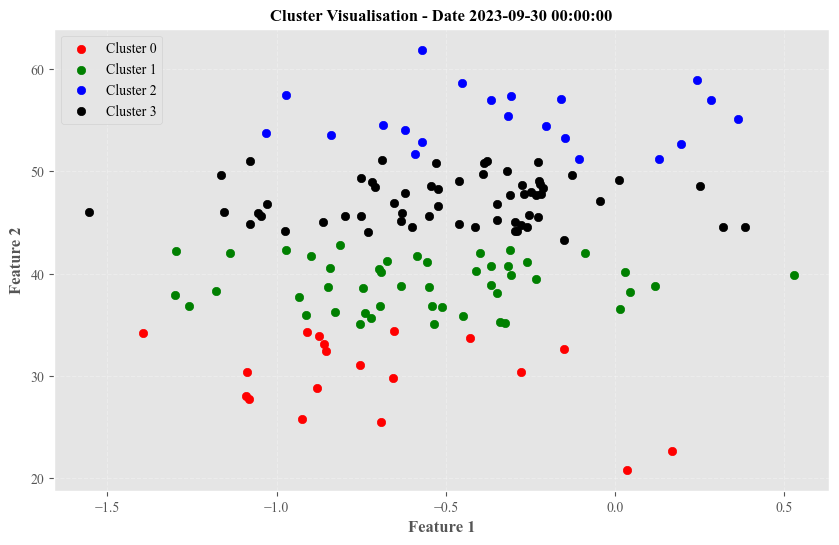

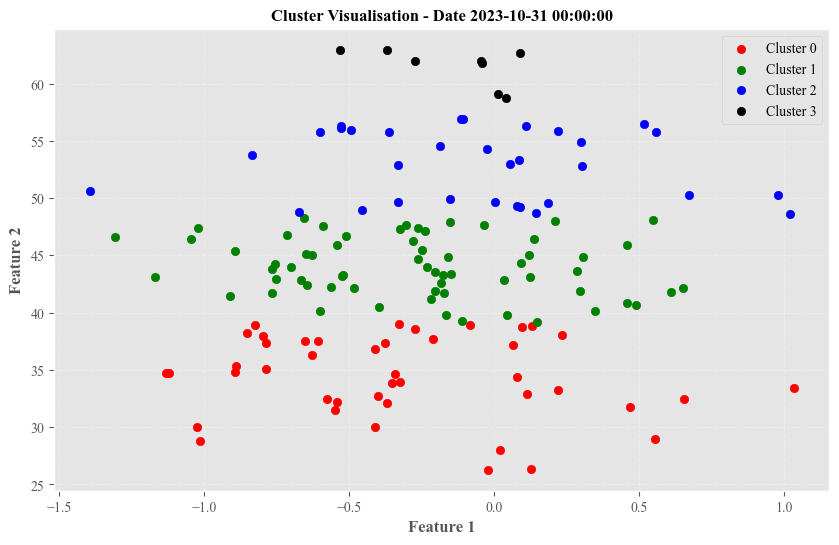

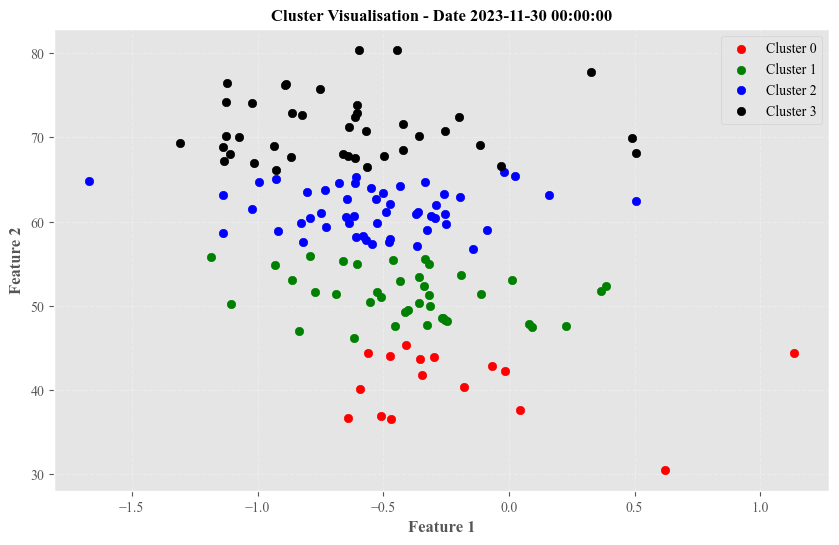

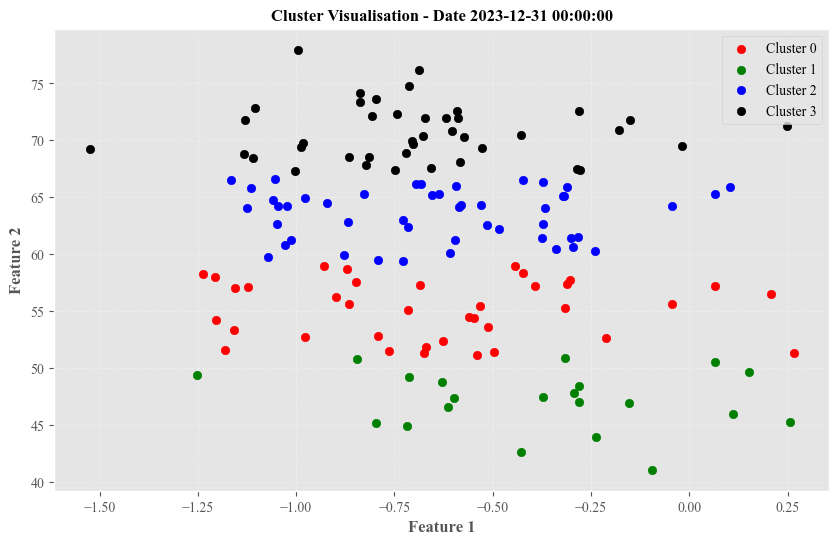

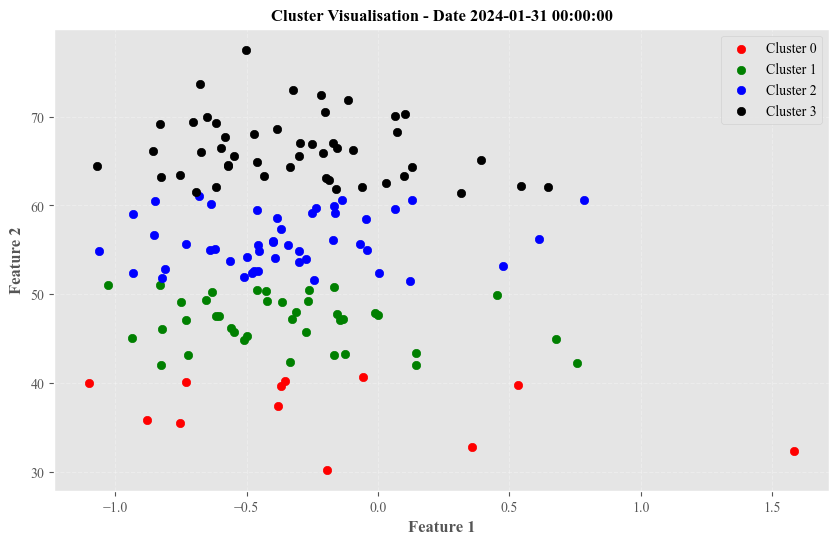

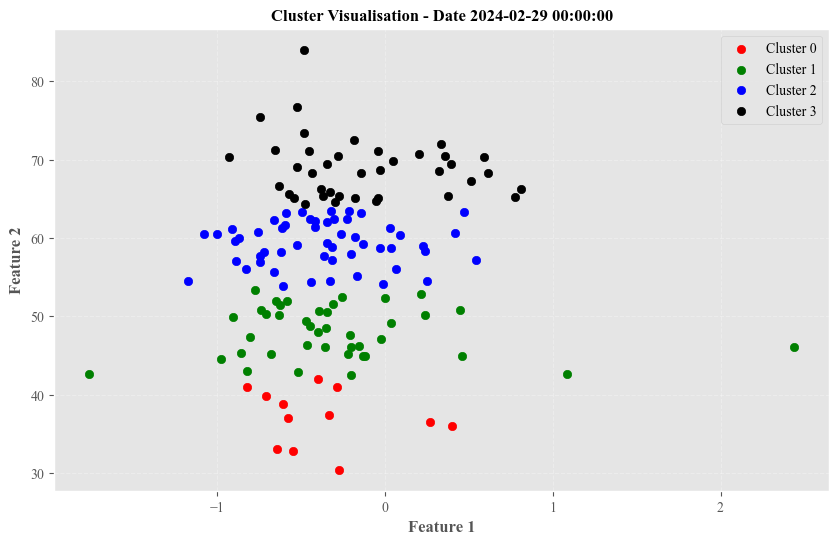

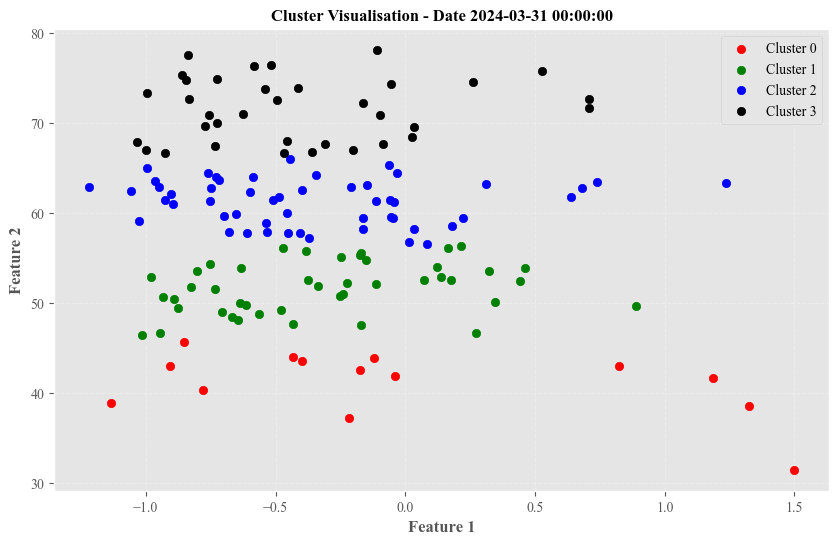

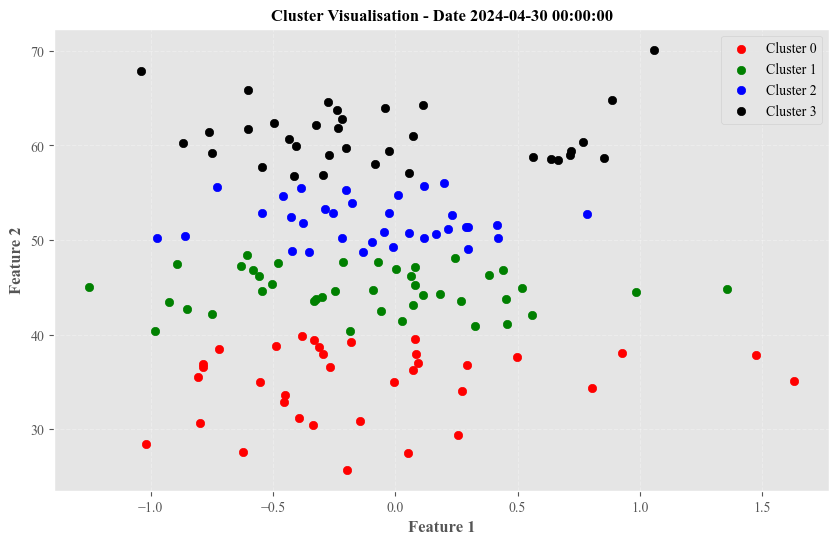

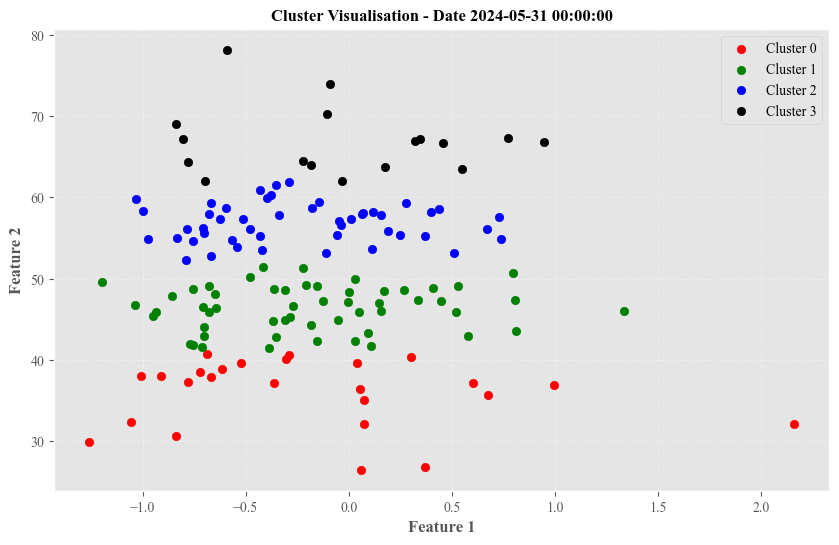

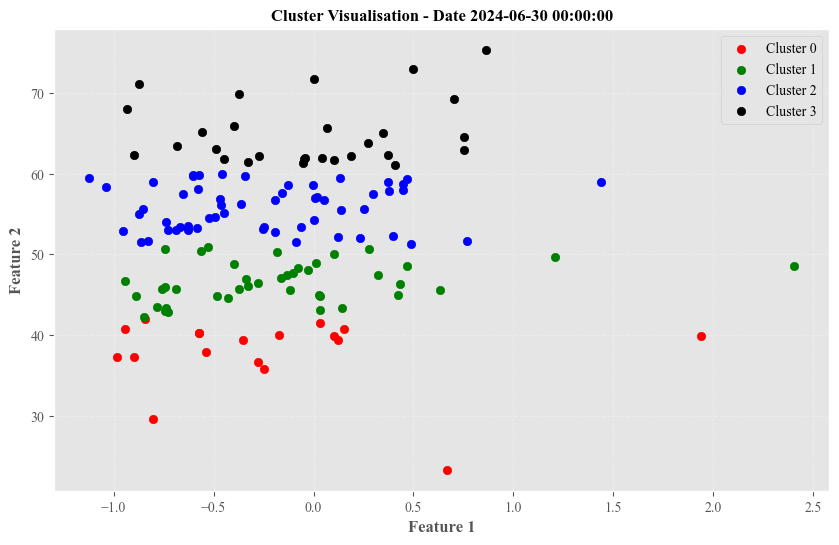

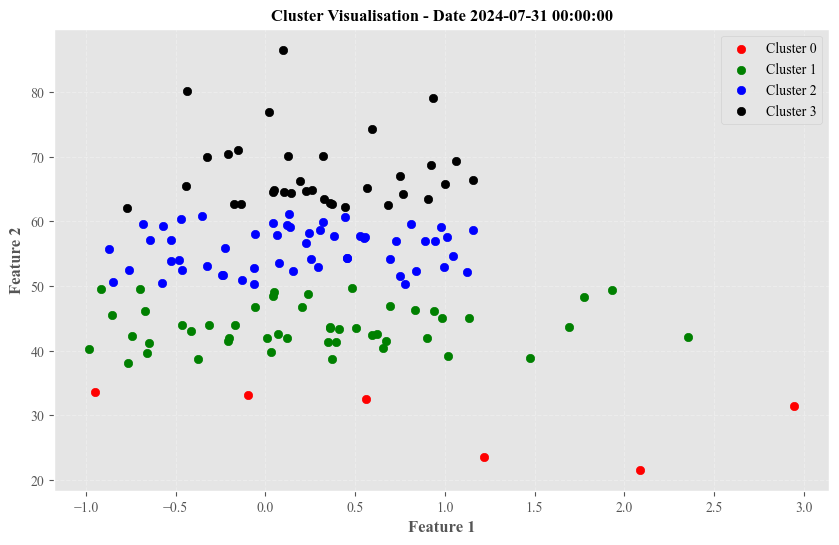

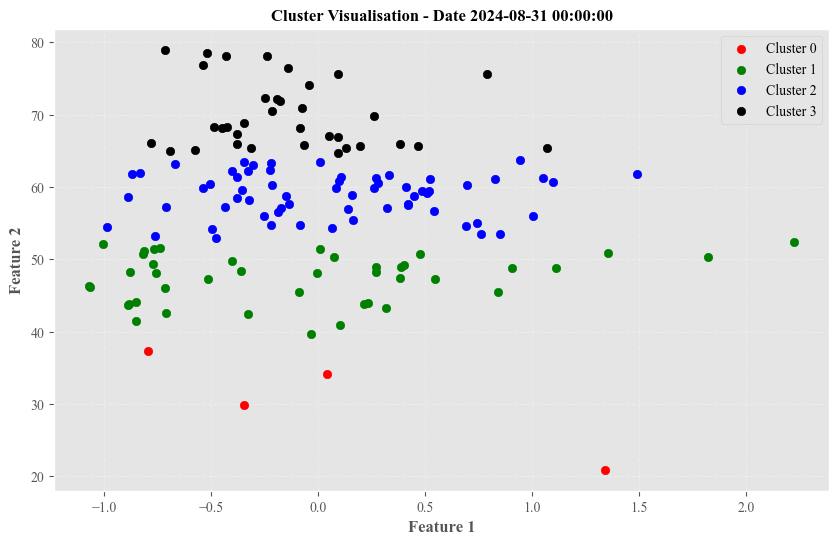

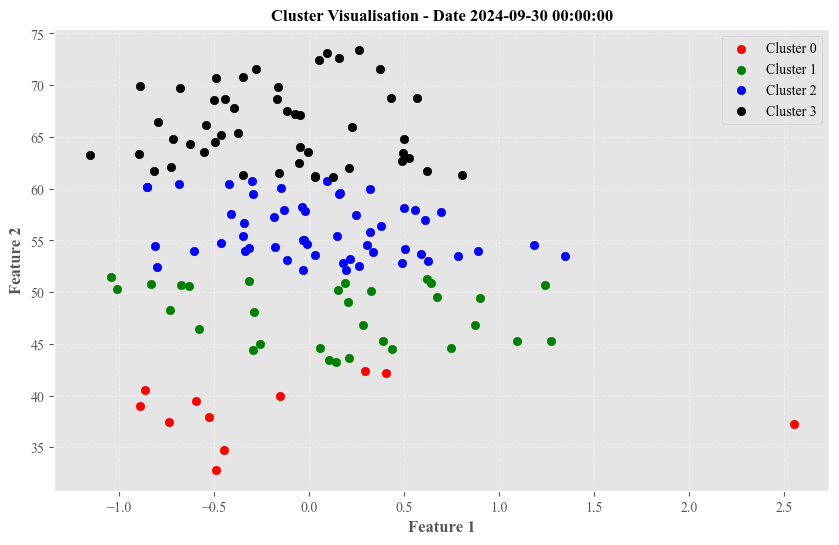

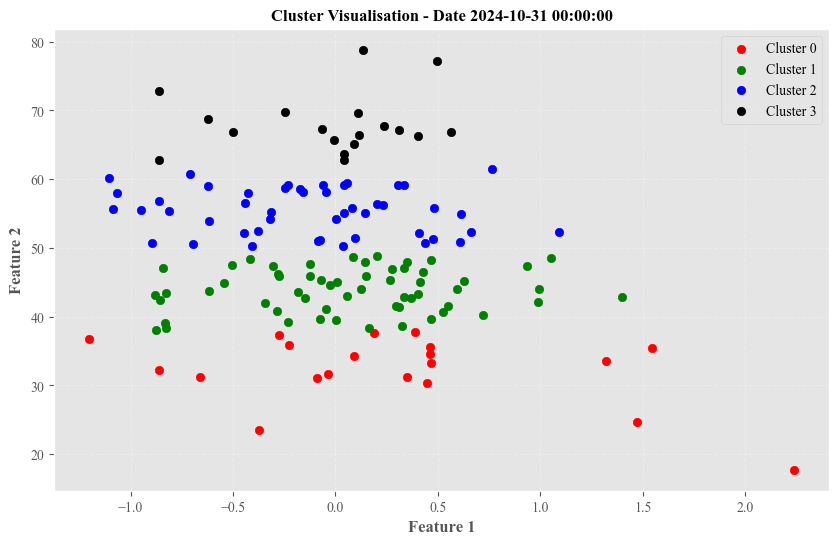

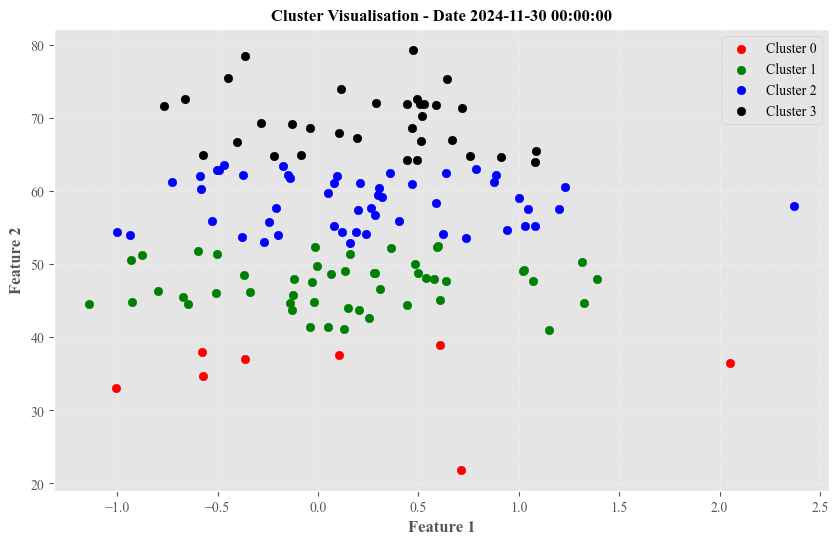

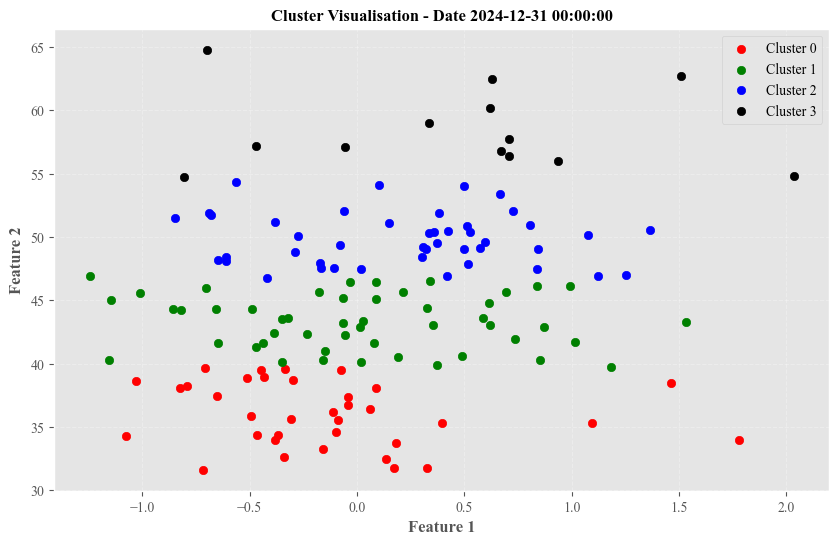

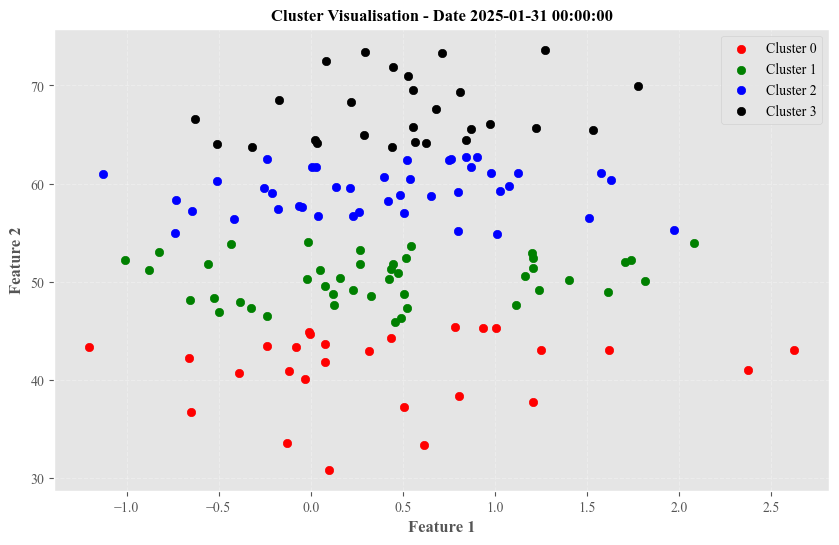

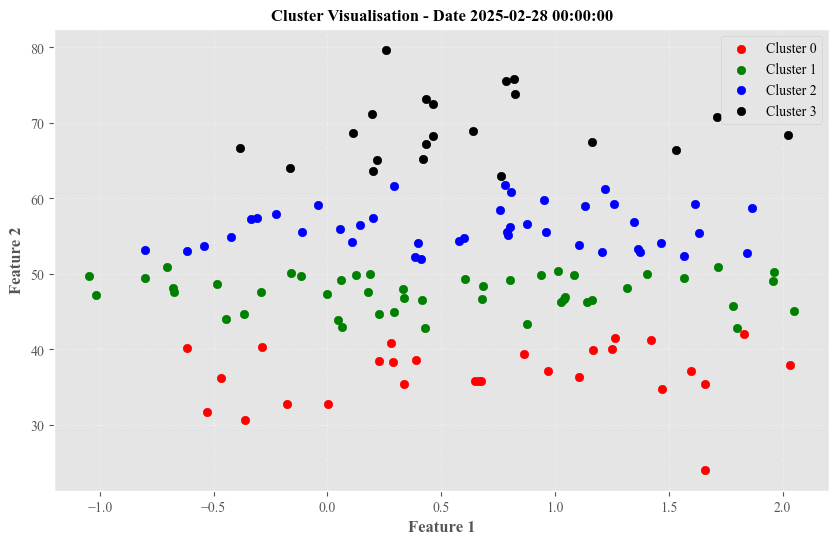

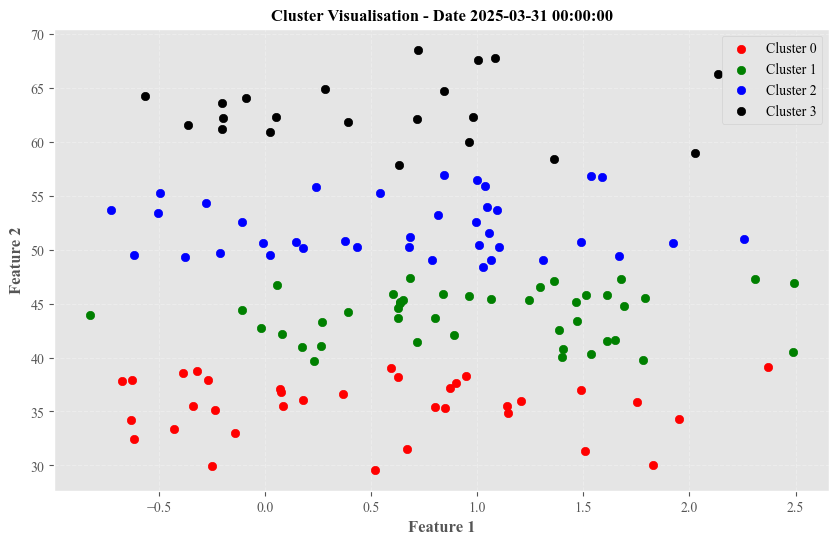

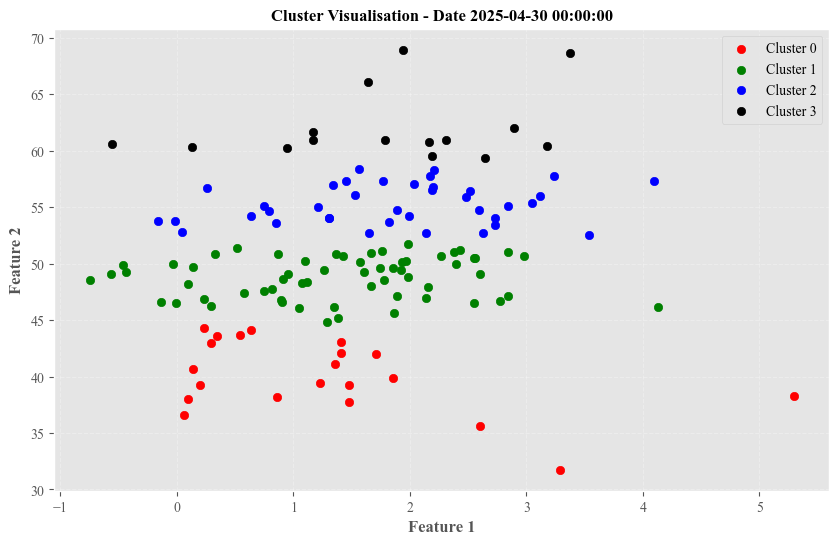

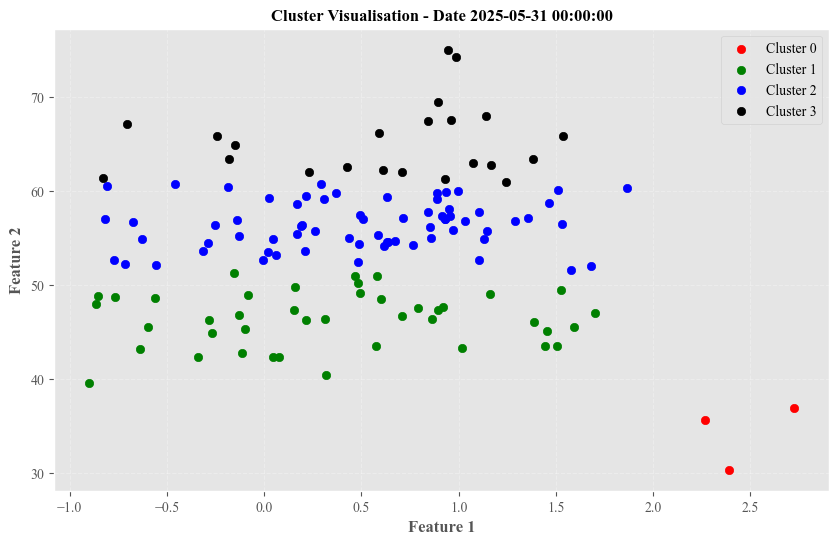

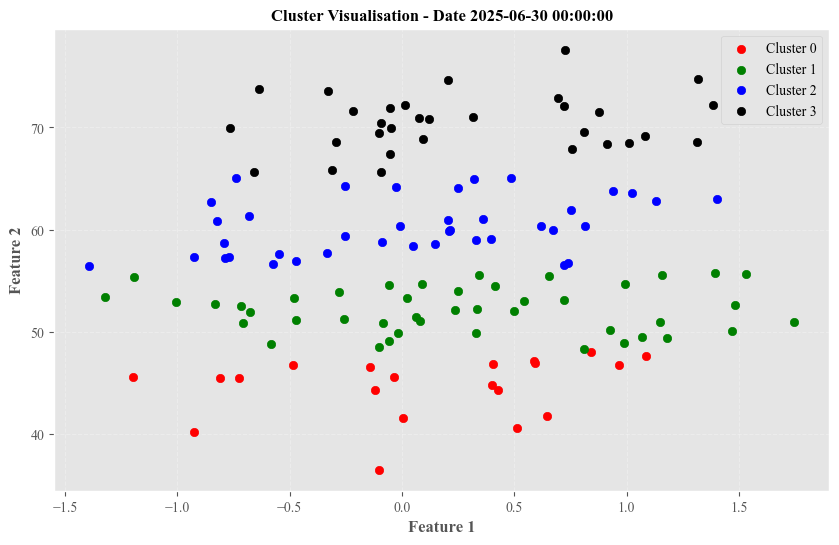

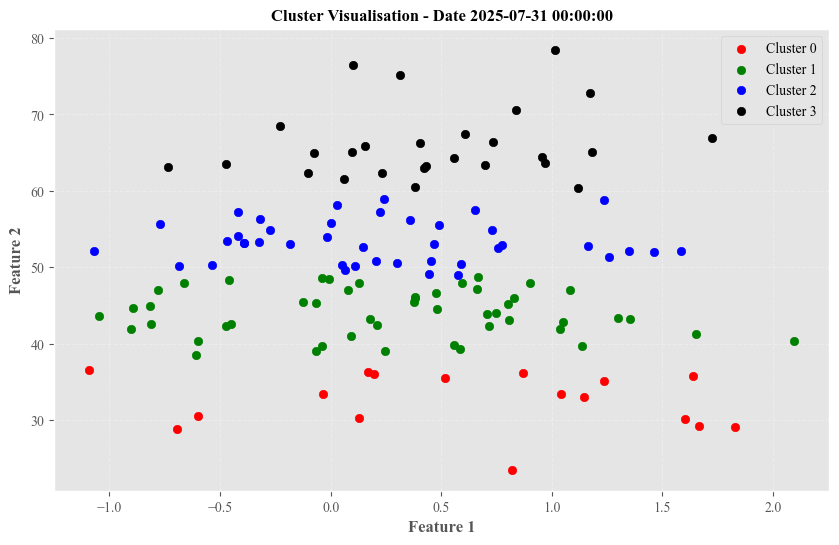

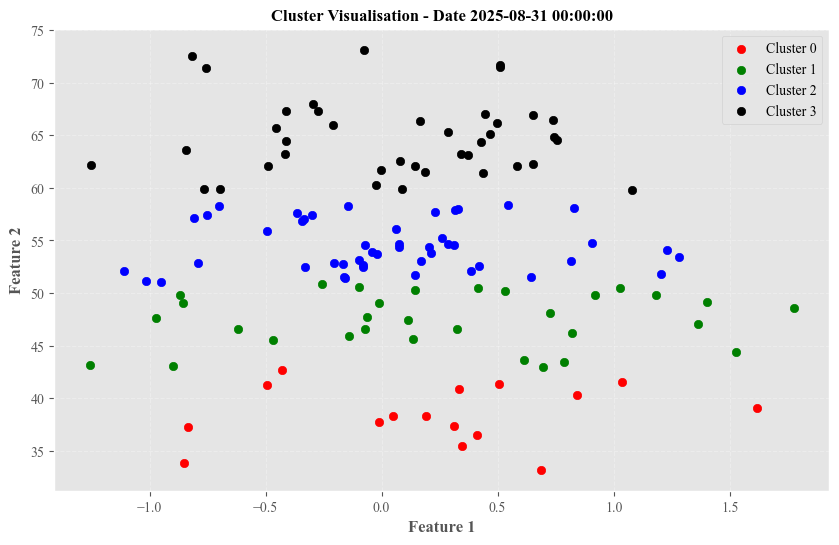

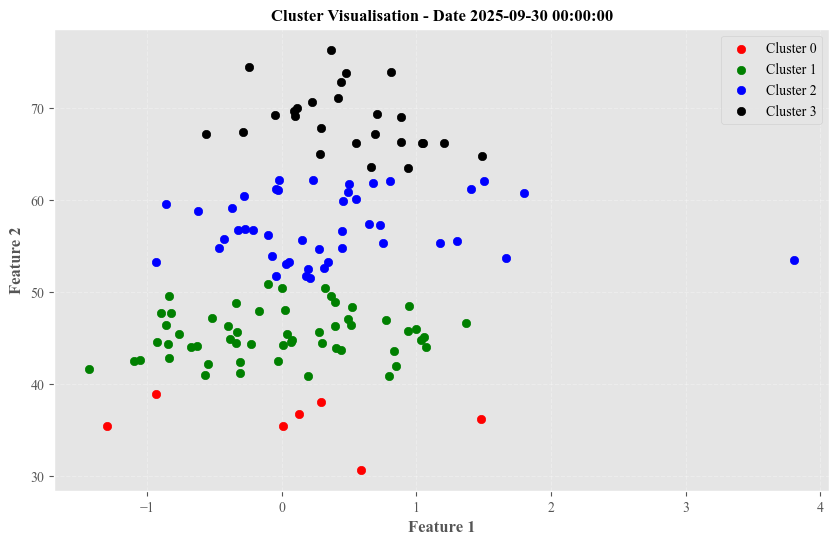

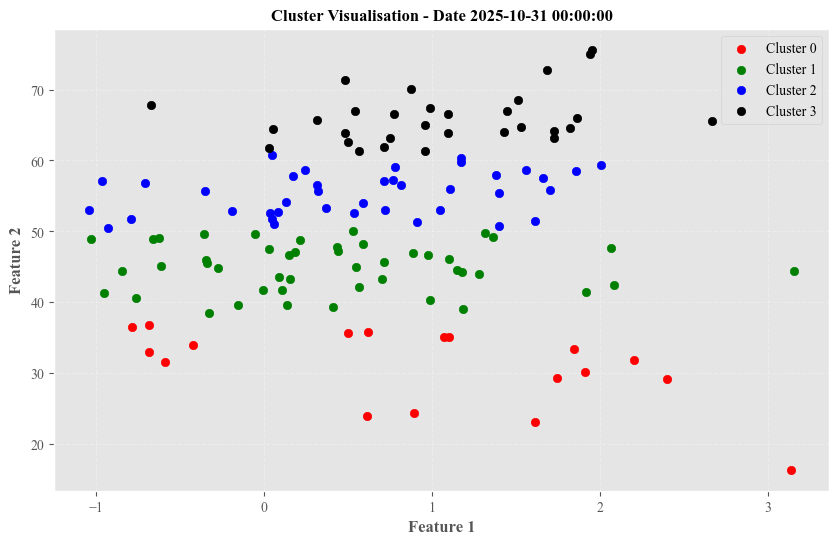

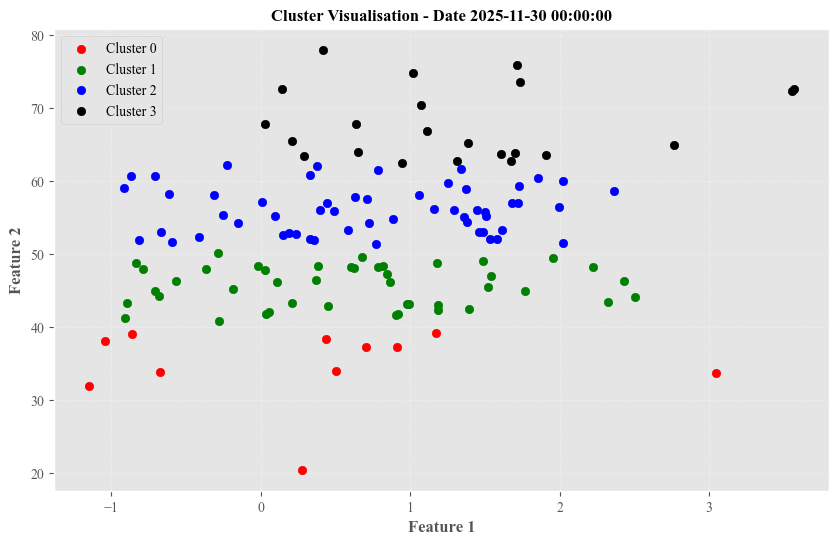

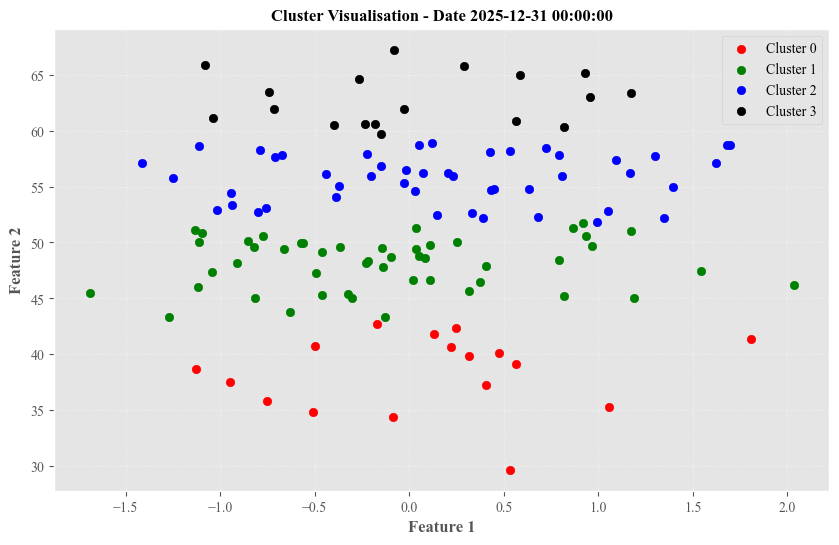

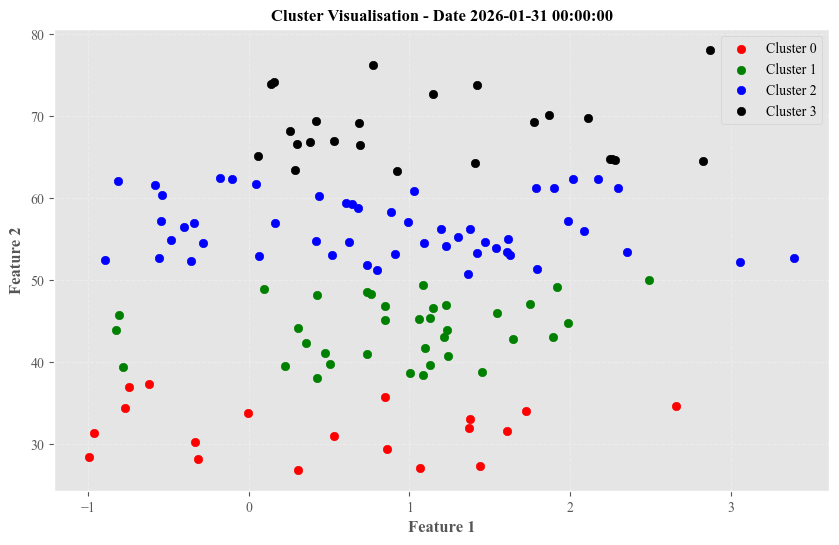

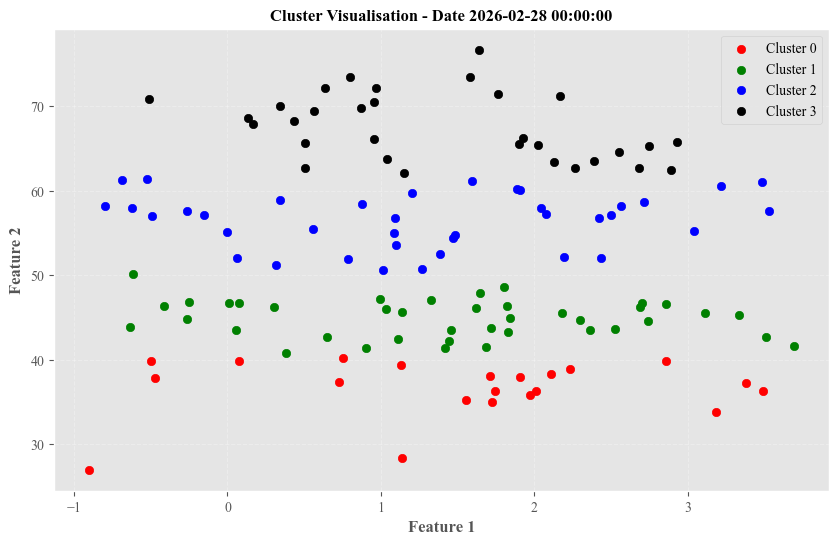

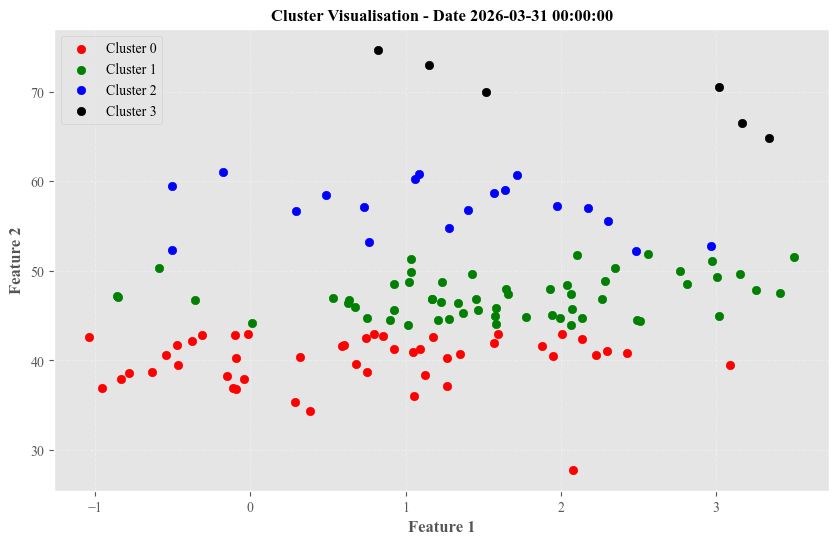

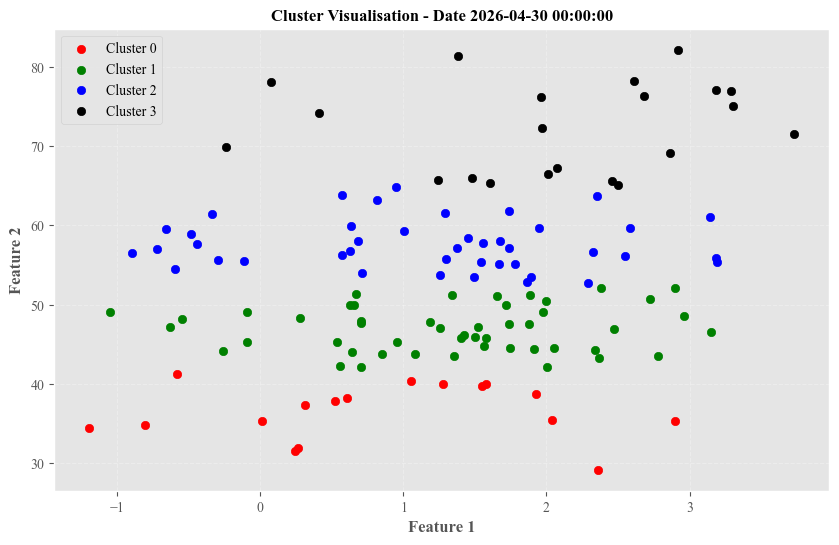

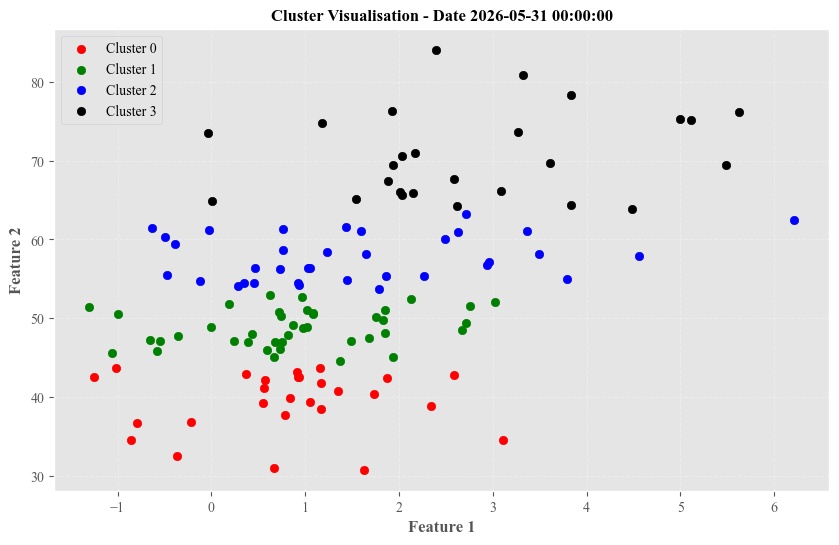

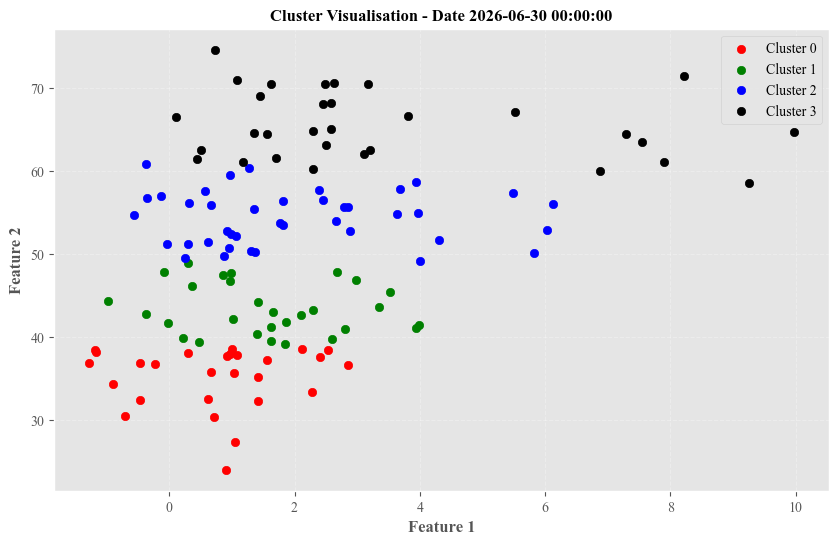

In [26]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'
plt.style.use('ggplot')

def plot_clusters(data, ax, date_label):

    cluster_0 = data[data['cluster'] == 0]
    cluster_1 = data[data['cluster'] == 1]
    cluster_2 = data[data['cluster'] == 2]
    cluster_3 = data[data['cluster'] == 3]

    ax.scatter(cluster_0.iloc[:, 5], cluster_0.iloc[:, 1], color = 'red', label = 'Cluster 0')
    ax.scatter(cluster_1.iloc[:, 5], cluster_1.iloc[:, 1], color = 'green', label = 'Cluster 1')
    ax.scatter(cluster_2.iloc[:, 5], cluster_2.iloc[:, 1], color = 'blue', label = 'Cluster 2')
    ax.scatter(cluster_3.iloc[:, 5], cluster_3.iloc[:, 1], color = 'black', label = 'Cluster 3')

    ax.set_title(f"Cluster Visualisation - Date {date_label}", 
                 fontweight = 'bold', fontsize = 12)

    ax.set_xlabel("Feature 1", fontweight = 'bold')
    ax.set_ylabel("Feature 2", fontweight = 'bold')

    ax.grid(True, linestyle = '--', alpha = 0.3)
    ax.legend()

dates = data.index.get_level_values('date').unique().tolist()

for i in dates:
    g = data.xs(i, level = 0)
    fig, ax = plt.subplots(figsize = (10, 6))
    plot_clusters(g, ax, i)
    plt.show()

In [27]:
import sys
!{sys.executable} -m pip install pyportfolioopt

In [28]:
# Portfolio Optimisation

filtered_df = data[data['cluster'] == 3].copy()
filtered_df = filtered_df.reset_index(level = 1)
filtered_df.index = filtered_df.index + pd.DateOffset(1)
filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])
dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level = 0).index.tolist()

fixed_dates

{'2020-06-01': ['ADSK', 'EBAY', 'LOW', 'LULU', 'PANW', 'PYPL', 'SPGI', 'WDAY'],
 '2020-07-01': ['AAPL',
  'ADBE',
  'ADSK',
  'AMZN',
  'EA',
  'EBAY',
  'PYPL',
  'TSLA',
  'XYZ'],
 '2020-08-01': ['AAPL',
  'ABT',
  'ACN',
  'AMD',
  'AMZN',
  'AZO',
  'BDX',
  'BRK-B',
  'CHTR',
  'COST',
  'DE',
  'DHR',
  'EA',
  'FDX',
  'FIS',
  'HD',
  'ISRG',
  'LIN',
  'LOW',
  'LRCX',
  'MDLZ',
  'META',
  'NEE',
  'NVDA',
  'PANW',
  'PFE',
  'PG',
  'PYPL',
  'QCOM',
  'SHW',
  'TGT',
  'TMO',
  'UPS',
  'XYZ'],
 '2020-09-01': ['AAPL',
  'ABT',
  'ACN',
  'AMD',
  'AMZN',
  'AVGO',
  'BRK-B',
  'CHTR',
  'CMG',
  'COST',
  'CRM',
  'DE',
  'FDX',
  'INTU',
  'ISRG',
  'LOW',
  'LULU',
  'MA',
  'MCD',
  'MDLZ',
  'MDT',
  'META',
  'NKE',
  'NVDA',
  'PG',
  'QCOM',
  'TGT',
  'TSLA',
  'UPS',
  'WDAY',
  'XYZ'],
 '2020-10-01': ['COST',
  'DE',
  'DHR',
  'FDX',
  'MCD',
  'NKE',
  'NVDA',
  'TGT',
  'TMO',
  'TTD',
  'UPS'],
 '2020-11-01': ['ADP',
  'ALGN',
  'DHR',
  'F',
  'GE',
  'GM',


In [29]:
# Portfolio Optimisation - Mean-Variance Optimisation

from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimise_weights(prices, lower_bound = 0):

    returns = expected_returns.mean_historical_return(prices = prices,
                                                      frequency = 252)

    cov = risk_models.sample_cov(prices = prices,
                                 frequency = 252)

    ef = EfficientFrontier(expected_returns = returns,
                           cov_matrix = cov,
                           weight_bounds = (lower_bound, 0.1),
                           solver = 'SCS')

    weights = ef.max_sharpe()

    return ef.clean_weights()

In [30]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers = stocks, 
                     start = data.index.get_level_values('date').unique()[0] - pd.DateOffset(months = 12),
                     end = data.index.get_level_values('date').unique()[-1],
                     auto_adjust = False)

new_df.head(5)

[*********************100%***********************]  150 of 150 completed


Price       Adj Close                                                     \
Ticker           AAPL       ABBV ABNB        ABT         ACN        ADBE   
Date                                                                       
2019-05-31  41.877140  57.129440  NaN  67.184036  161.063324  270.899994   
2019-06-03  41.453743  56.377254  NaN  66.813423  158.431229  259.029999   
2019-06-04  42.970291  57.159233  NaN  68.357765  160.972885  268.709991   
2019-06-05  43.663960  57.390087  NaN  69.443230  162.410980  272.859985   
2019-06-06  44.305031  57.397560  NaN  70.678696  163.170761  274.799988   

Price                                                      ...    Volume  \
Ticker            ADI         ADP        ADSK        ALGN  ...         V   
Date                                                       ...             
2019-05-31  85.407936  136.613297  160.910004  284.350006  ...   5079000   
2019-06-03  84.921761  133.098129  154.820007  283.320007  ...   8034600   
2019-06-04  89.253143  136.041656  159.910004  297.239990  ...   6684800   
2019-06-05  88.280830  138.771866  161.309998  302.570007  ...   7769300   
2019-06-06  88.369179  140.179642  161.160004  306.359985  ...  13738500   

Price                                                                         \
Ticker          VLO     VRTX        VZ     WDAY       WFC       WMT     WYNN   
Date                                                                           
2019-05-31  5670700   982500  29916600  1721300  17540500  17782500  2892700   
2019-06-03  3760600  1080600  19518300  2941300  20172500  19844100  2661700   
2019-06-04  3135000  1456800  15201200  3164100  21082000  17894700  3236300   
2019-06-05  3245400  1254500  11522900  2095200  13705400  20708700  2106800   
2019-06-06  3767900  1261100   9906900  1320400  16020500  24191100  1589100   

Price                          
Ticker           XOM      XYZ  
Date                           
2019-05-31  13983300  7220500  
2019-06-03  11831000  9309700  
2019-06-04  10423000  8234400  
2019-06-05  10617800  9330700  
2019-06-06  11738900  6021800  

[5 rows x 900 columns]

In [31]:
new_df.index = pd.to_datetime(new_df.index)
new_df = new_df.sort_index()

returns_dataframe = np.log(new_df['Adj Close']).diff()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():
    
    try:
        start_dt = pd.to_datetime(start_date)
        end_date = (start_dt + pd.offsets.MonthEnd(1)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        optimisation_start_date = (start_dt - pd.DateOffset(months = 12)).strftime('%Y-%m-%d')
        optimisation_end_date = (start_dt - pd.DateOffset(days = 1)).strftime('%Y-%m-%d')
        
        optimisation_df = new_df.loc[optimisation_start_date : optimisation_end_date, 'Adj Close'][cols]
        
        success = False
        
        try:
            weights = optimise_weights(prices = optimisation_df,
                                       lower_bound = round(1 / (len(optimisation_df.columns) * 2), 3))

            weights = pd.DataFrame(weights, index = pd.Series(0))
            
            success = True
            
        except:
            print(f'Max Sharpe optimisation failed for {start_date}, continuing with equal-weights')
        
        if success == False:
            weights = pd.DataFrame([1 / len(optimisation_df.columns) for i in range(len(optimisation_df.columns))],
                                     index = optimisation_df.columns.tolist(),
                                     columns = pd.Series(0)).T
        
        temp_df = returns_dataframe.loc[start_date : end_date, cols].copy()
        
        if temp_df.empty:
            
            continue

        temp_df = temp_df.stack()
        temp_df.index.names = ['date', 'index']
        temp_df = temp_df.to_frame('return').reset_index(level = 0)

        temp_df = temp_df.merge(weights.stack().to_frame('weight').reset_index(level = 0, drop = True),
                          left_index = True,
                          right_index = True)\
                   .reset_index().set_index(['date', 'index']).unstack().stack()

        temp_df.index.names = ['date', 'ticker']

        temp_df['weighted_return'] = temp_df['return'] * temp_df['weight']

        temp_df = temp_df.groupby(level = 0)['weighted_return'].sum().to_frame('Strategy Return')

        portfolio_df = pd.concat([portfolio_df, temp_df], axis = 0)
    
    except Exception as e:
        
        print(f'"{e}"')

portfolio_df = portfolio_df.drop_duplicates()
portfolio_df

Max Sharpe optimisation failed for 2020-06-01, continuing with equal-weights
Max Sharpe optimisation failed for 2020-07-01, continuing with equal-weights
Max Sharpe optimisation failed for 2021-02-01, continuing with equal-weights
Max Sharpe optimisation failed for 2022-05-01, continuing with equal-weights
Max Sharpe optimisation failed for 2022-09-01, continuing with equal-weights
Max Sharpe optimisation failed for 2022-10-01, continuing with equal-weights
Max Sharpe optimisation failed for 2023-11-01, continuing with equal-weights
Max Sharpe optimisation failed for 2026-04-01, continuing with equal-weights


,Strategy Return
date,
2020-06-01,0.005091
2020-06-02,0.009841
2020-06-03,0.010976
2020-06-04,-0.011662
2020-06-05,0.014727
...,...
2026-06-22,0.013378
2026-06-23,-0.035179
2026-06-24,-0.001888


In [32]:
spy = yf.download(tickers = 'SPY', 
                  start = '2015-01-01', 
                  end = dt.date.today(), 
                  auto_adjust = True)

if isinstance(spy.columns, pd.MultiIndex):
    if 'Ticker' in spy.columns.names:
        spy.columns = spy.columns.droplevel('Ticker')
    else:
        spy.columns = spy.columns.get_level_values(0)

spy_returns = np.log(spy[['Close']]).diff().dropna().rename({'Close' : 'SPY Buy & Hold'}, axis = 1)

portfolio_df = portfolio_df.merge(spy_returns, left_index = True, right_index = True)
portfolio_df

[*********************100%***********************]  1 of 1 completed


,Strategy Return,SPY Buy & Hold
2020-06-01,0.005091,0.004033
2020-06-02,0.009841,0.008246
2020-06-03,0.010976,0.013221
2020-06-04,-0.011662,-0.002631
2020-06-05,0.014727,0.025307
...,...,...
2026-06-18,0.022502,0.010343
2026-06-22,0.013378,-0.003152
2026-06-23,-0.035179,-0.014628
2026-06-24,-0.001888,-0.000464


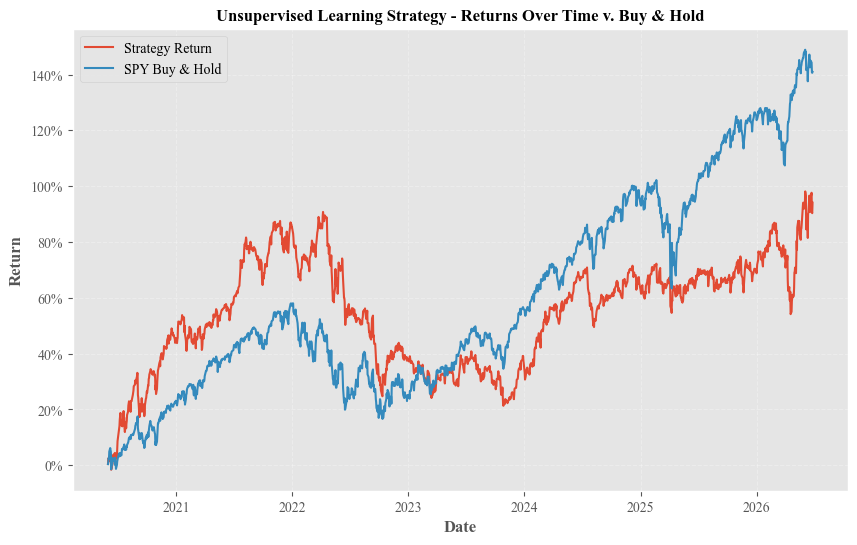

In [33]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Times New Roman'

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum()) - 1
plot_data = portfolio_cumulative_return[: '2026-06-26']

fig, ax = plt.subplots(figsize = (10, 6))
for column in plot_data.columns:
    ax.plot(plot_data.index, plot_data[column], linewidth = 1.5, label = column)
ax.set_title('Unsupervised Learning Strategy - Returns Over Time v. Buy & Hold', 
             fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold')
ax.set_ylabel('Return', fontweight = 'bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.legend()

plt.show()

---

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Equal-Weight Strategy**

---

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Quantitative Momentum Strategy**

---

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Quantitative Value Strategy**